# load packages

Read in all necessary packages:

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:90% !important; }</style>"))
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pandas.io.parsers import read_csv
import scanpy as sc
import numpy as np
from functools import reduce
from anndata import AnnData, read_h5ad
import loompy
import collections
import scipy
import math
from matplotlib.colors import LinearSegmentedColormap
import random
from sklearn.mixture import GaussianMixture
from scipy.stats import poisson

import scipy
import tqdm
from statsmodels.stats.multitest import multipletests
import matplotlib.patches as mpatches

/var/folders/pb/hvc2shb53x194_v0c3h_jyccsf3dhb/T/ipykernel_6030/284414565.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


OMP: Info #273: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


In [2]:
sc.set_figure_params(dpi = 80)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

# Load the dataset

In [3]:
for_venn = pd.read_csv('../data/peter/20240118_Fig4_full_spliced_table_v2.csv', sep = '\t', index_col = 0)

In [5]:
for_venn.head(2)

,K4_prom_p,K4_prom_min,K4_prom_max,K4_prom_mean,K4_prom_fold,name,Lin,rep,K4_sum,gene,...,RNA_gene_p,RNA_gene_min,RNA_gene_max,RNA_gene_mean,RNA_gene_fold,K4_state_avg_round,K4_state_max_pos_prom_per_gene,K4_prom_sum,RNA_state_avg_round,RNA_prom_state_avg_round
0,1.289525,13.666667,24.000000,18.866667,0.769387,A330023F24Rik:1,ESC,1,27.0,A330023F24Rik,...,10.588339,62.666668,1017.3333,456.2,3.999528,1.0,1.0,283.0,1.0,1.0
1,0.287407,2.333333,5.333333,3.266667,0.925999,A330023F24Rik:2,ESC,1,5.0,A330023F24Rik,...,10.588339,62.666668,1017.3333,456.2,3.999528,0.0,1.0,49.0,1.0,0.0


In [9]:
for_venn_filtered1 = for_venn[for_venn['K4_state_avg_round'] == 1]

In [10]:
for_venn_filtered = for_venn_filtered1.drop_duplicates(subset=['name','Lin'], keep='first')

In [11]:
for_venn.shape

(570315, 45)

In [12]:
for_venn_filtered.shape

(72090, 45)

In [13]:
for_venn_filtered.head(5)

,K4_prom_p,K4_prom_min,K4_prom_max,K4_prom_mean,K4_prom_fold,name,Lin,rep,K4_sum,gene,...,RNA_gene_p,RNA_gene_min,RNA_gene_max,RNA_gene_mean,RNA_gene_fold,K4_state_avg_round,K4_state_max_pos_prom_per_gene,K4_prom_sum,RNA_state_avg_round,RNA_prom_state_avg_round
0,1.289525,13.666667,24.0,18.866667,0.769387,A330023F24Rik:1,ESC,1,27.0,A330023F24Rik,...,10.588339,62.666668,1017.3333,456.2,3.999528,1.0,1.0,283.0,1.0,1.0
2,1.289525,13.666667,24.0,18.866667,0.769387,A330023F24Rik:1,PLU,1,14.0,A330023F24Rik,...,10.588339,62.666668,1017.3333,456.2,3.999528,1.0,1.0,283.0,1.0,1.0
4,1.289525,13.666667,24.0,18.866667,0.769387,A330023F24Rik:1,ECT,1,10.0,A330023F24Rik,...,10.588339,62.666668,1017.3333,456.2,3.999528,1.0,1.0,283.0,1.0,1.0
6,1.289525,13.666667,24.0,18.866667,0.769387,A330023F24Rik:1,END,1,24.0,A330023F24Rik,...,10.588339,62.666668,1017.3333,456.2,3.999528,1.0,1.0,283.0,1.0,1.0
8,1.289525,13.666667,24.0,18.866667,0.769387,A330023F24Rik:1,MES,1,15.0,A330023F24Rik,...,10.588339,62.666668,1017.3333,456.2,3.999528,1.0,1.0,283.0,1.0,1.0


In [14]:
for_venn.columns

Index(['K4_prom_p', 'K4_prom_min', 'K4_prom_max', 'K4_prom_mean',
       'K4_prom_fold', 'name', 'Lin', 'rep', 'K4_sum', 'gene', 'prom',
       'RNA_sum', 'RNA_gene_sum', 'RNA_gene_spliced_sum', 'K27_sum', 'K4_log2',
       'K27_log2', 'RNA_log2', 'RNA_gene_log2', 'K4_state', 'RNA_gene_state',
       'RNA_genewise_max', 'RNA_rel', 'prom_type', 'biotype', 'max_prom',
       'RNA_gene_max_state', 'RNA_prom_state', 'index_x', 'RNA_prom_p',
       'RNA_prom_min', 'RNA_prom_max', 'RNA_prom_mean', 'RNA_prom_fold',
       'index_y', 'RNA_gene_p', 'RNA_gene_min', 'RNA_gene_max',
       'RNA_gene_mean', 'RNA_gene_fold', 'K4_state_avg_round',
       'K4_state_max_pos_prom_per_gene', 'K4_prom_sum', 'RNA_state_avg_round',
       'RNA_prom_state_avg_round'],
      dtype='object')

In [15]:
venn_diagram = pd.DataFrame(for_venn_filtered['name'].str.split(':', 
                                                 expand=True)).rename(columns={0:'gene',
                                                                               1:'promoter'})

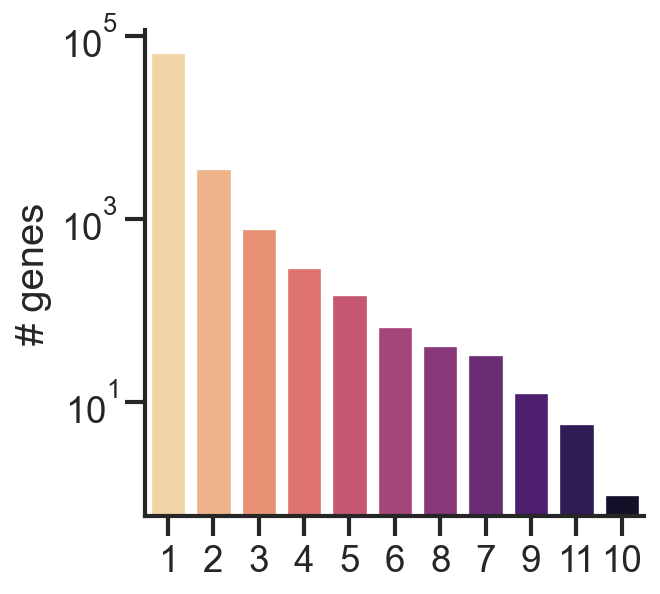

In [16]:
vals = pd.DataFrame(venn_diagram['promoter'].value_counts())

sns.barplot(x = vals.index, y = vals['promoter'], palette = 'magma_r', )
sns.despine()
plt.ylabel('# genes')           
plt.yscale('log')
plt.legend([],frameon=False)

In [17]:
for_venn_filtered[for_venn_filtered['Lin'] == 'ESC']

,K4_prom_p,K4_prom_min,K4_prom_max,K4_prom_mean,K4_prom_fold,name,Lin,rep,K4_sum,gene,...,RNA_gene_p,RNA_gene_min,RNA_gene_max,RNA_gene_mean,RNA_gene_fold,K4_state_avg_round,K4_state_max_pos_prom_per_gene,K4_prom_sum,RNA_state_avg_round,RNA_prom_state_avg_round
0,1.289525,13.666667,24.000000,18.866667,0.769387,A330023F24Rik:1,ESC,1,27.0,A330023F24Rik,...,10.588339,62.666668,1017.333300,456.200000,3.999528,1.0,1.0,283.0,1.0,1.0
30,2.419418,22.000000,61.333333,36.000000,1.438370,Ubr3:1,ESC,1,66.0,Ubr3,...,6.496925,1721.666600,2883.666700,2257.466600,0.743761,1.0,1.0,540.0,1.0,1.0
90,2.518698,17.000000,62.333333,29.266667,1.814968,Ybx2:1,ESC,1,60.0,Ybx2,...,3.028463,23.000000,63.666668,43.066666,1.429988,1.0,1.0,439.0,1.0,1.0
120,1.689316,28.000000,47.333333,40.133333,0.736966,Atl1:1,ESC,1,41.0,Atl1,...,5.169437,71.000000,155.000000,100.533330,1.115477,1.0,2.0,602.0,1.0,1.0
121,3.284178,3.333333,25.333333,9.066667,2.603341,Atl1:2,ESC,1,29.0,Atl1,...,5.169437,71.000000,155.000000,100.533330,1.115477,1.0,2.0,136.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
570240,3.409041,1.333333,18.666667,7.466667,3.075288,Cox8b:1,ESC,1,16.0,Cox8b,...,0.147791,0.000000,0.666667,0.266667,0.736966,1.0,1.0,112.0,0.0,1.0
570255,5.936132,21.000000,184.666667,73.800000,3.077139,Ifitm2:1,ESC,1,199.0,Ifitm2,...,5.101873,20.333334,88.333336,49.333332,2.066089,1.0,1.0,1107.0,1.0,1.0
570270,4.290410,23.666667,72.666667,41.466667,1.578449,Kremen2:1,ESC,1,80.0,Kremen2,...,5.874477,0.000000,13.000000,5.133333,3.807355,1.0,1.0,622.0,0.0,1.0
570285,3.015670,2.333333,17.666667,5.733333,2.485427,Gstm3:1,ESC,1,18.0,Gstm3,...,3.026721,0.666667,7.333334,2.666667,2.321928,1.0,1.0,86.0,0.0,1.0


In [18]:
vals

,promoter
1,67056
2,3602
3,810
4,303
5,154
6,69
8,42
7,34
9,13
11,6


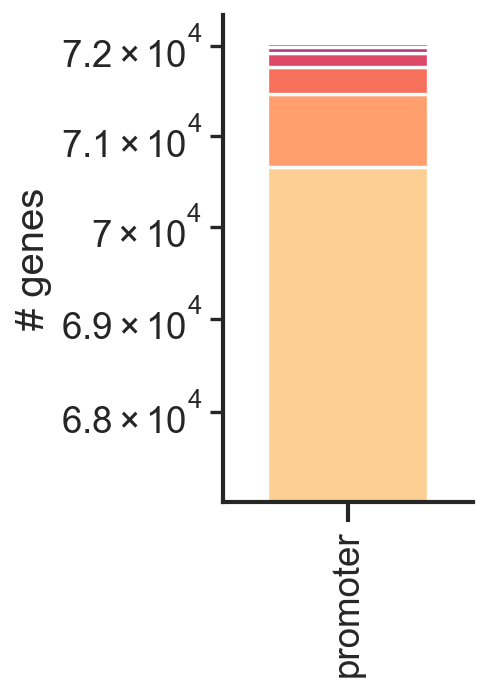

In [19]:
vals.T.plot.bar(stacked=True,width = 0.9, figsize = (2,4),
                cmap = 'magma_r')
plt.yscale('log')
plt.ylabel('# genes')
plt.legend([],frameon=False)
sns.despine()

# venn diagrams

In [20]:
sc.set_figure_params(dpi = 150)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

from matplotlib_venn import venn2, venn2_circles, venn2_unweighted
from matplotlib_venn import venn3, venn3_circles

font1 = {'family':'helvetica','color':'black','size':16} # use for title
font2 = {'family': 'helvetica', 'size': 8.5} # use for labels
plt.rc('font', **font2) # sets the default font 
plt.rcParams['text.color'] = 'black' # changes default text colour


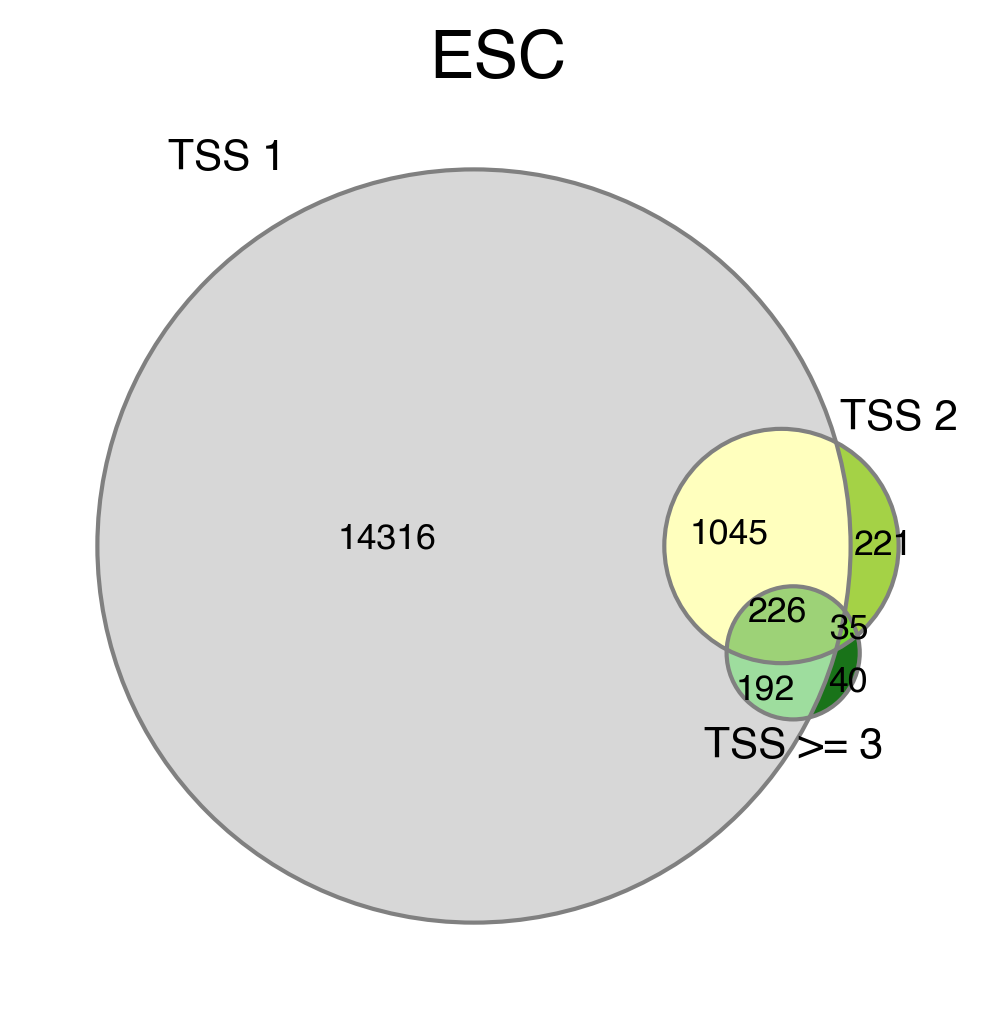

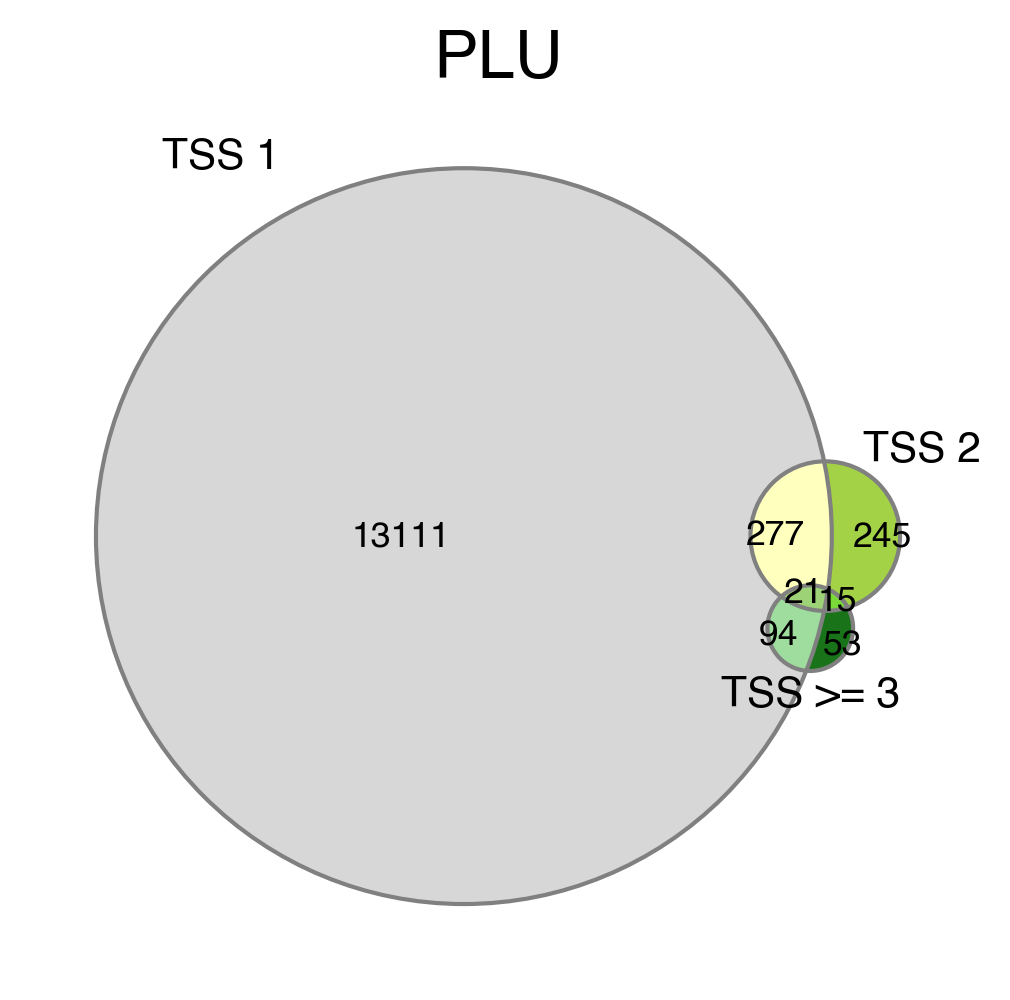

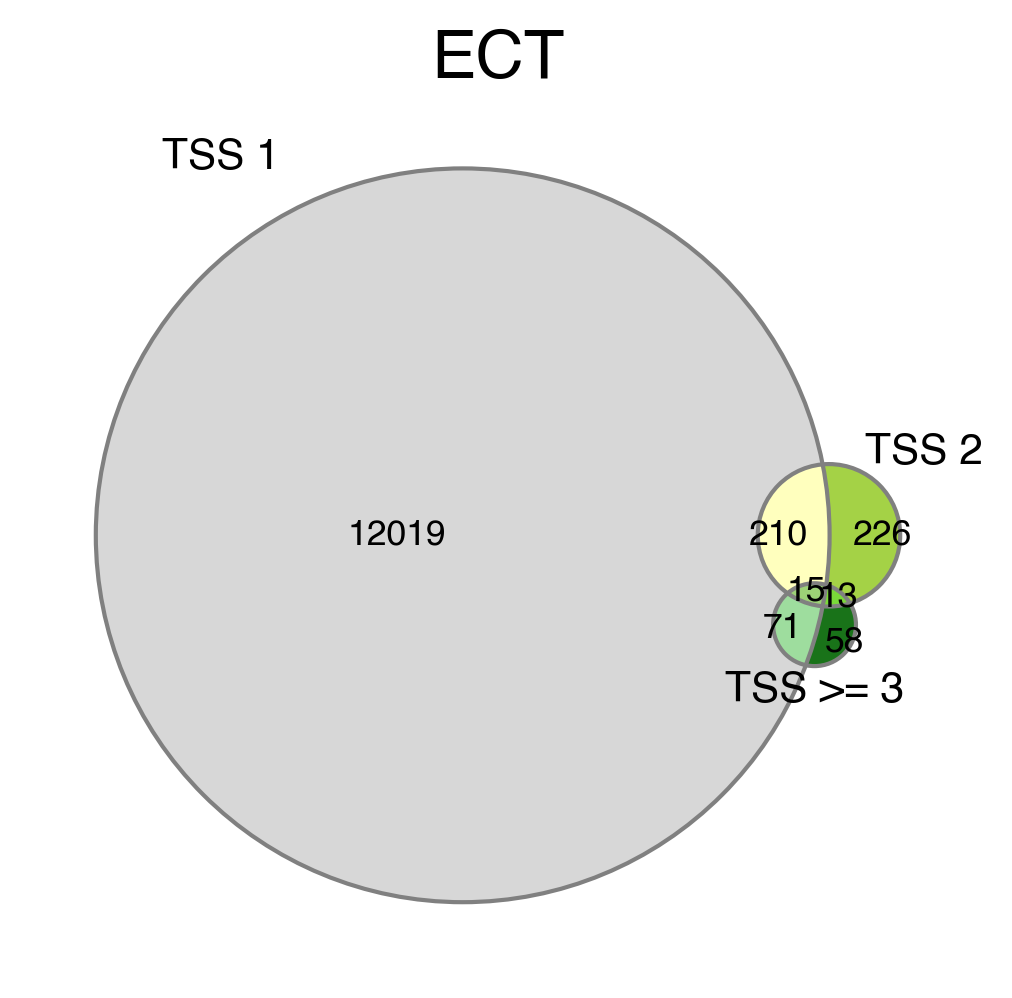

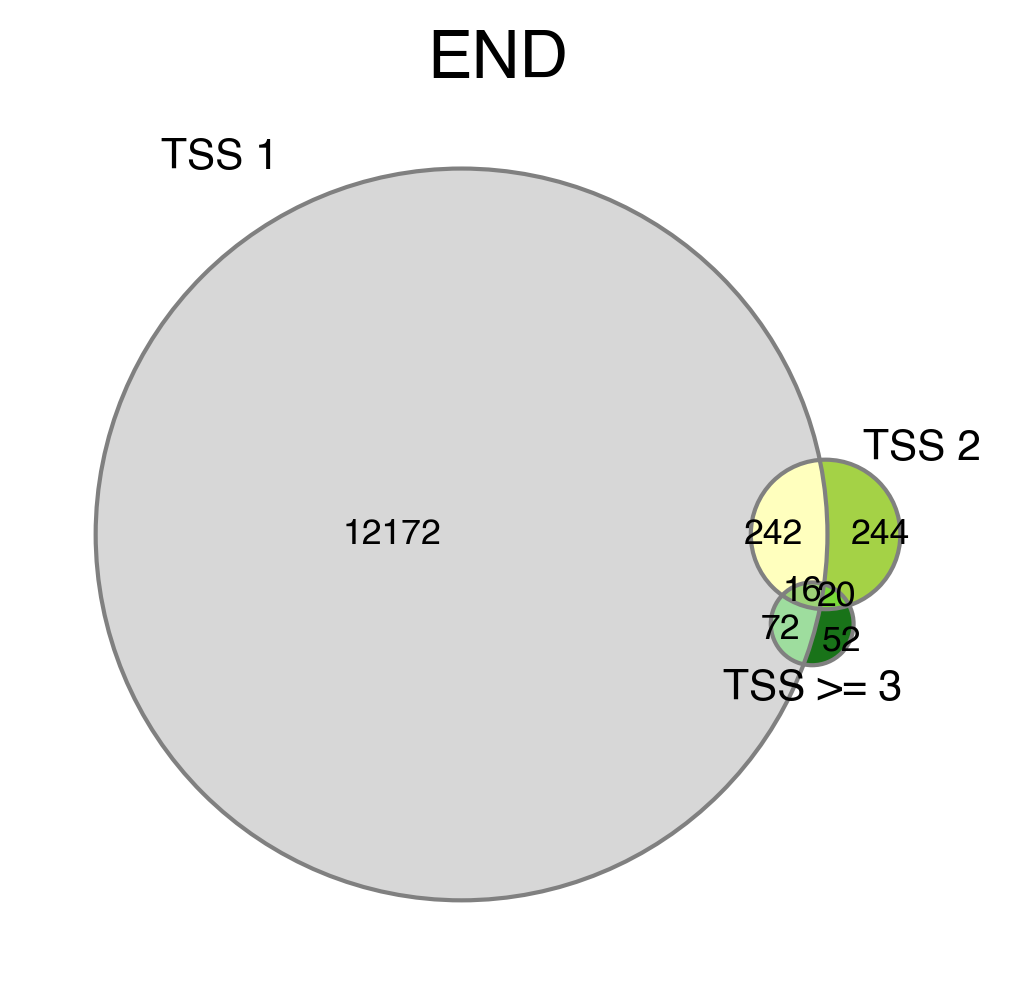

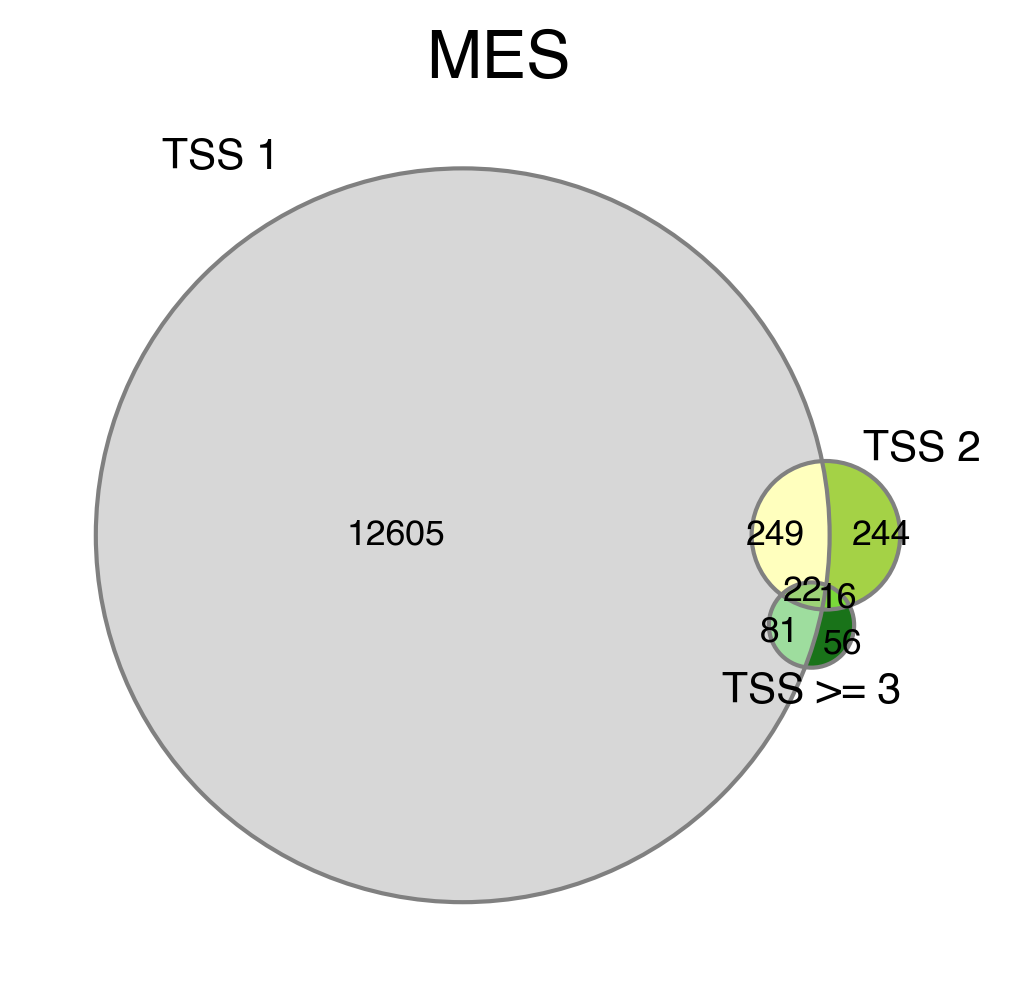

In [21]:
for ct in for_venn_filtered['Lin'].unique():
    venn_ct = for_venn_filtered[for_venn_filtered['Lin'] == ct]
    venn_diagram = pd.DataFrame(venn_ct['name'].str.split(':', 
                                                 expand=True)).rename(columns={0:'gene',
                                                                               1:'promoter'})
    a = list(venn_diagram[venn_diagram['promoter'] == '1']['gene'])
    b = list(venn_diagram[venn_diagram['promoter'] == '2']['gene'])
    c = list(venn_diagram[(venn_diagram['promoter'] != '1') & (venn_diagram['promoter'] != '2') ]['gene'])



    venn3([set(a),set(b),set(c)], set_labels = ('TSS 1','TSS 2','TSS >= 3'),
          set_colors=['lightgrey','yellowgreen','darkgreen'], alpha = 0.9,)
    venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
    plt.title(ct, fontdict=font1)
    plt.show()



    
    

In [22]:
for_venn_filtered['Lin'].unique()

array(['ESC', 'PLU', 'ECT', 'END', 'MES'], dtype=object)

In [23]:
venn_diagram = for_venn_filtered[['Lin', 'gene','prom']]
venn_diagram.head(5)

,Lin,gene,prom
0,ESC,A330023F24Rik,1
2,PLU,A330023F24Rik,1
4,ECT,A330023F24Rik,1
6,END,A330023F24Rik,1
8,MES,A330023F24Rik,1


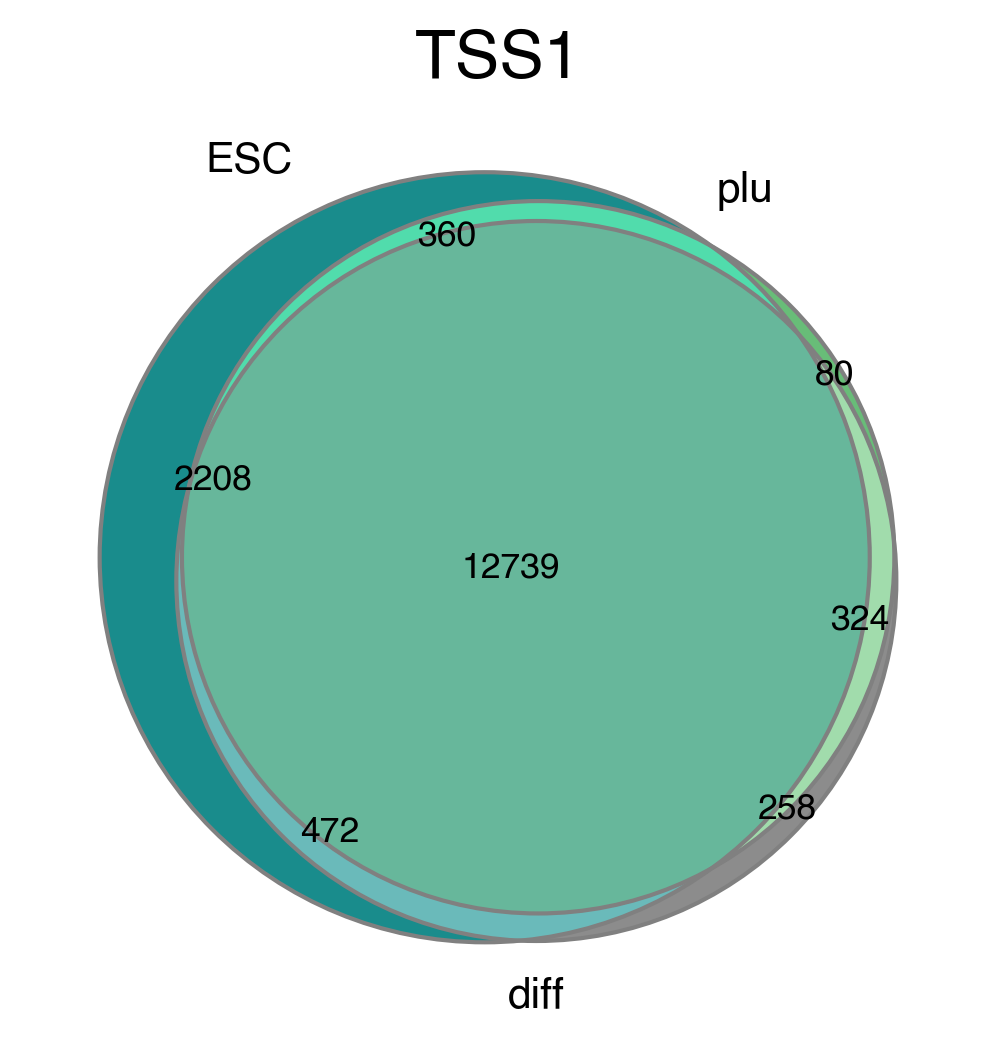

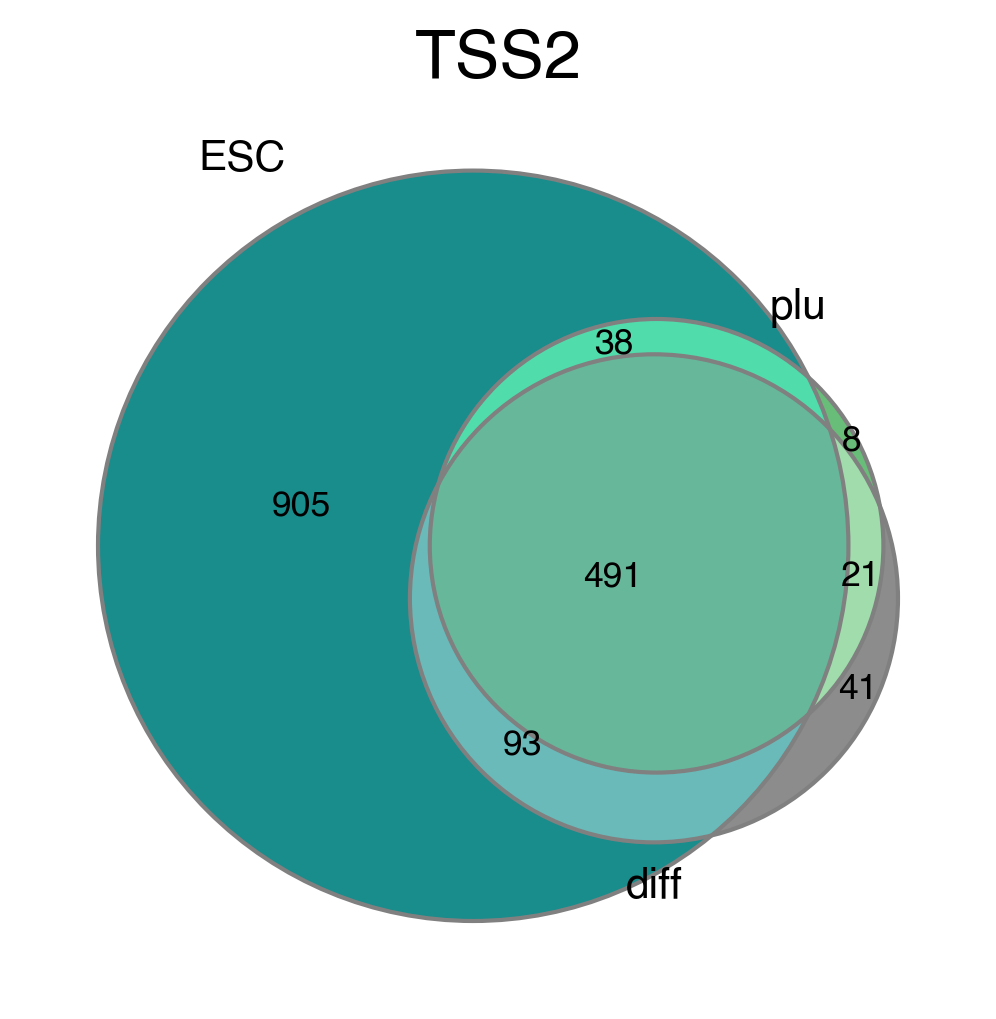

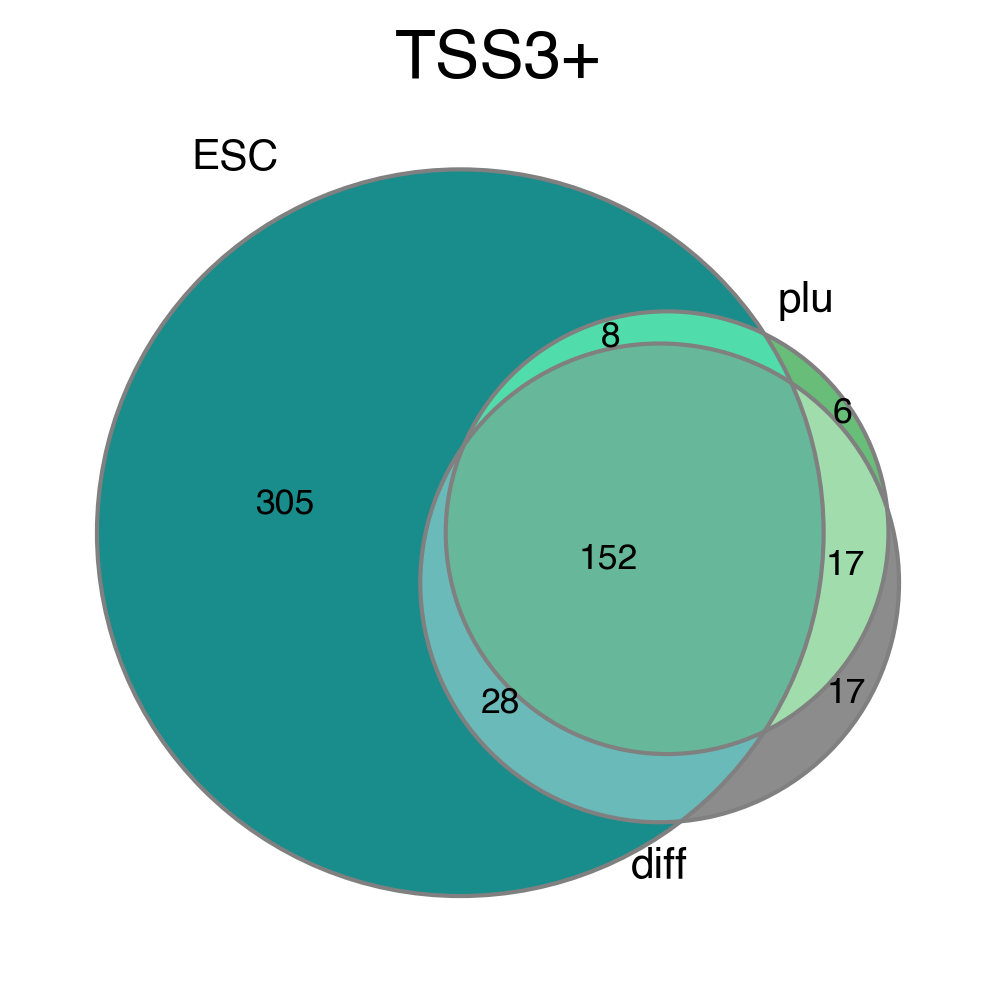

In [24]:
prom_1 = venn_diagram[venn_diagram['prom'] == 1]

a = list(prom_1[(prom_1['Lin'] == 'ESC') ] ['gene'].unique())
b = list(prom_1[(prom_1['Lin'] == 'PLU') ] ['gene'].unique())
c = list(prom_1[(prom_1['Lin'] == 'ECT') | (prom_1['Lin'] == 'END') | (prom_1['Lin'] == 'MES') ] ['gene'].unique())

venn3([set(a),set(b),set(c)], set_labels = ('ESC','plu','diff'),
      set_colors=['#008080','#58b669','grey'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS1', fontdict=font1)
plt.show()

prom_2 = venn_diagram[venn_diagram['prom'] == 2]

a = list(prom_2[(prom_2['Lin'] == 'ESC') ] ['gene'].unique())
b = list(prom_2[(prom_2['Lin'] == 'PLU') ] ['gene'].unique())
c = list(prom_2[(prom_2['Lin'] == 'ECT') | (prom_2['Lin'] == 'END') | (prom_2['Lin'] == 'MES') ] ['gene'].unique())


venn3([set(a),set(b),set(c)], set_labels = ('ESC','plu', 'diff'),
      set_colors=['#008080','#58b669','grey'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS2', fontdict=font1)
plt.show()

prom_3 = venn_diagram[(venn_diagram['prom'] != 1) & (venn_diagram['prom'] != 2)]

a = list(prom_3[(prom_3['Lin'] == 'ESC') ] ['gene'].unique())
b = list(prom_3[(prom_3['Lin'] == 'PLU') ] ['gene'].unique())
c = list(prom_3[(prom_3['Lin'] == 'ECT') | (prom_3['Lin'] == 'END') | (prom_3['Lin'] == 'MES') ] ['gene'].unique())


venn3([set(a),set(b),set(c)], set_labels = ('ESC','plu', 'diff'),
      set_colors=['#008080','#58b669','grey'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS3+', fontdict=font1)
plt.show()




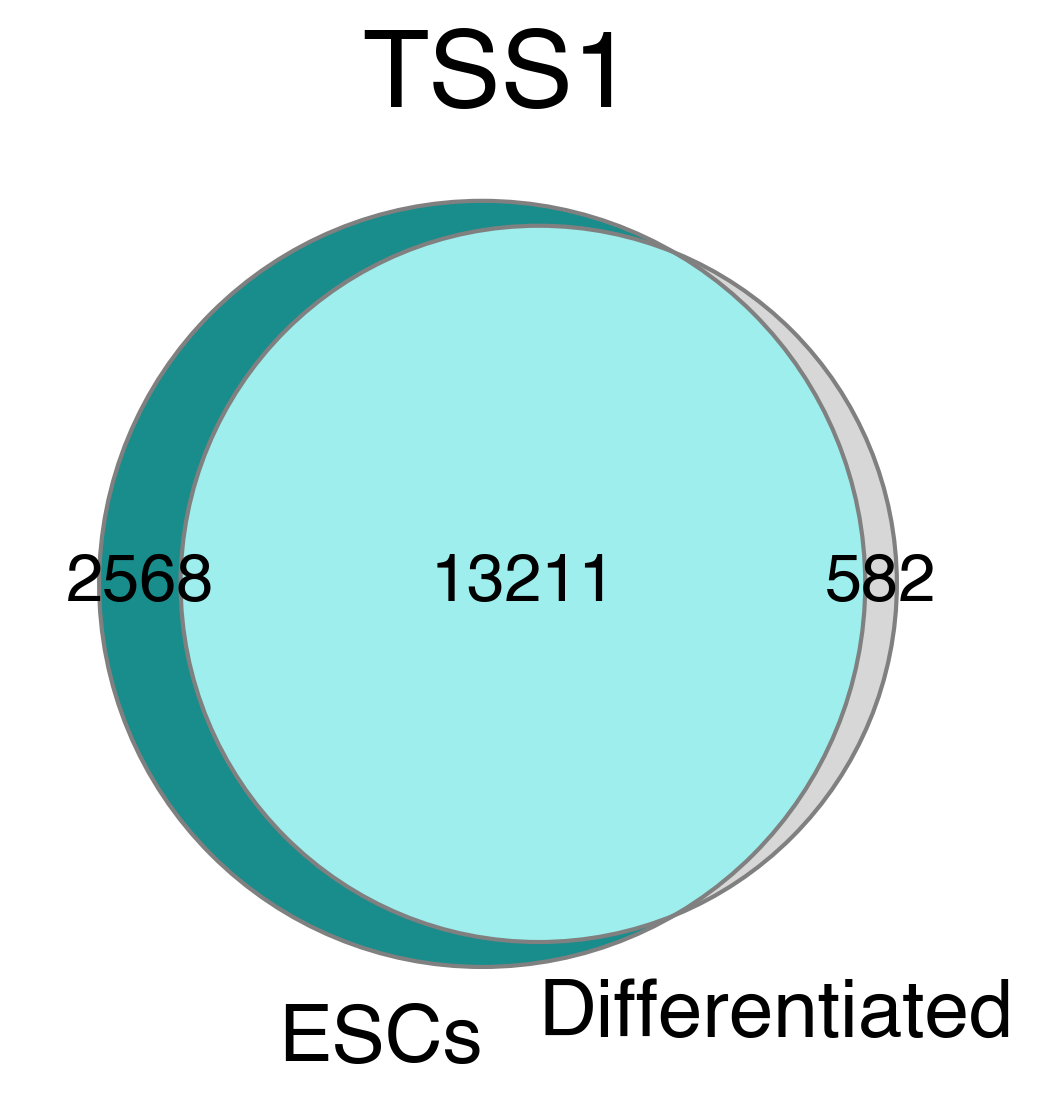

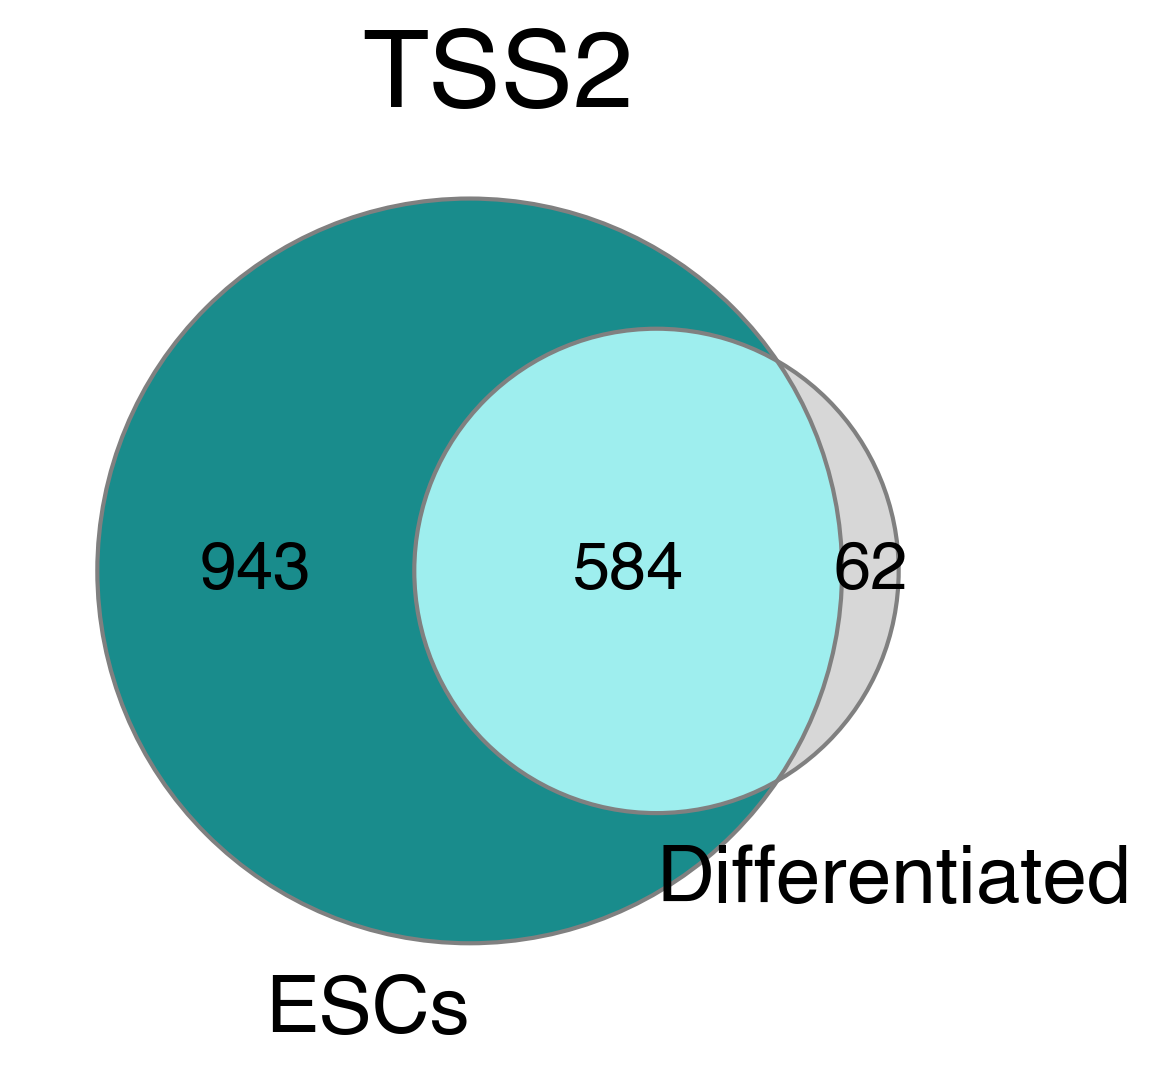

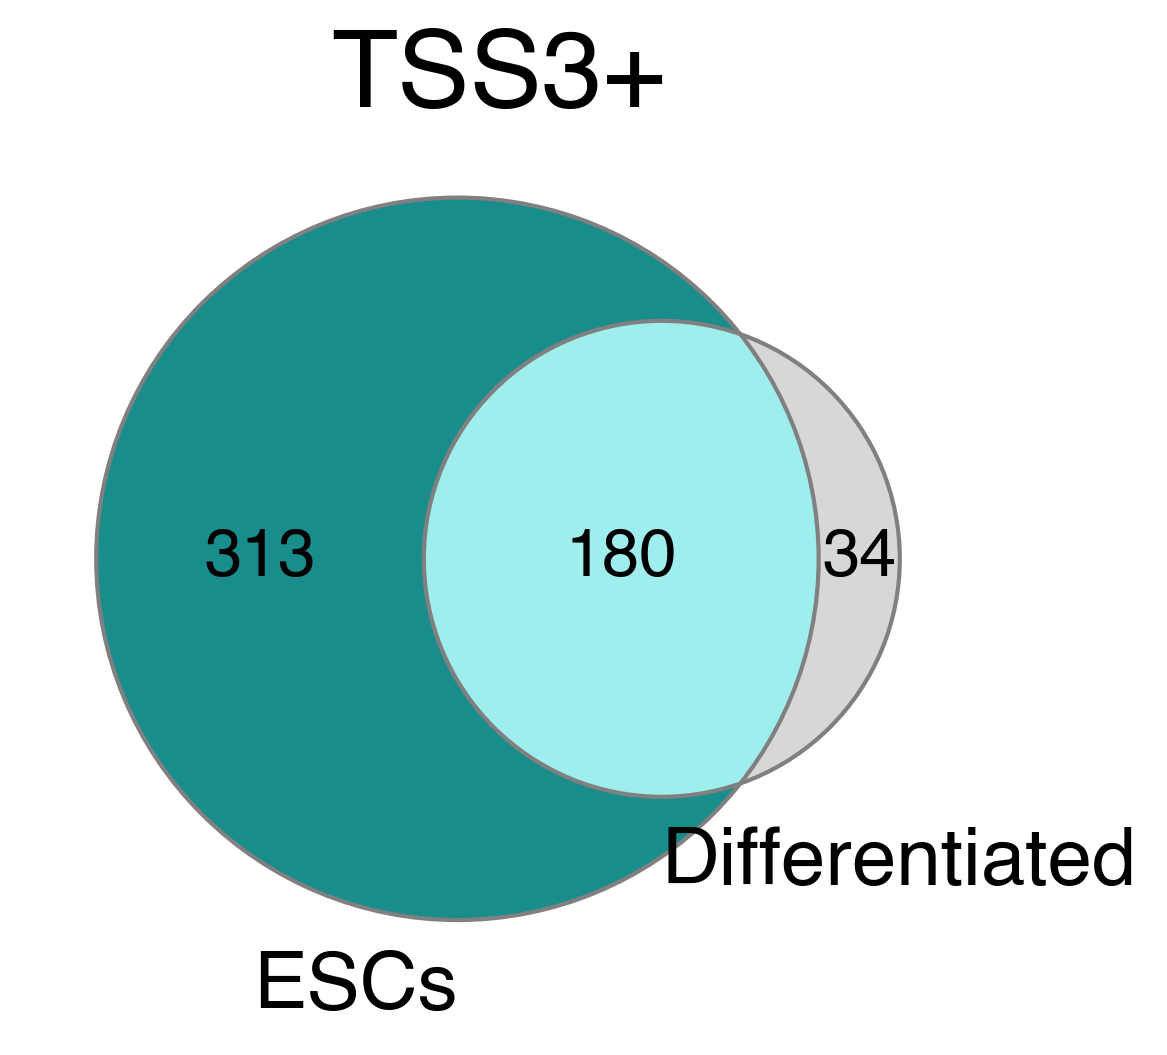

In [25]:
sc.set_figure_params(dpi = 150)
sns.set_style("white")
sns.set_context("talk")
sns.set_style("ticks")

font1 = {'family':'helvetica','color':'black','size':26} # use for title
font2 = {'family': 'helvetica', 'size': 16} # use for labels
plt.rc('font', **font2) # sets the default font 
plt.rcParams['text.color'] = 'black' # changes default text colour


a = list(prom_1[(prom_1['Lin'] == 'ESC') ] ['gene'].unique())
#b = list(prom_2[(prom_2['Lin'] == 'PLU') ] ['gene'].unique())
c = list(prom_1[(prom_1['Lin'] == 'ECT') | (prom_1['Lin'] == 'END') | (prom_1['Lin'] == 'MES') ] ['gene'].unique())


venn2([set(a),set(c)], set_labels = ('ESCs', 'Differentiated'),
      set_colors=['teal','lightgrey'], alpha = 0.9,)
venn2_circles([set(a),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS1', fontdict=font1)
plt.show()


a = list(prom_2[(prom_2['Lin'] == 'ESC') ] ['gene'].unique())
#b = list(prom_2[(prom_2['Lin'] == 'PLU') ] ['gene'].unique())
c = list(prom_2[(prom_2['Lin'] == 'ECT') | (prom_2['Lin'] == 'END') | (prom_2['Lin'] == 'MES') ] ['gene'].unique())


venn2([set(a),set(c)], set_labels = ('ESCs', 'Differentiated'),
      set_colors=['teal','lightgrey'], alpha = 0.9,)
venn2_circles([set(a),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS2', fontdict=font1)
plt.show()


a = list(prom_3[(prom_3['Lin'] == 'ESC') ] ['gene'].unique())
#b = list(prom_2[(prom_2['Lin'] == 'PLU') ] ['gene'].unique())
c = list(prom_3[(prom_3['Lin'] == 'ECT') | (prom_3['Lin'] == 'END') | (prom_3['Lin'] == 'MES') ] ['gene'].unique())


venn2([set(a),set(c)], set_labels = ('ESCs', 'Differentiated'),
      set_colors=['teal','lightgrey'], alpha = 0.9,)
venn2_circles([set(a),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS3+', fontdict=font1)
plt.show()



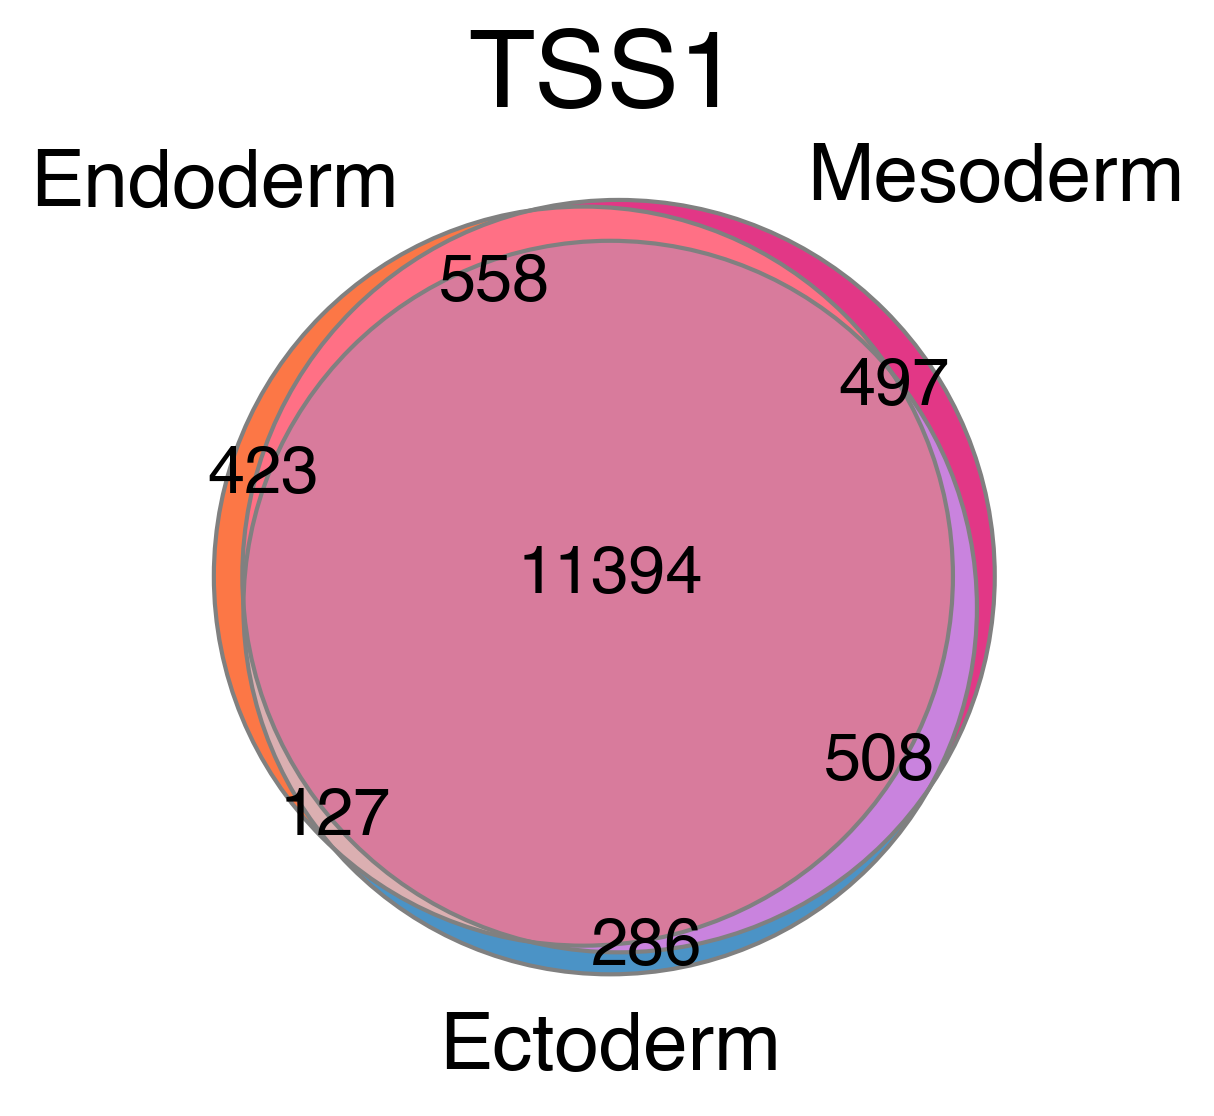

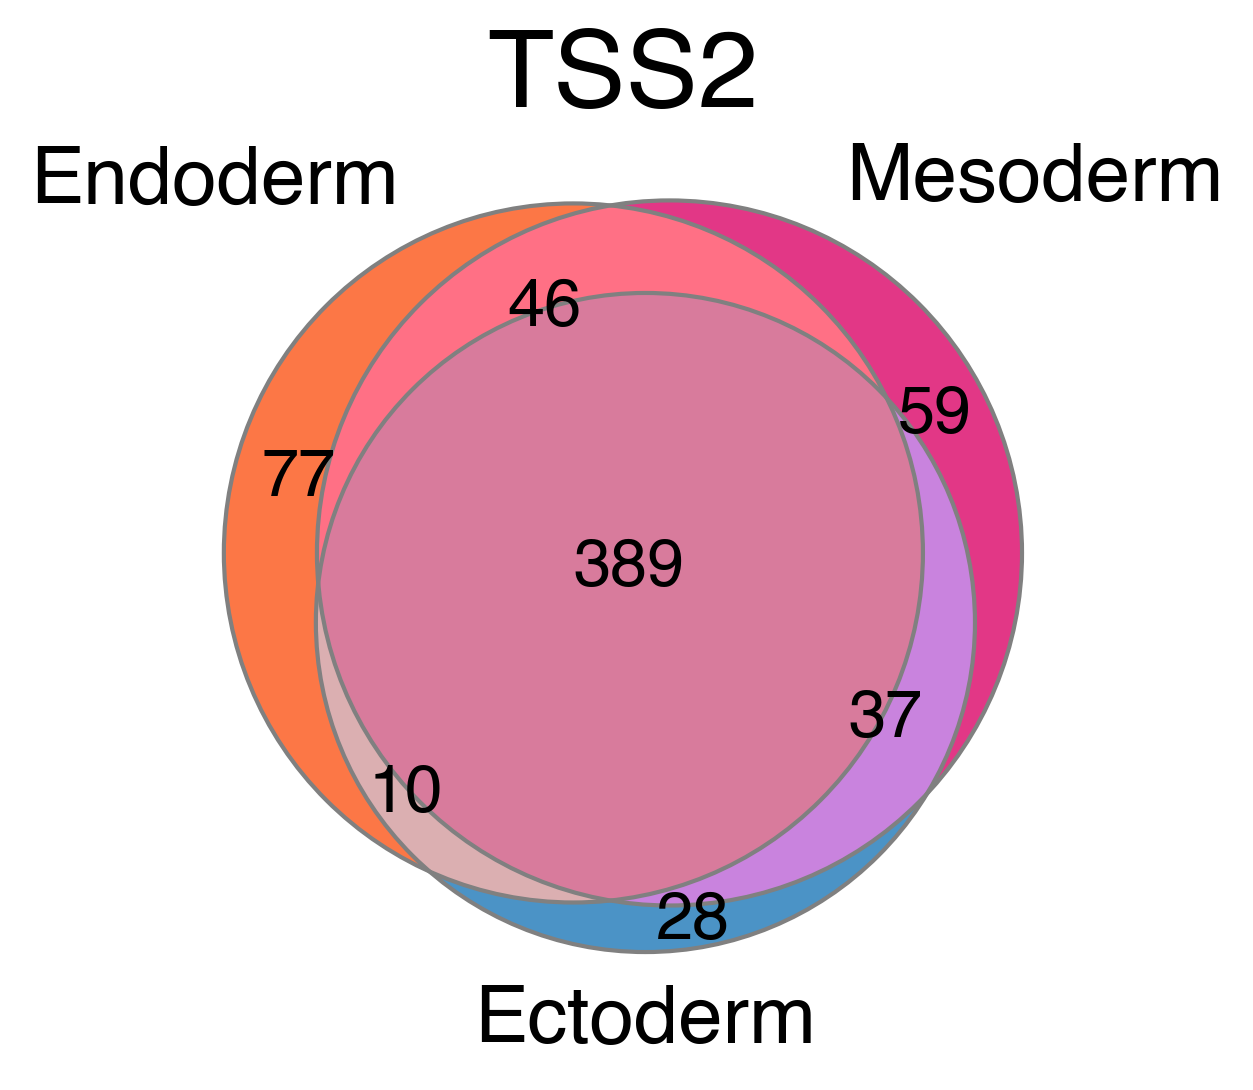

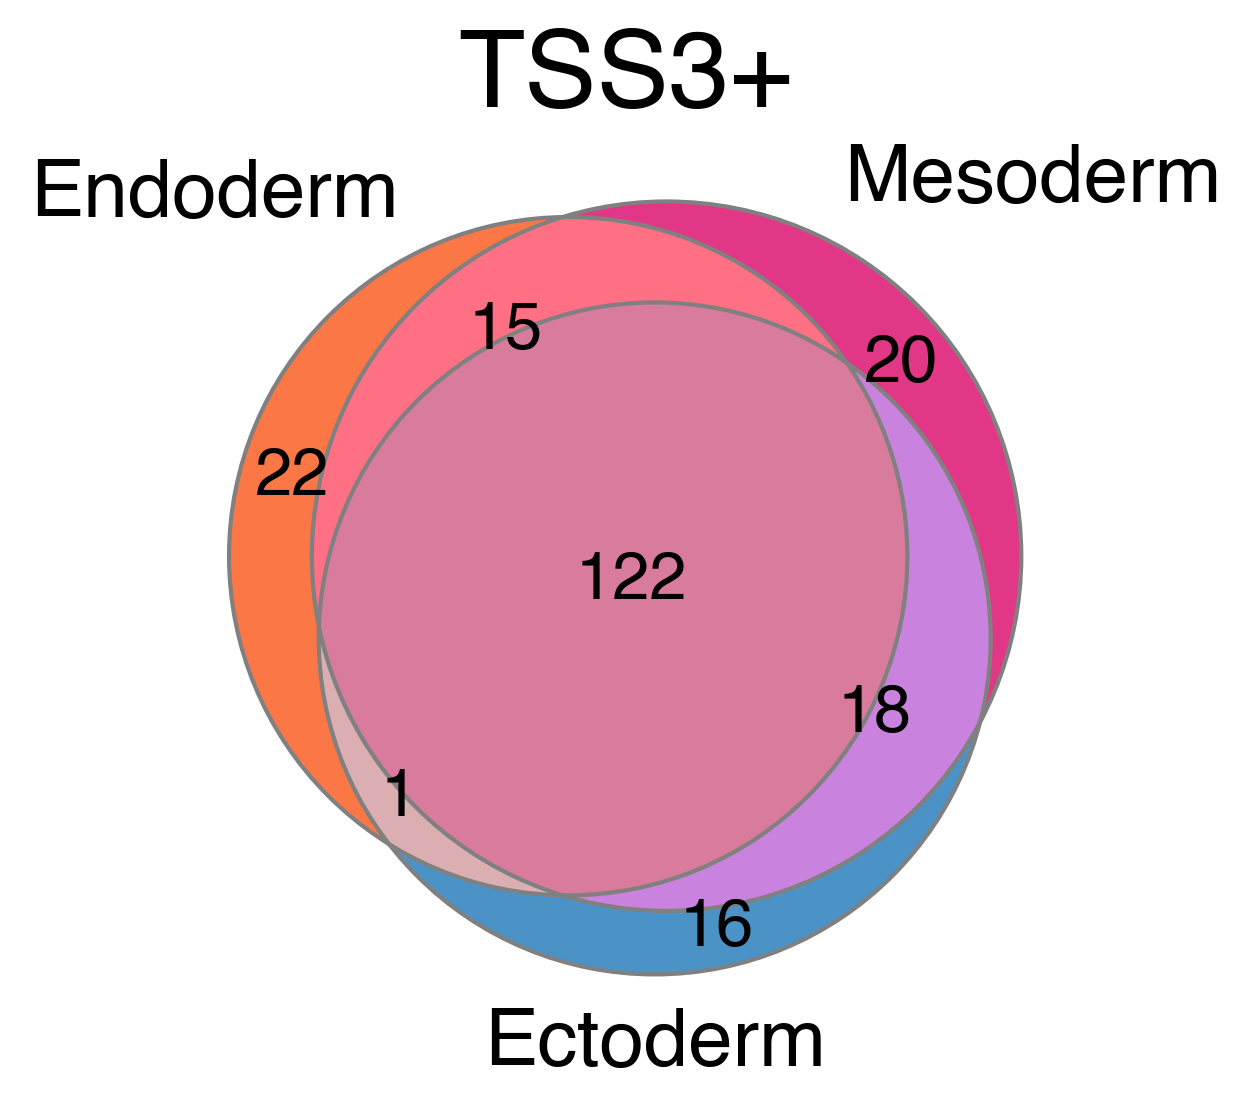

In [26]:

a = list(prom_1[(prom_1['Lin'] == 'END') ] ['gene'].unique())
b = list(prom_1[(prom_1['Lin'] == 'MES') ] ['gene'].unique())
c = list(prom_1[(prom_1['Lin'] == 'ECT') ] ['gene'].unique())



venn3([set(a),set(b),set(c)], set_labels = ('Endoderm','Mesoderm', 'Ectoderm'),
      set_colors=[ '#fc6832', '#df2179','#3787c0'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS1', fontdict=font1)
plt.show()


a = list(prom_2[(prom_2['Lin'] == 'END') ] ['gene'].unique())
b = list(prom_2[(prom_2['Lin'] == 'MES') ] ['gene'].unique())
c = list(prom_2[(prom_2['Lin'] == 'ECT') ] ['gene'].unique())


venn3([set(a),set(b),set(c)], set_labels = ('Endoderm','Mesoderm', 'Ectoderm'),
      set_colors=[ '#fc6832', '#df2179','#3787c0'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS2', fontdict=font1)
plt.show()


a = list(prom_3[(prom_3['Lin'] == 'END') ] ['gene'].unique())
b = list(prom_3[(prom_3['Lin'] == 'MES') ] ['gene'].unique())
c = list(prom_3[(prom_3['Lin'] == 'ECT') ] ['gene'].unique())


venn3([set(a),set(b),set(c)], set_labels = ('Endoderm','Mesoderm', 'Ectoderm'),
      set_colors=[ '#fc6832', '#df2179','#3787c0'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS3+', fontdict=font1)
plt.show()



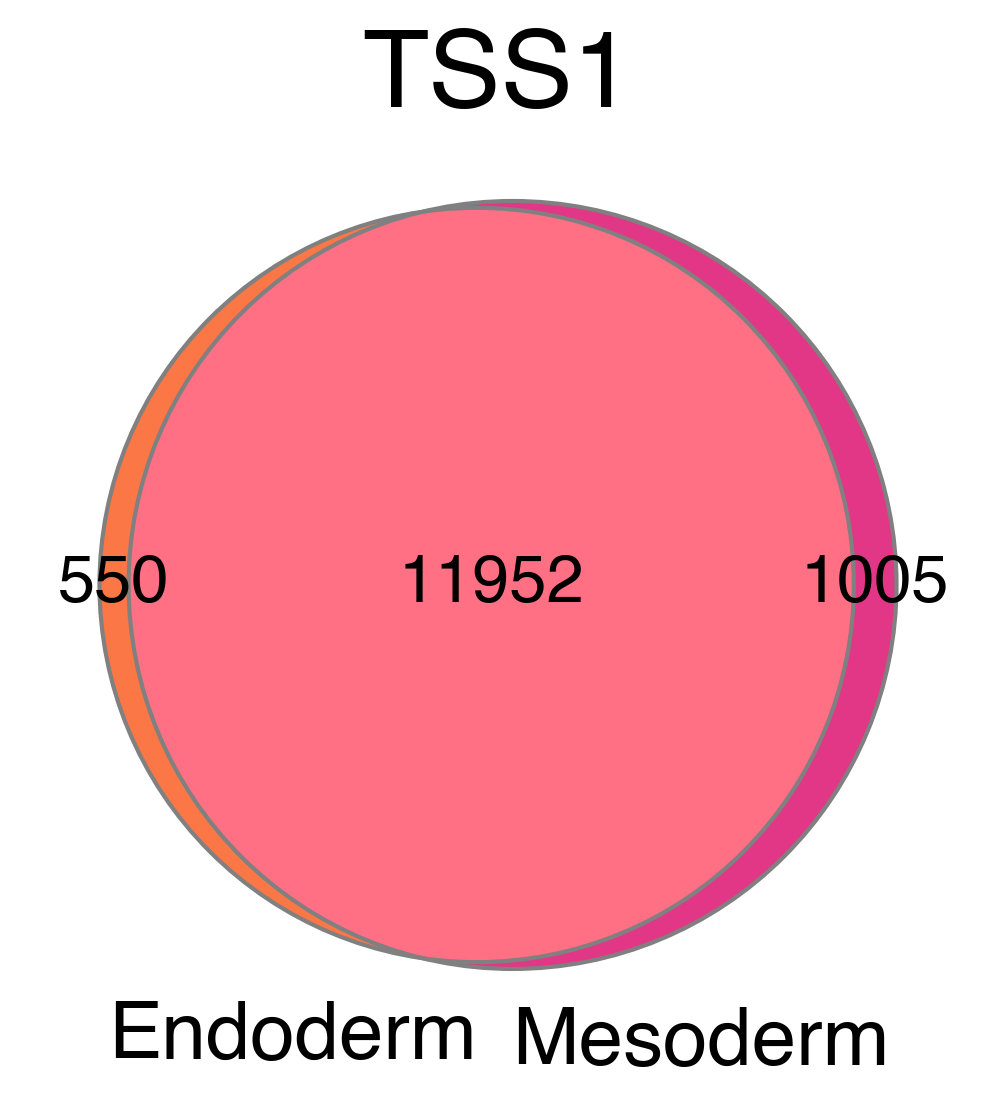

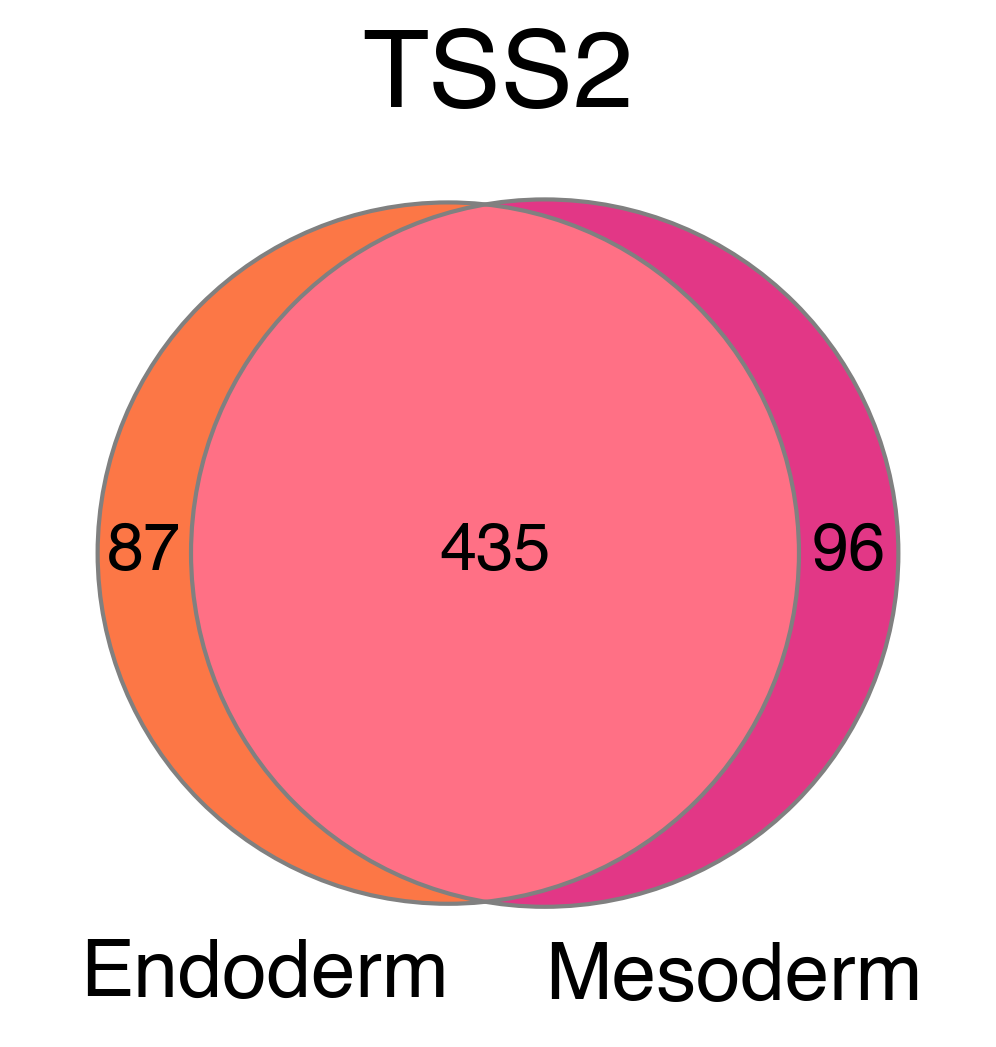

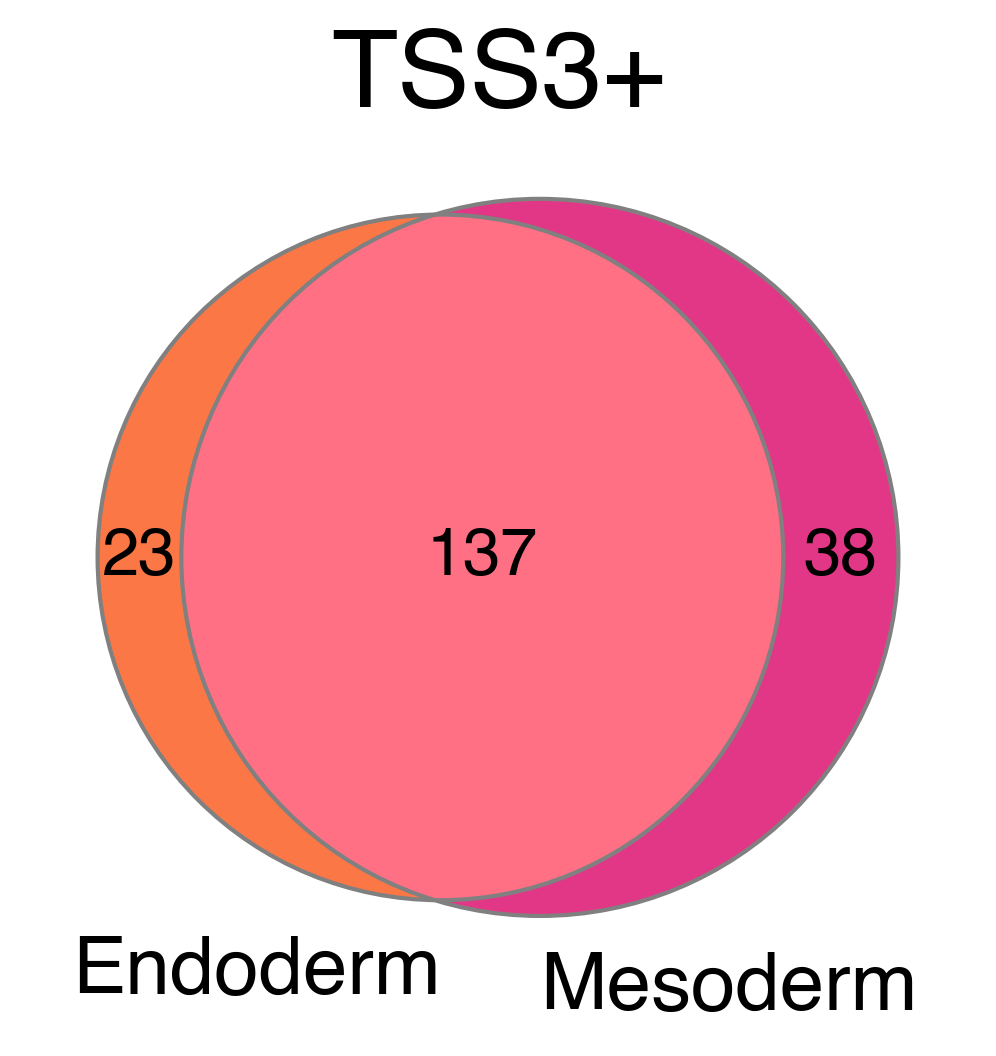

In [27]:

a = list(prom_1[(prom_1['Lin'] == 'END') ] ['gene'].unique())
b = list(prom_1[(prom_1['Lin'] == 'MES') ] ['gene'].unique())
#c = list(prom_1[(prom_1['Lin'] == 'ECT') ] ['gene'].unique())



venn2([set(a),set(b)], set_labels = ('Endoderm','Mesoderm'),
      set_colors=[ '#fc6832', '#df2179'], alpha = 0.9,)
venn2_circles([set(a),set(b)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS1', fontdict=font1)
plt.show()


a = list(prom_2[(prom_2['Lin'] == 'END') ] ['gene'].unique())
b = list(prom_2[(prom_2['Lin'] == 'MES') ] ['gene'].unique())
#c = list(prom_2[(prom_2['Lin'] == 'ECT') ] ['gene'].unique())


venn2([set(a),set(b)], set_labels = ('Endoderm','Mesoderm'),
      set_colors=[ '#fc6832', '#df2179'], alpha = 0.9,)
venn2_circles([set(a),set(b)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS2', fontdict=font1)
plt.show()


a = list(prom_3[(prom_3['Lin'] == 'END') ] ['gene'].unique())
b = list(prom_3[(prom_3['Lin'] == 'MES') ] ['gene'].unique())
#c = list(prom_3[(prom_3['Lin'] == 'ECT') ] ['gene'].unique())


venn2([set(a),set(b)], set_labels = ('Endoderm','Mesoderm'),
      set_colors=[ '#fc6832', '#df2179'], alpha = 0.9,)
venn2_circles([set(a),set(b)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS3+', fontdict=font1)
plt.show()



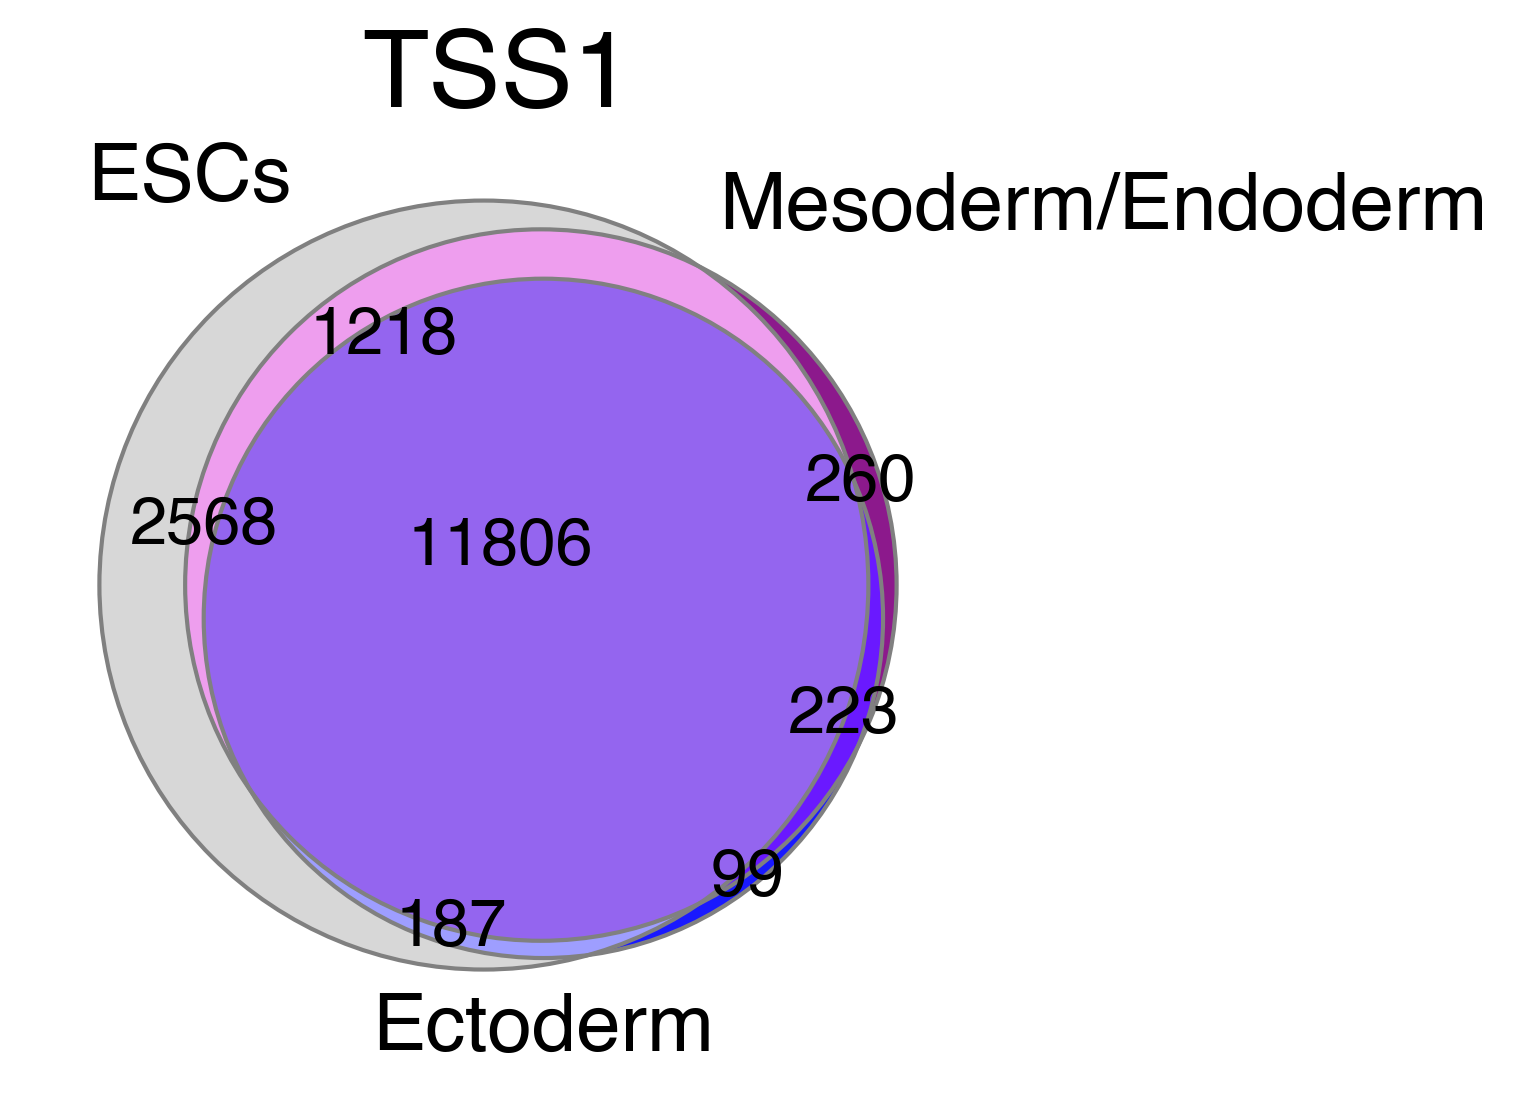

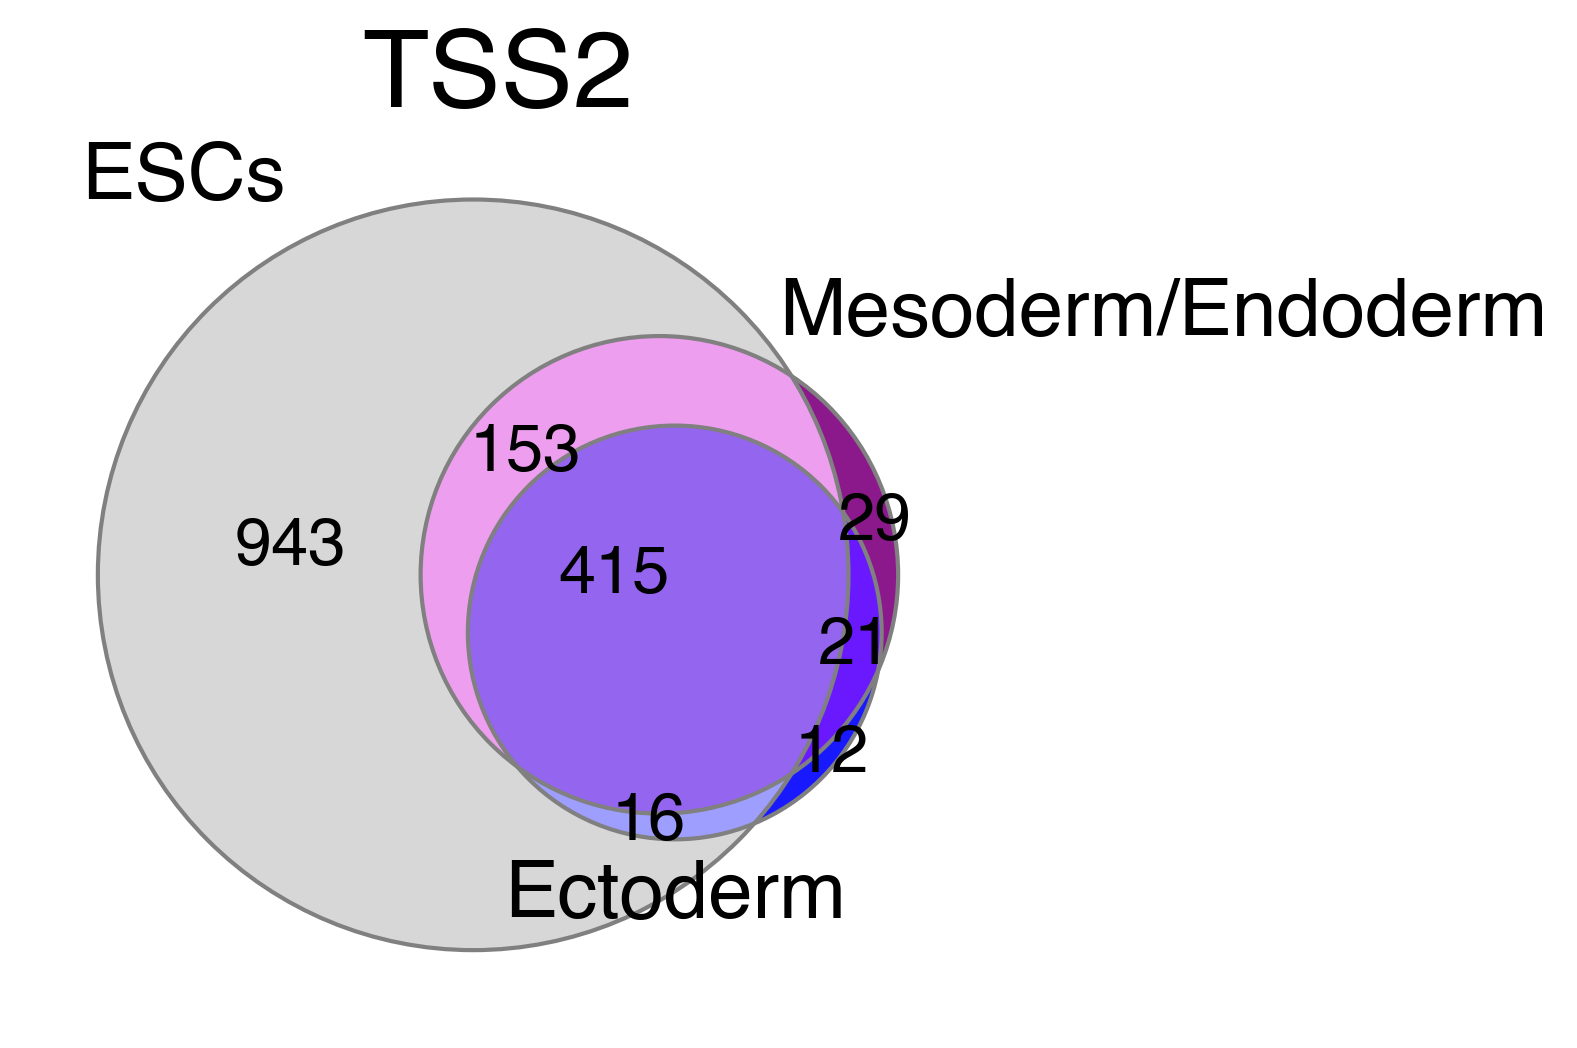

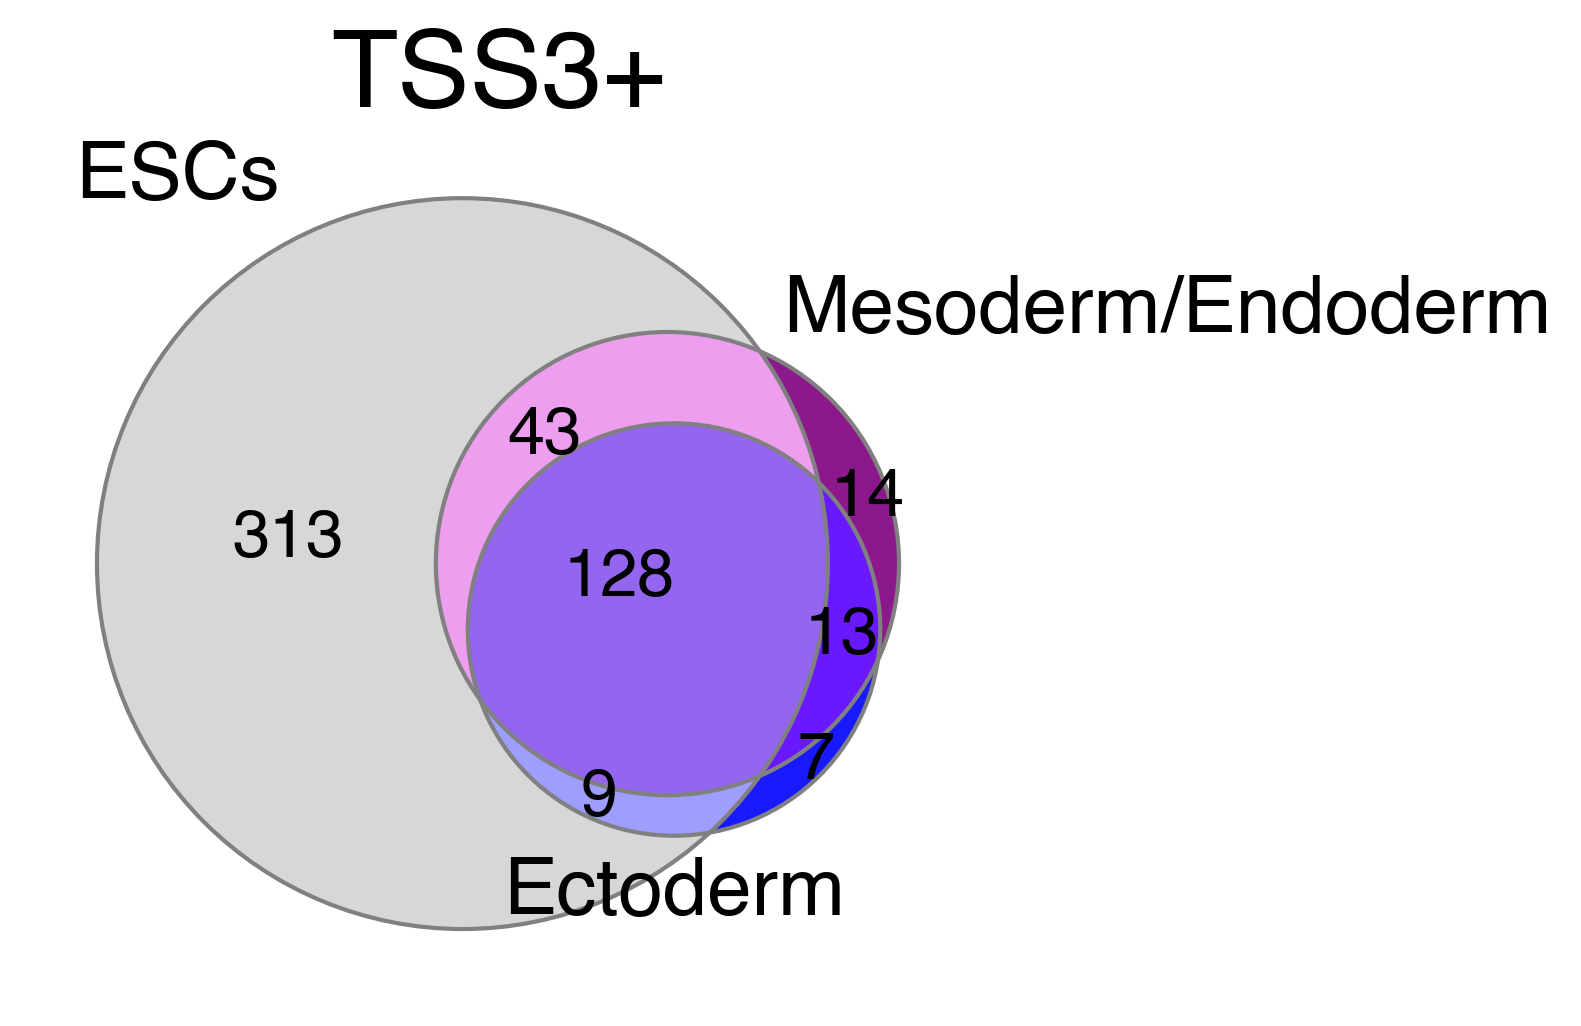

In [28]:

a = list(prom_1[(prom_1['Lin'] == 'ESC') ] ['gene'].unique())
b = list(prom_1[(prom_1['Lin'] == 'MES') | (prom_1['Lin'] == 'END') ] ['gene'].unique())
c = list(prom_1[(prom_1['Lin'] == 'ECT') ] ['gene'].unique())


venn3([set(a),set(b),set(c)], set_labels = ('ESCs','Mesoderm/Endoderm', 'Ectoderm'),
      set_colors=['lightgrey','purple','blue'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS1', fontdict=font1)
plt.show()


a = list(prom_2[(prom_2['Lin'] == 'ESC') ] ['gene'].unique())
b = list(prom_2[(prom_2['Lin'] == 'MES') | (prom_2['Lin'] == 'END') ] ['gene'].unique())
c = list(prom_2[(prom_2['Lin'] == 'ECT') ] ['gene'].unique())


venn3([set(a),set(b),set(c)], set_labels = ('ESCs','Mesoderm/Endoderm', 'Ectoderm'),
      set_colors=['lightgrey','purple','blue'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS2', fontdict=font1)
plt.show()


a = list(prom_3[(prom_3['Lin'] == 'ESC') ] ['gene'].unique())
b = list(prom_3[(prom_3['Lin'] == 'MES') | (prom_3['Lin'] == 'END') ] ['gene'].unique())
c = list(prom_3[(prom_3['Lin'] == 'ECT') ] ['gene'].unique())

               
                
venn3([set(a),set(b),set(c)], set_labels = ('ESCs','Mesoderm/Endoderm', 'Ectoderm'),
      set_colors=['lightgrey','purple','blue'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('TSS3+', fontdict=font1)
plt.show()



In [29]:
print(len(list(prom_1[(prom_1['Lin'] == 'ESC') ] ['gene'].unique())),
     len(list(prom_1[(prom_1['Lin'] == 'ECT') | (prom_1['Lin'] == 'END') | (prom_1['Lin'] == 'MES') ] ['gene'].unique())))

15779 13793


## the same but in a barplot

In [30]:
results_out = collections.defaultdict(lambda: collections.defaultdict(collections.Counter ))

for x in range(1, 12):
    list_prom = venn_diagram[venn_diagram['prom'] == x]
    a = set(list(list_prom[(list_prom['Lin'] == 'ESC') ] ['gene'].unique()))
    c = set(list(list_prom[(list_prom['Lin'] == 'ECT') | (list_prom['Lin'] == 'END') | (list_prom['Lin'] == 'MES') ] ['gene'].unique()))
    ESC_unique = len(a)-len(a.intersection(c))
    DIFF_unique = len(c)-len(a.intersection(c))
    intersect = len(a.intersection(c))
    
    results_out[x]['ESCs'] = ESC_unique
    results_out[x]['DIFF'] = DIFF_unique
    results_out[x]['intersect'] = intersect
    

In [31]:
TSS_stacked = pd.DataFrame(results_out).T

In [32]:
TSS_stacked.sum(axis=1)

1     16361
2      1589
3       414
4       153
5        78
6        35
7        15
8        13
9         6
10        1
11        2
dtype: int64

In [33]:
TSS_stacked[['intersect','ESCs','DIFF']][0:4]

,intersect,ESCs,DIFF
1,13211,2568,582
2,584,943,62
3,113,276,25
4,42,105,6


(array([    0.,  2500.,  5000.,  7500., 10000., 12500., 15000., 17500.]),
 [Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, ''),
  Text(0, 0, '')])

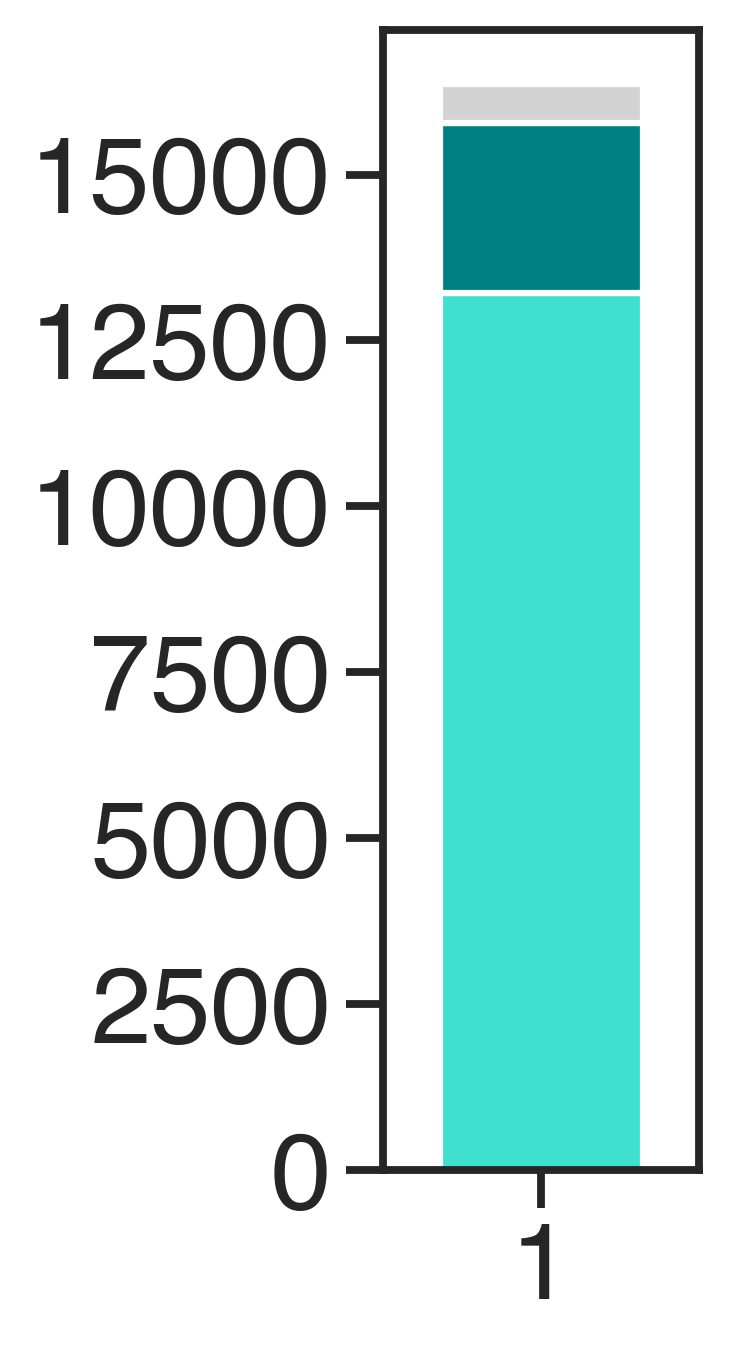

In [34]:
TSS_stacked[['intersect','ESCs','DIFF']][0:1].plot.bar(stacked=True,figsize=(1.35,5),fontsize = 20,width=0.90, color = ['turquoise','teal','lightgrey'])
#plt.yscale('log')
#sns.despine()
plt.legend([],frameon=False)
plt.xticks(rotation=0, size = 26)
plt.yticks(size = 26)

(array([   0.,  250.,  500.,  750., 1000., 1250., 1500., 1750.]),
 [Text(1, 0, ''),
  Text(1, 0, ''),
  Text(1, 0, ''),
  Text(1, 0, ''),
  Text(1, 0, ''),
  Text(1, 0, ''),
  Text(1, 0, ''),
  Text(1, 0, '')])

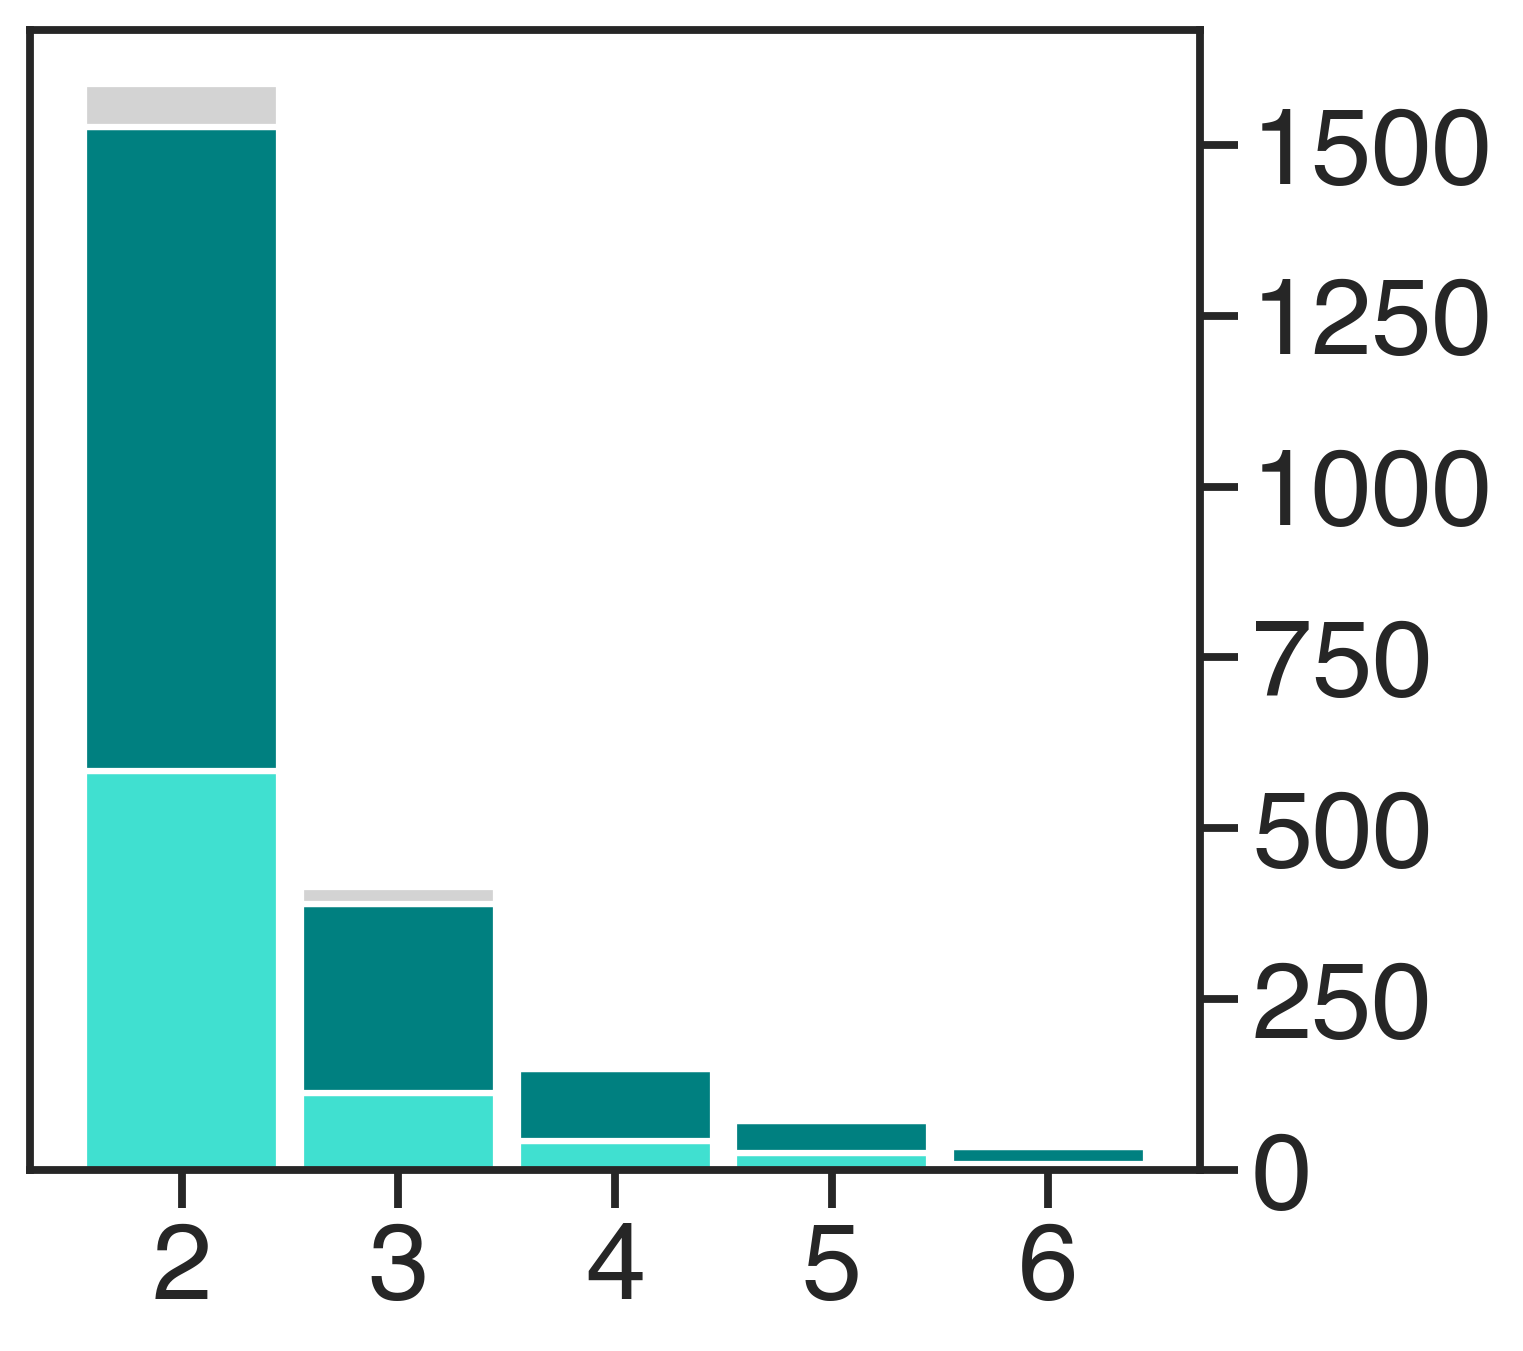

In [35]:
ax = TSS_stacked[['intersect','ESCs','DIFF']][1:6].plot.bar(stacked=True,figsize=(5,5),fontsize = 20,width=0.90, color = ['turquoise','teal','lightgrey'])
#plt.yscale('log')
#sns.despine()
plt.legend([],frameon=False)
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
plt.xticks(rotation=0, size = 26)
plt.yticks(size = 26)

In [36]:
TSS_stacked_ratio = TSS_stacked.copy()
TSS_stacked_ratio['sum'] = TSS_stacked_ratio.sum(axis=1)
TSS_stacked_ratio['ESCs'] = TSS_stacked_ratio['ESCs']/TSS_stacked_ratio['sum']*100
TSS_stacked_ratio['DIFF'] = TSS_stacked_ratio['DIFF']/TSS_stacked_ratio['sum']*100
TSS_stacked_ratio['intersect'] = TSS_stacked_ratio['intersect']/TSS_stacked_ratio['sum']*100
TSS_stacked_ratio = TSS_stacked_ratio.drop(columns='sum')

In [37]:
TSS_stacked_ratio = TSS_stacked_ratio[['intersect','ESCs','DIFF']]

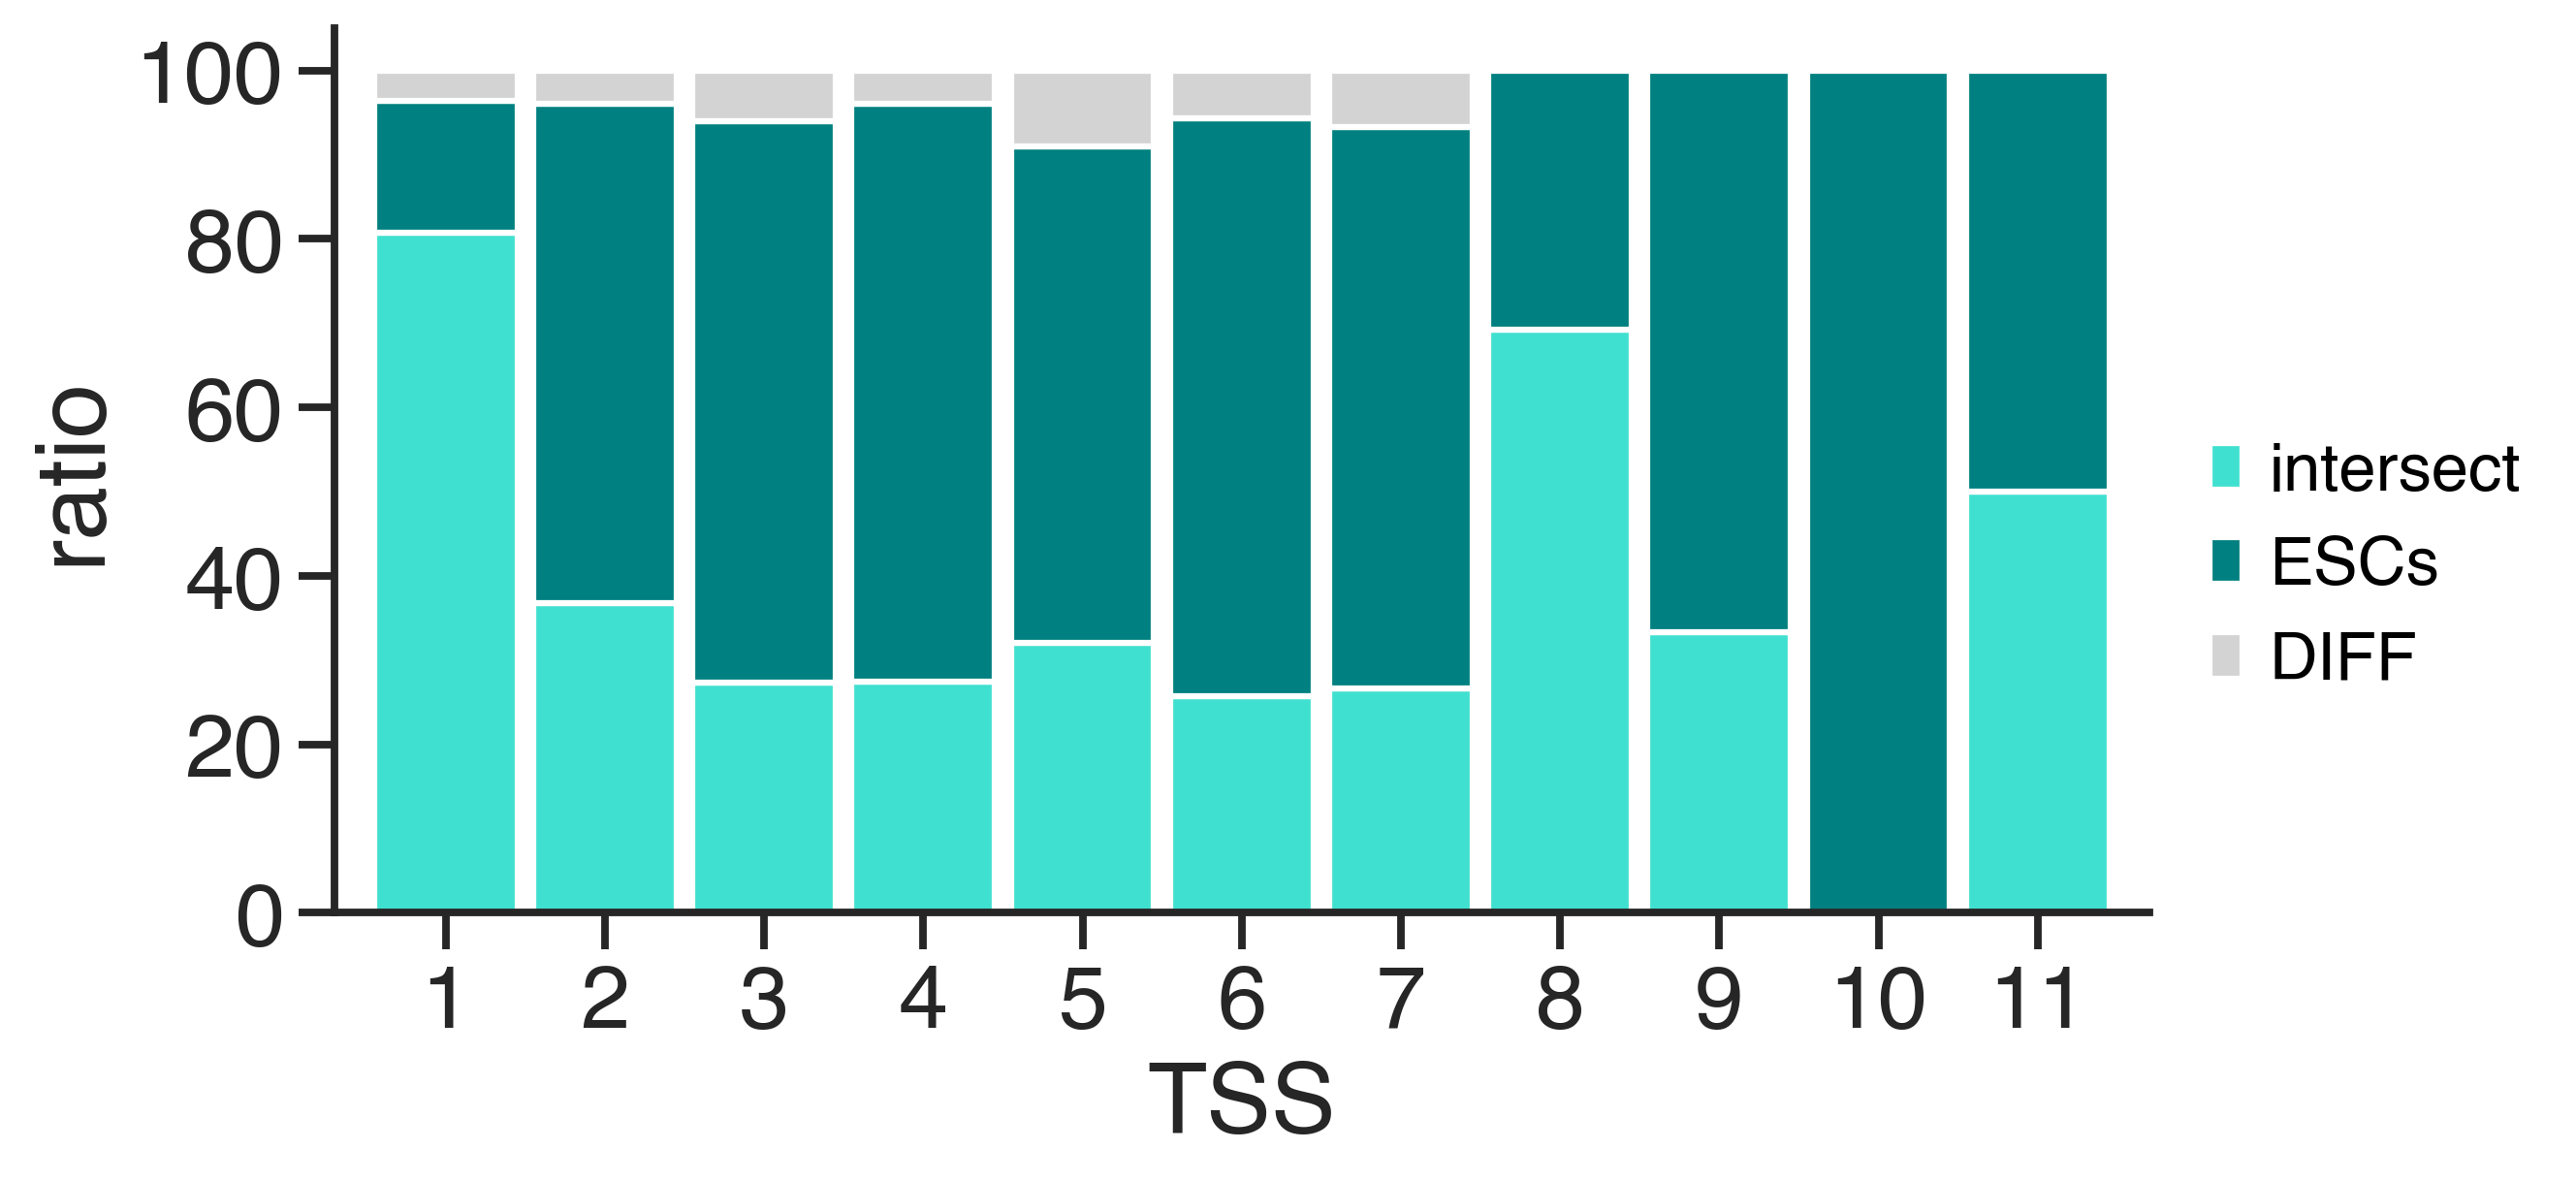

In [38]:
sns.set_context('talk')
TSS_stacked_ratio.plot.bar(stacked=True,figsize=(8,4),fontsize = 20,width=0.90, color = ['turquoise','teal','lightgrey'])
plt.legend(frameon=False,bbox_to_anchor=(1,0.6))
plt.xticks(rotation=0, size = 22)
plt.yticks(rotation=0, size = 22)
plt.xlabel('TSS', size = 24)
plt.ylabel('ratio',size = 24)
sns.despine()

## selection of changing TSS?

In [40]:
numTSS = pd.DataFrame(venn_diagram[['Lin','gene']].value_counts()).rename(columns = {0:'count'})

In [41]:
numTSS  = numTSS.reset_index()
numTSS

,Lin,gene,count
0,ESC,Sgms1,7
1,ESC,Dst,7
2,ESC,Abr,7
3,ESC,Tanc1,6
4,ESC,Fkbp5,6
...,...,...,...
68589,END,Smim11,1
68590,END,Smim12,1
68591,END,Smim13,1
68592,END,Smim15,1


In [42]:
venn_diagram

,Lin,gene,prom
0,ESC,A330023F24Rik,1
2,PLU,A330023F24Rik,1
4,ECT,A330023F24Rik,1
6,END,A330023F24Rik,1
8,MES,A330023F24Rik,1
...,...,...,...
570300,ESC,Pde12,1
570301,PLU,Pde12,1
570302,ECT,Pde12,1
570303,END,Pde12,1


In [43]:
genes = list(numTSS[(numTSS['count'] == 1) & (numTSS['Lin'] == 'ESC')]['gene'])
numTSS_ESC1 = numTSS[numTSS['gene'].isin(genes)]
genes = list(numTSS[(numTSS['count'] > 1) & (numTSS['Lin'] == 'ESC')]['gene'])
numTSS_ESCm = numTSS[numTSS['gene'].isin(genes)]

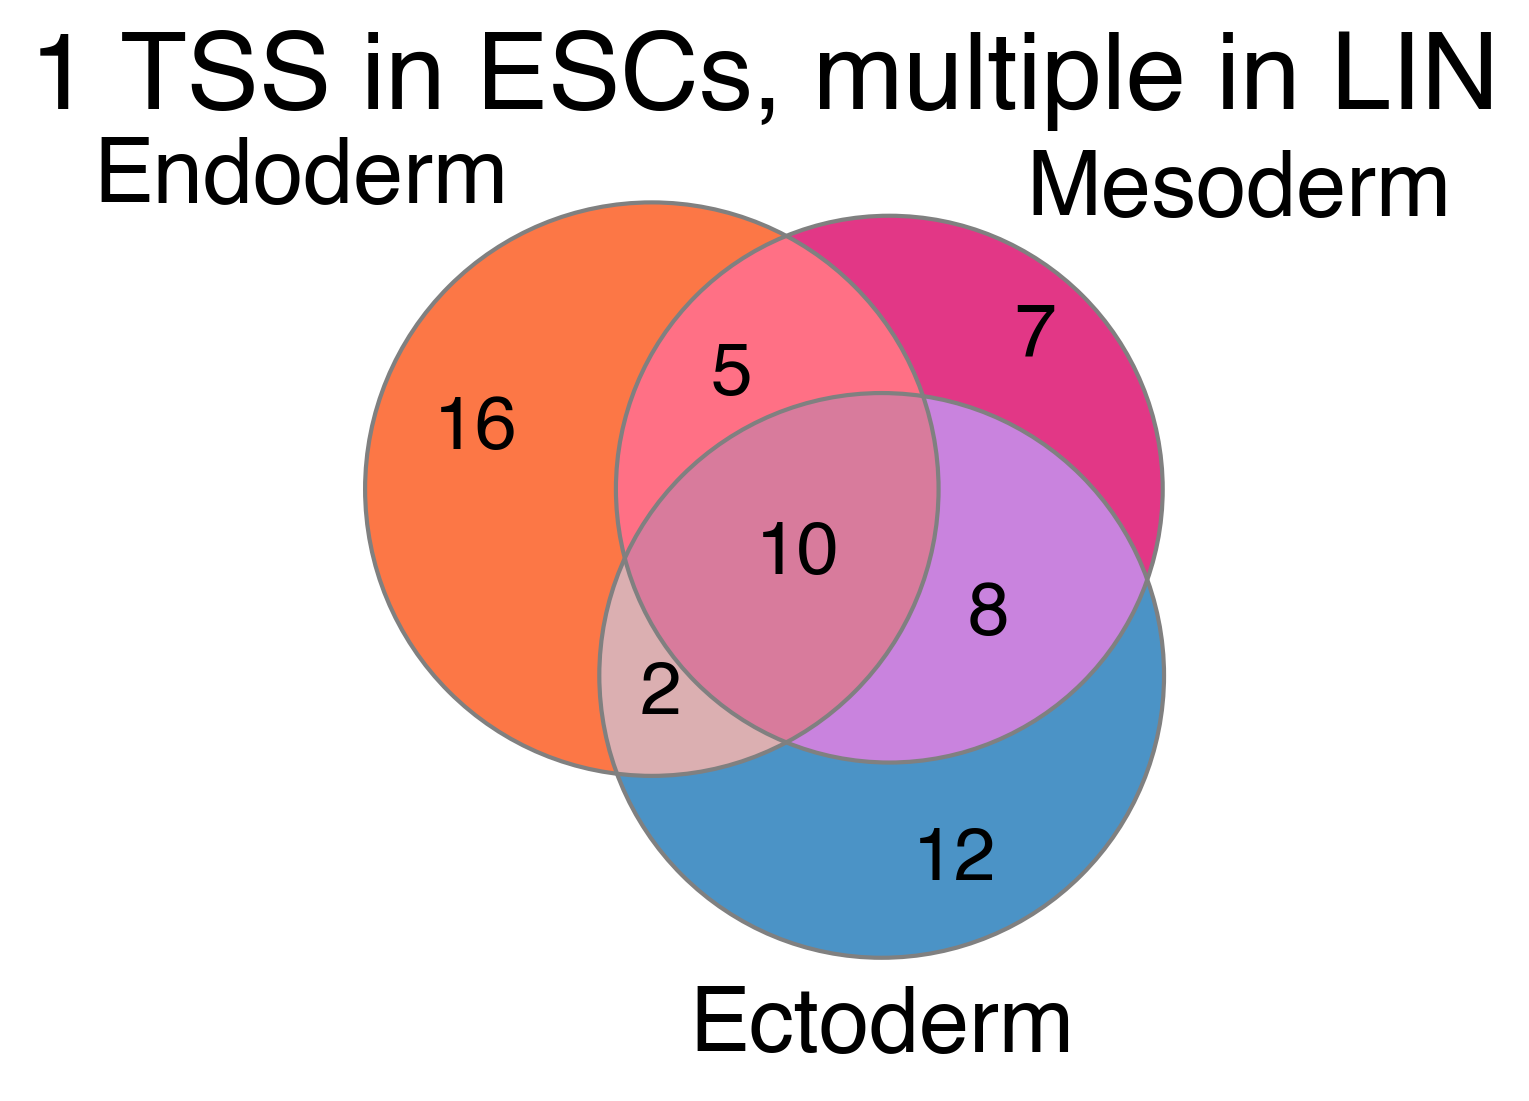

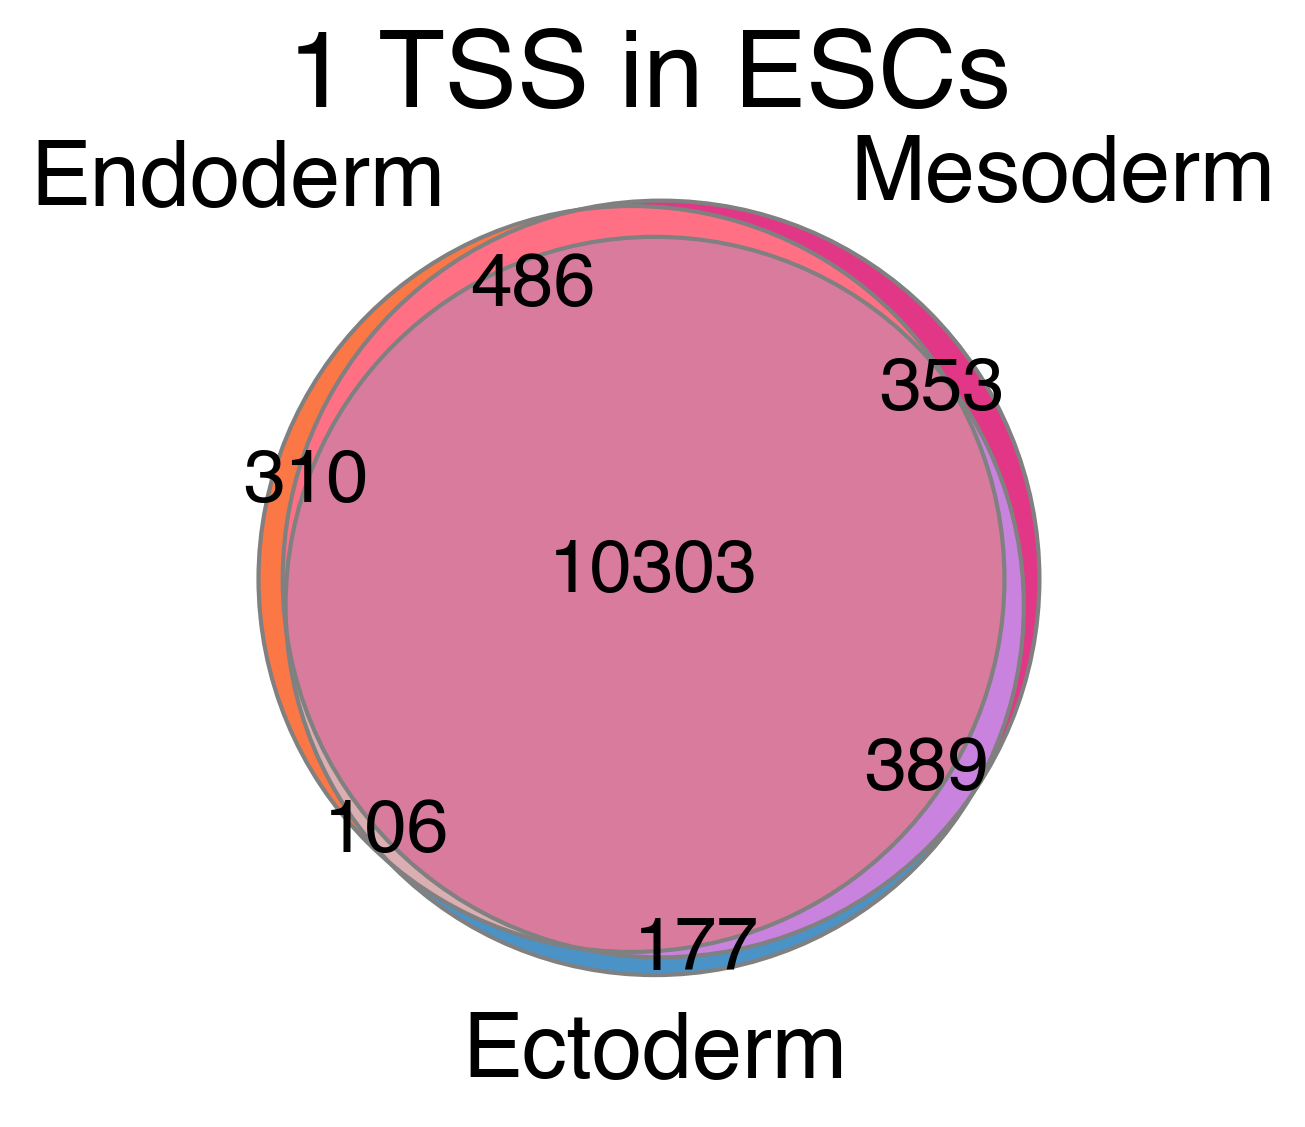

In [44]:
a = list(numTSS_ESC1[(numTSS_ESC1['Lin'] == 'END') & (numTSS_ESC1['count'] != 1)]['gene'])
b = list(numTSS_ESC1[(numTSS_ESC1['Lin'] == 'MES') & (numTSS_ESC1['count'] != 1)]['gene'])
c = list(numTSS_ESC1[(numTSS_ESC1['Lin'] == 'ECT') & (numTSS_ESC1['count'] != 1)]['gene'])


venn3([set(a),set(b),set(c)], set_labels = ('Endoderm','Mesoderm', 'Ectoderm'),
      set_colors=[ '#fc6832', '#df2179','#3787c0'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('1 TSS in ESCs, multiple in LIN', fontdict=font1)
plt.show()

a = list(numTSS_ESC1[(numTSS_ESC1['Lin'] == 'END') ]['gene'])
b = list(numTSS_ESC1[(numTSS_ESC1['Lin'] == 'MES') ]['gene'])
c = list(numTSS_ESC1[(numTSS_ESC1['Lin'] == 'ECT')]['gene'])


venn3([set(a),set(b),set(c)], set_labels = ('Endoderm','Mesoderm', 'Ectoderm'),
      set_colors=[ '#fc6832', '#df2179','#3787c0'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('1 TSS in ESCs', fontdict=font1)
plt.show()



Text(0, 0.5, '# genes')

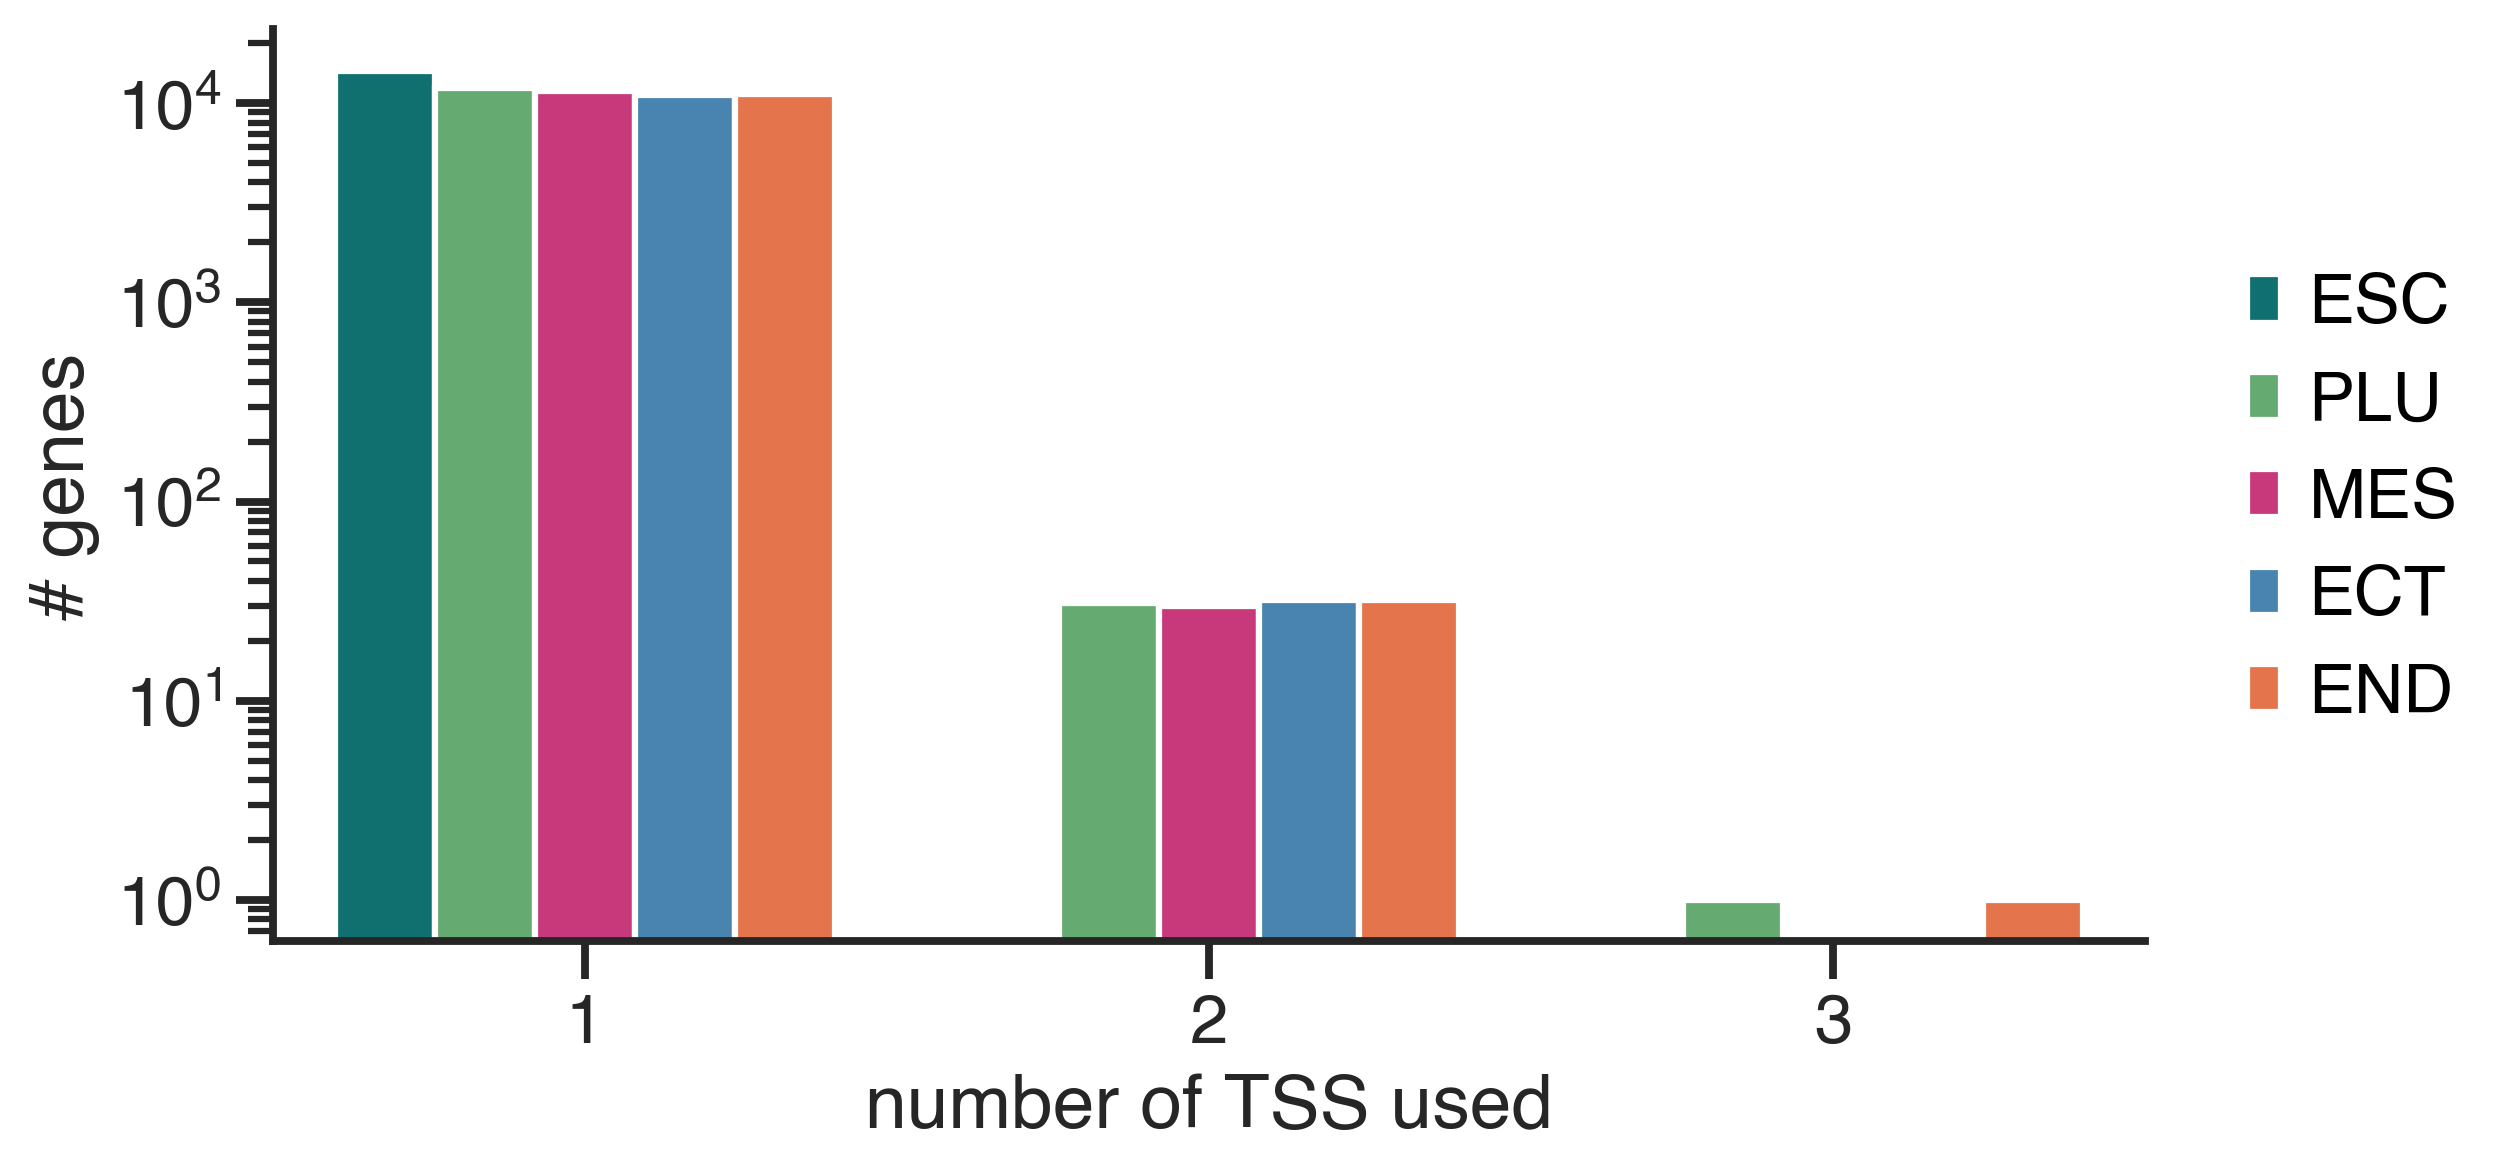

In [45]:
# 1 TSS in ESCs
sumcounts2 = pd.DataFrame(numTSS_ESC1[['count','Lin']].value_counts()).rename(columns={0:'sum'}).reset_index()

fig,ax=plt.subplots(figsize = (8,4))
sns.barplot(x = sumcounts2['count'], y=sumcounts2['sum'],hue=sumcounts2['Lin'], ax=ax, palette = ['teal','#58b669','#df2179','#3787c0', '#fc6832'],hue_order = ['ESC','PLU','MES','ECT','END'])
sns.despine()
plt.yscale('log',)
plt.legend(bbox_to_anchor=(1.2,0.8),frameon=False)
plt.xlabel('number of TSS used')
plt.ylabel('# genes')
#ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))



In [51]:
allgenes = list(venn_diagram['gene'].unique())

def makeGO(genes, background = allgenes, num = 10, figsize = (4,2)):
    go = sc.queries.enrich({'cluster':genes,'all':background}, org="mmusculus")

    plotcl = go
    cluster = 'cluster'

    plot1 = plotcl[plotcl['query'] == cluster][plotcl[plotcl['query'] == cluster]['source'] == 'GO:BP'].sort_values(by='p_value')[['name','p_value']][0:num]
    plot1['-log (p-value)'] = np.log10(plot1['p_value'])*-1
    sns.set_style('ticks')
    sns.set_context('talk')
    fig,ax = plt.subplots(figsize = figsize)
    ax = sns.barplot(y=plot1['name'],x=plot1['-log (p-value)'], color = 'grey')
    ax.set_ylabel('')
    plt.show()


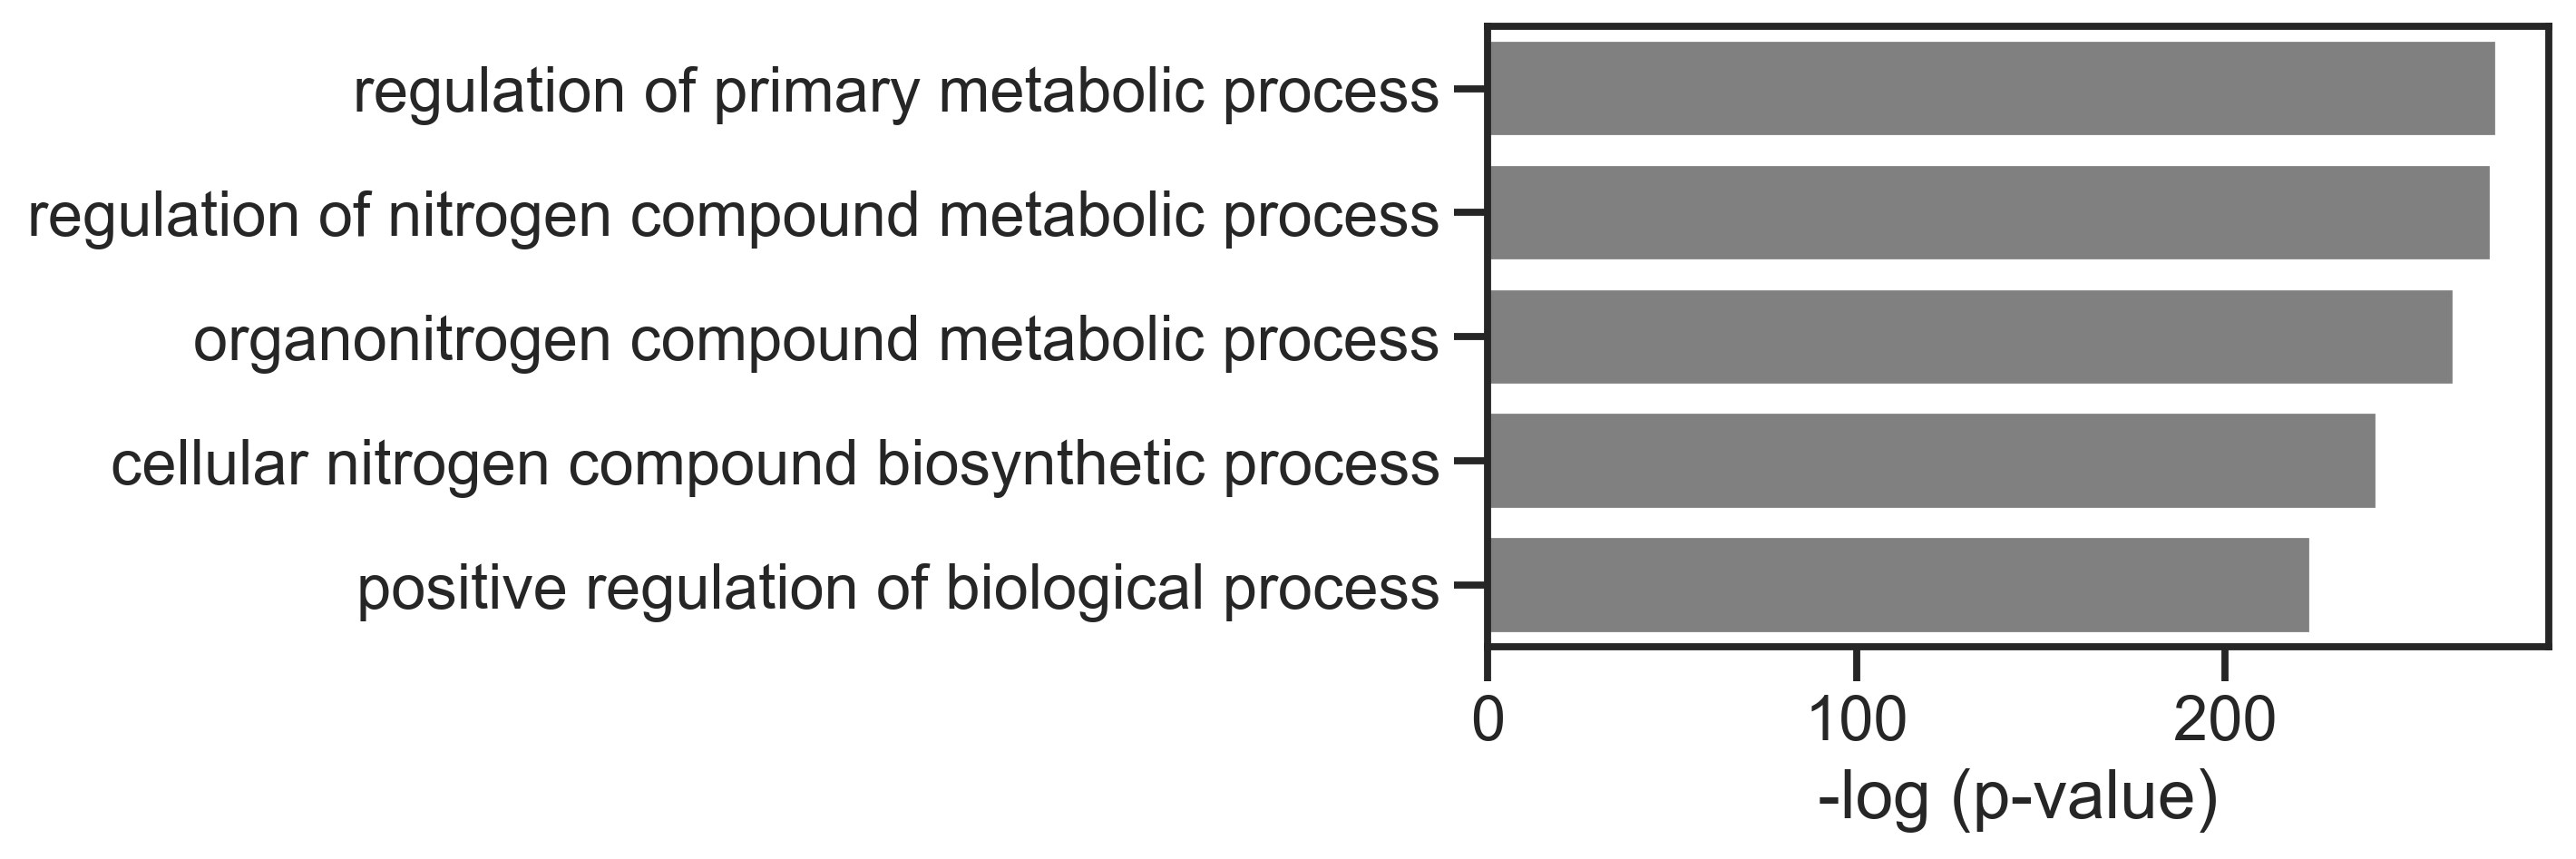

In [52]:
# GO for all genes with only 1 TSS in ESCs
genes = list(numTSS_ESC1['gene'].unique())
makeGO(genes, figsize = (5,3), num=5)

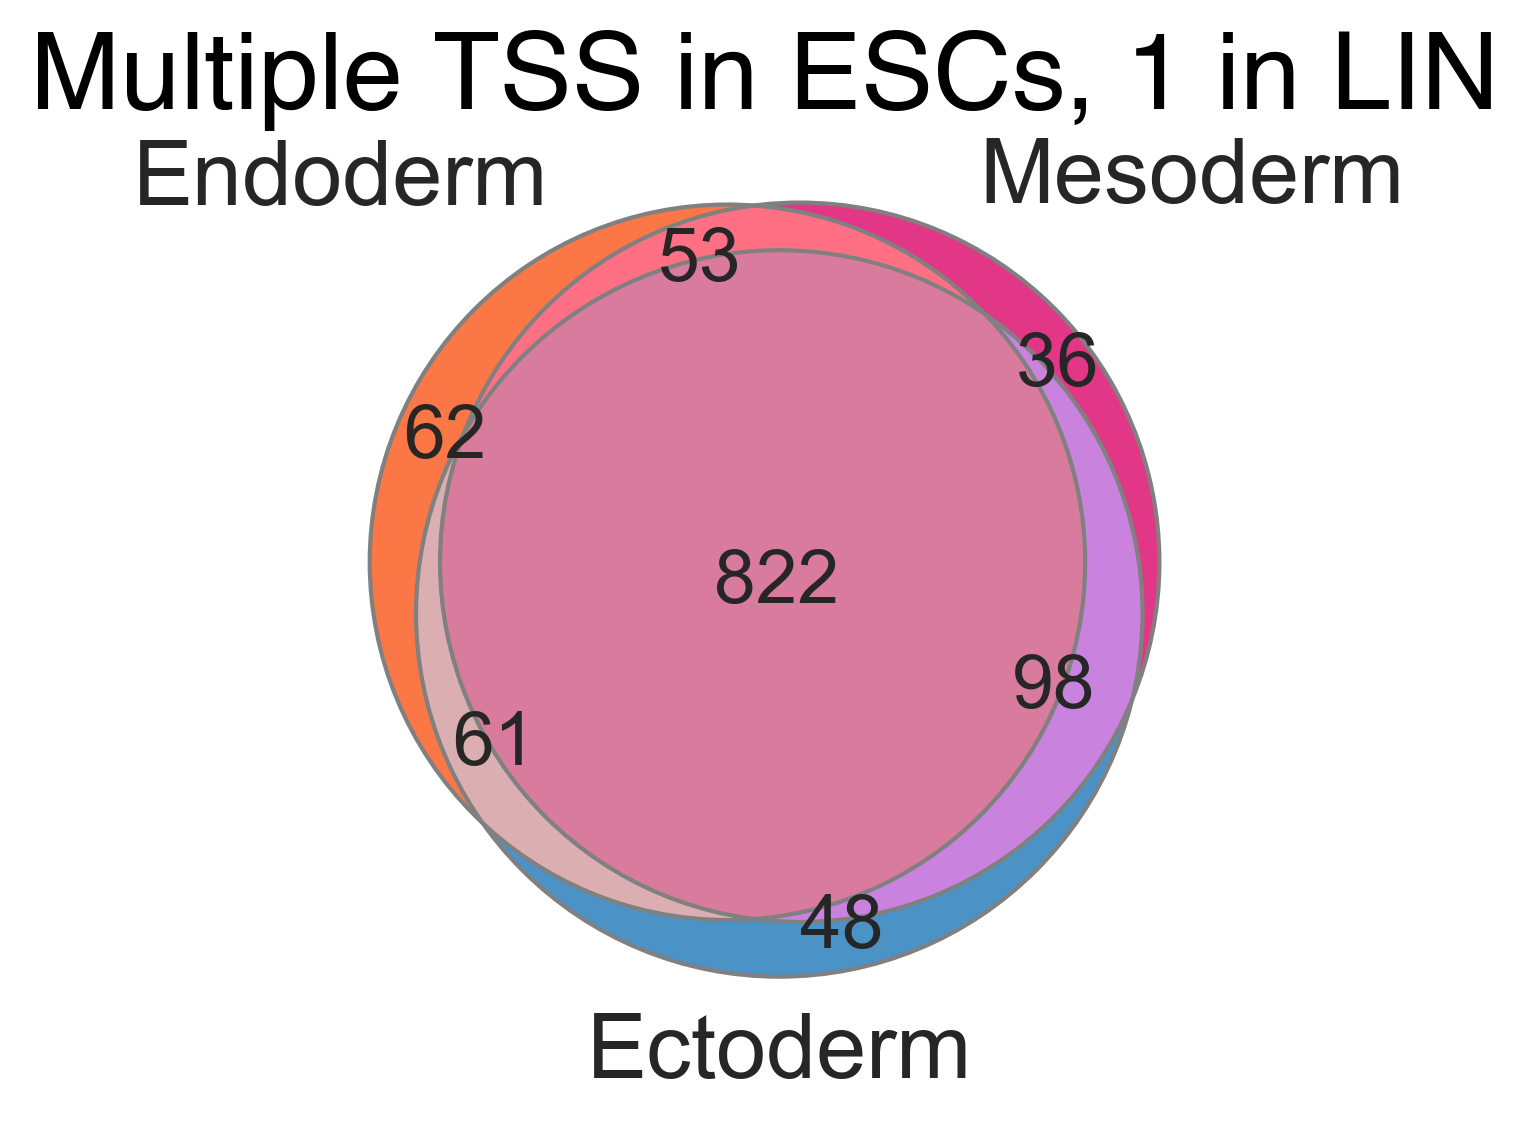

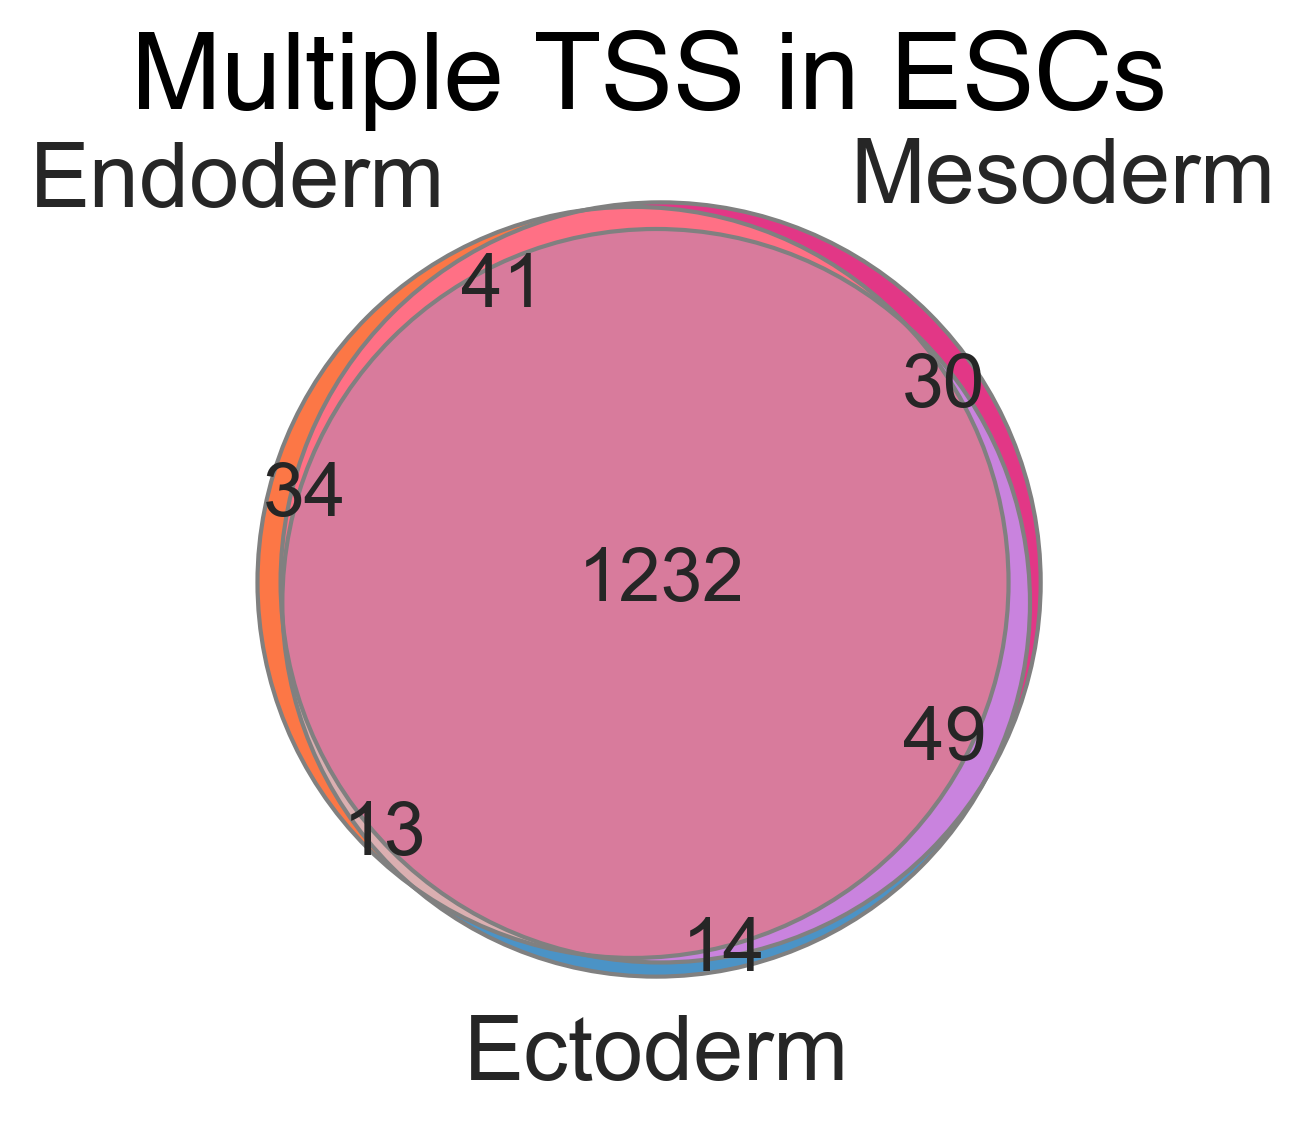

In [53]:
a = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == 'END') & (numTSS_ESCm['count'] == 1)]['gene'])
b = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == 'MES') & (numTSS_ESCm['count'] == 1)]['gene'])
c = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == 'ECT') & (numTSS_ESCm['count'] == 1)]['gene'])


venn3([set(a),set(b),set(c)], set_labels = ('Endoderm','Mesoderm', 'Ectoderm'),
      set_colors=[ '#fc6832', '#df2179','#3787c0'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('Multiple TSS in ESCs, 1 in LIN', fontdict=font1)
plt.show()

a = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == 'END') ]['gene'])
b = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == 'MES') ]['gene'])
c = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == 'ECT')]['gene'])


venn3([set(a),set(b),set(c)], set_labels = ('Endoderm','Mesoderm', 'Ectoderm'),
      set_colors=[ '#fc6832', '#df2179','#3787c0'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('Multiple TSS in ESCs', fontdict=font1)
plt.show()



Text(0, 0.5, '# genes')

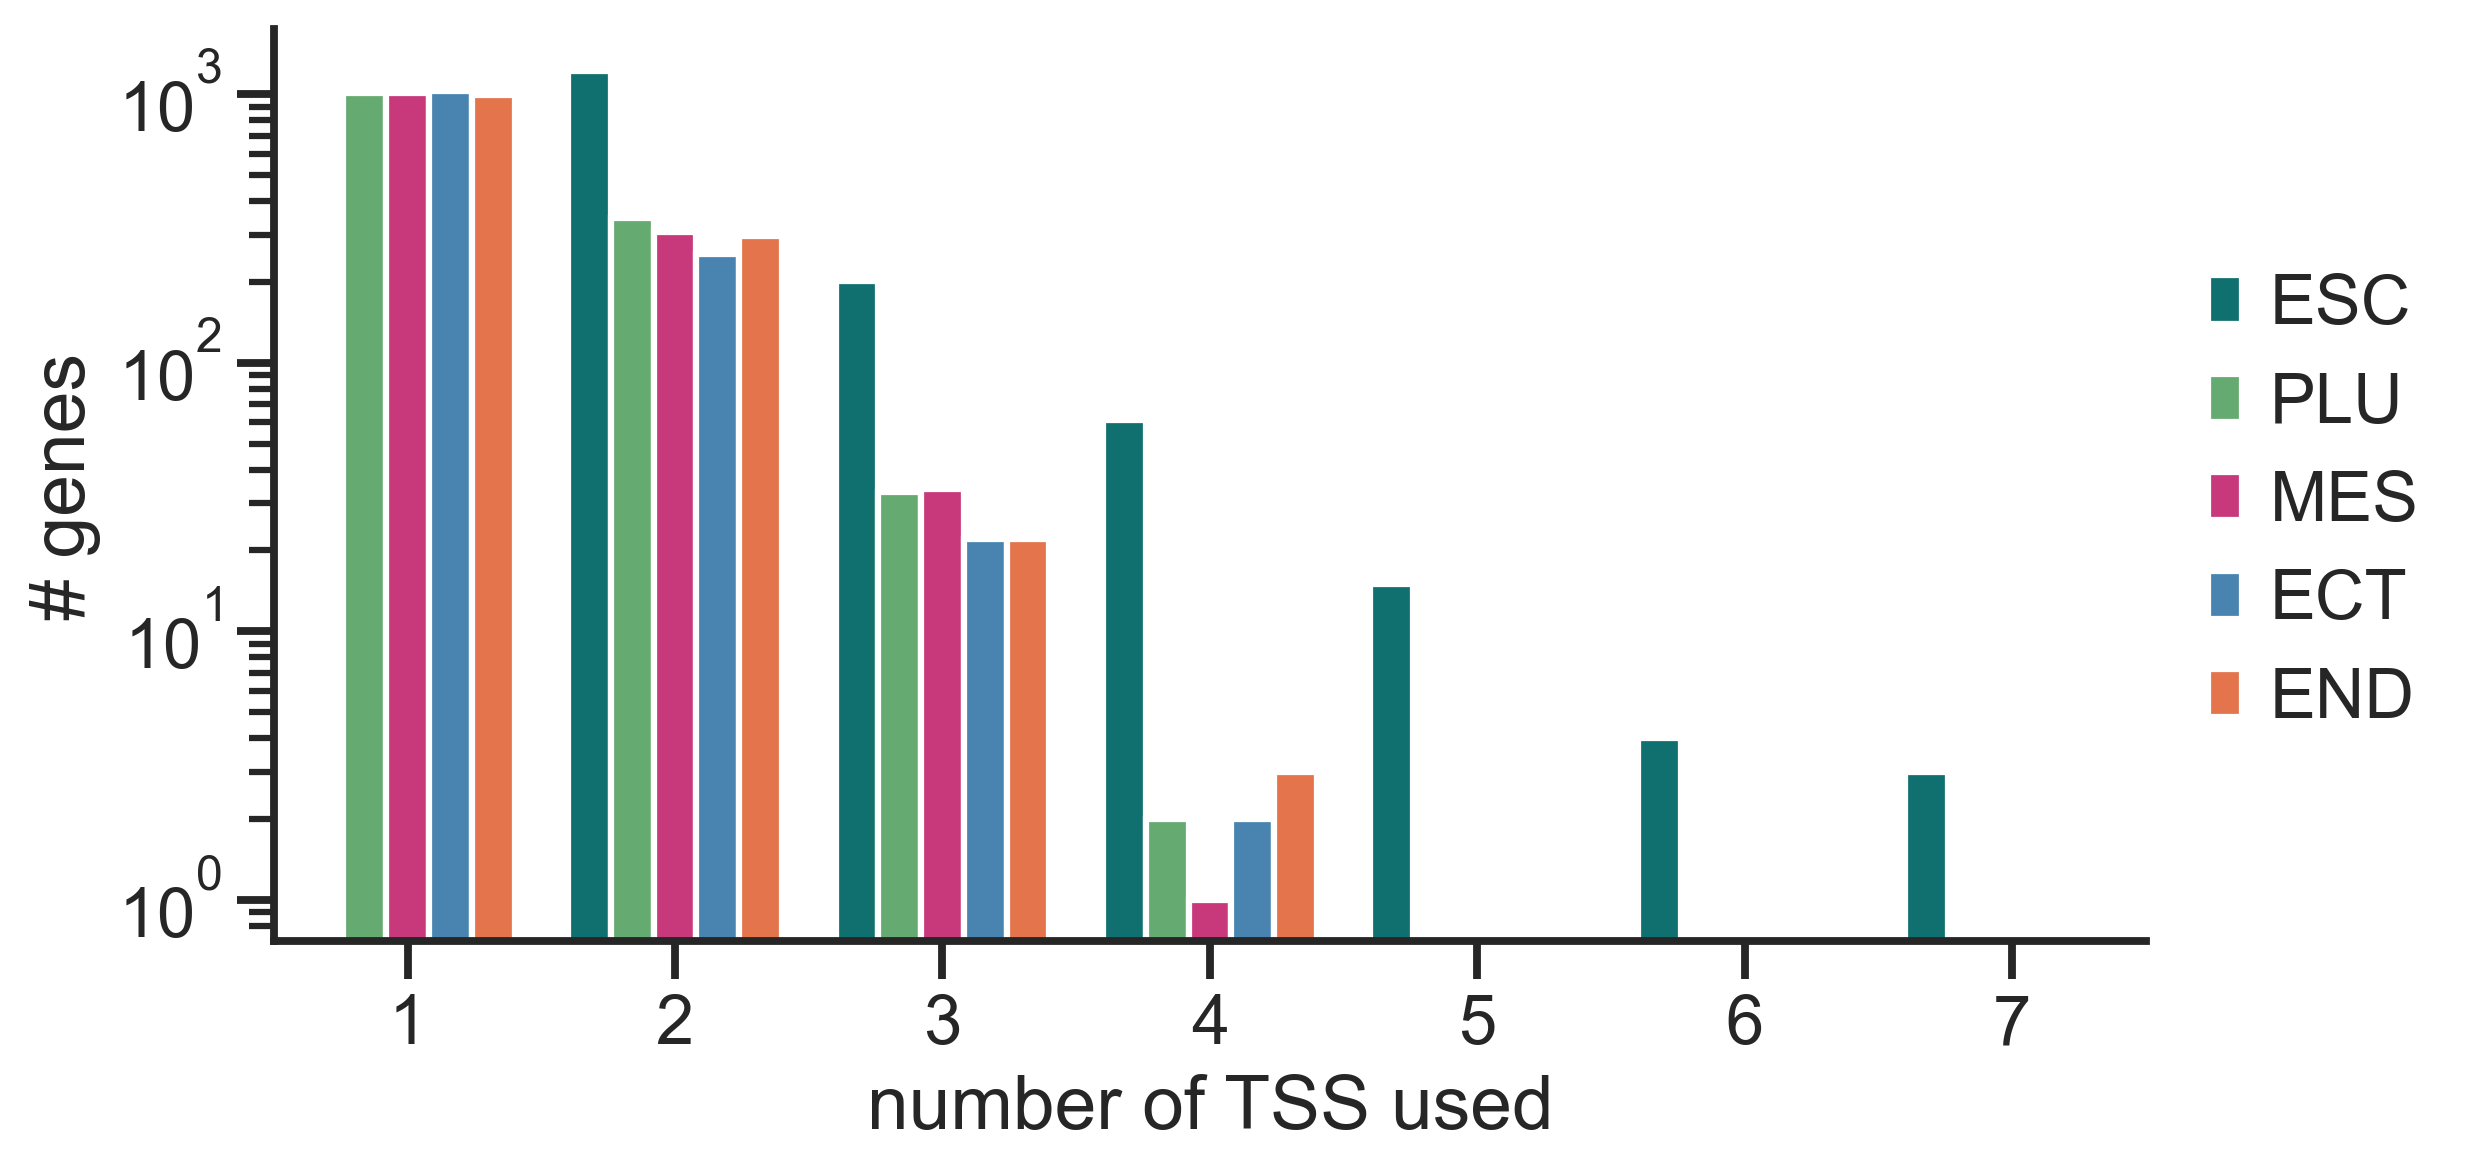

In [54]:
# multiple TSS in ESCs
sumcounts3 = pd.DataFrame(numTSS_ESCm[['count','Lin']].value_counts()).rename(columns={0:'sum'}).reset_index()

fig,ax=plt.subplots(figsize = (8,4))
sns.barplot(x = sumcounts3['count'], y=sumcounts3['sum'],hue=sumcounts3['Lin'], ax=ax, palette = ['teal','#58b669','#df2179','#3787c0', '#fc6832'], hue_order = ['ESC','PLU','MES','ECT','END'])
sns.despine()
plt.yscale('log',)
plt.legend(bbox_to_anchor=(1,0.8),frameon=False)
plt.xlabel('number of TSS used')
plt.ylabel('# genes')
#ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))



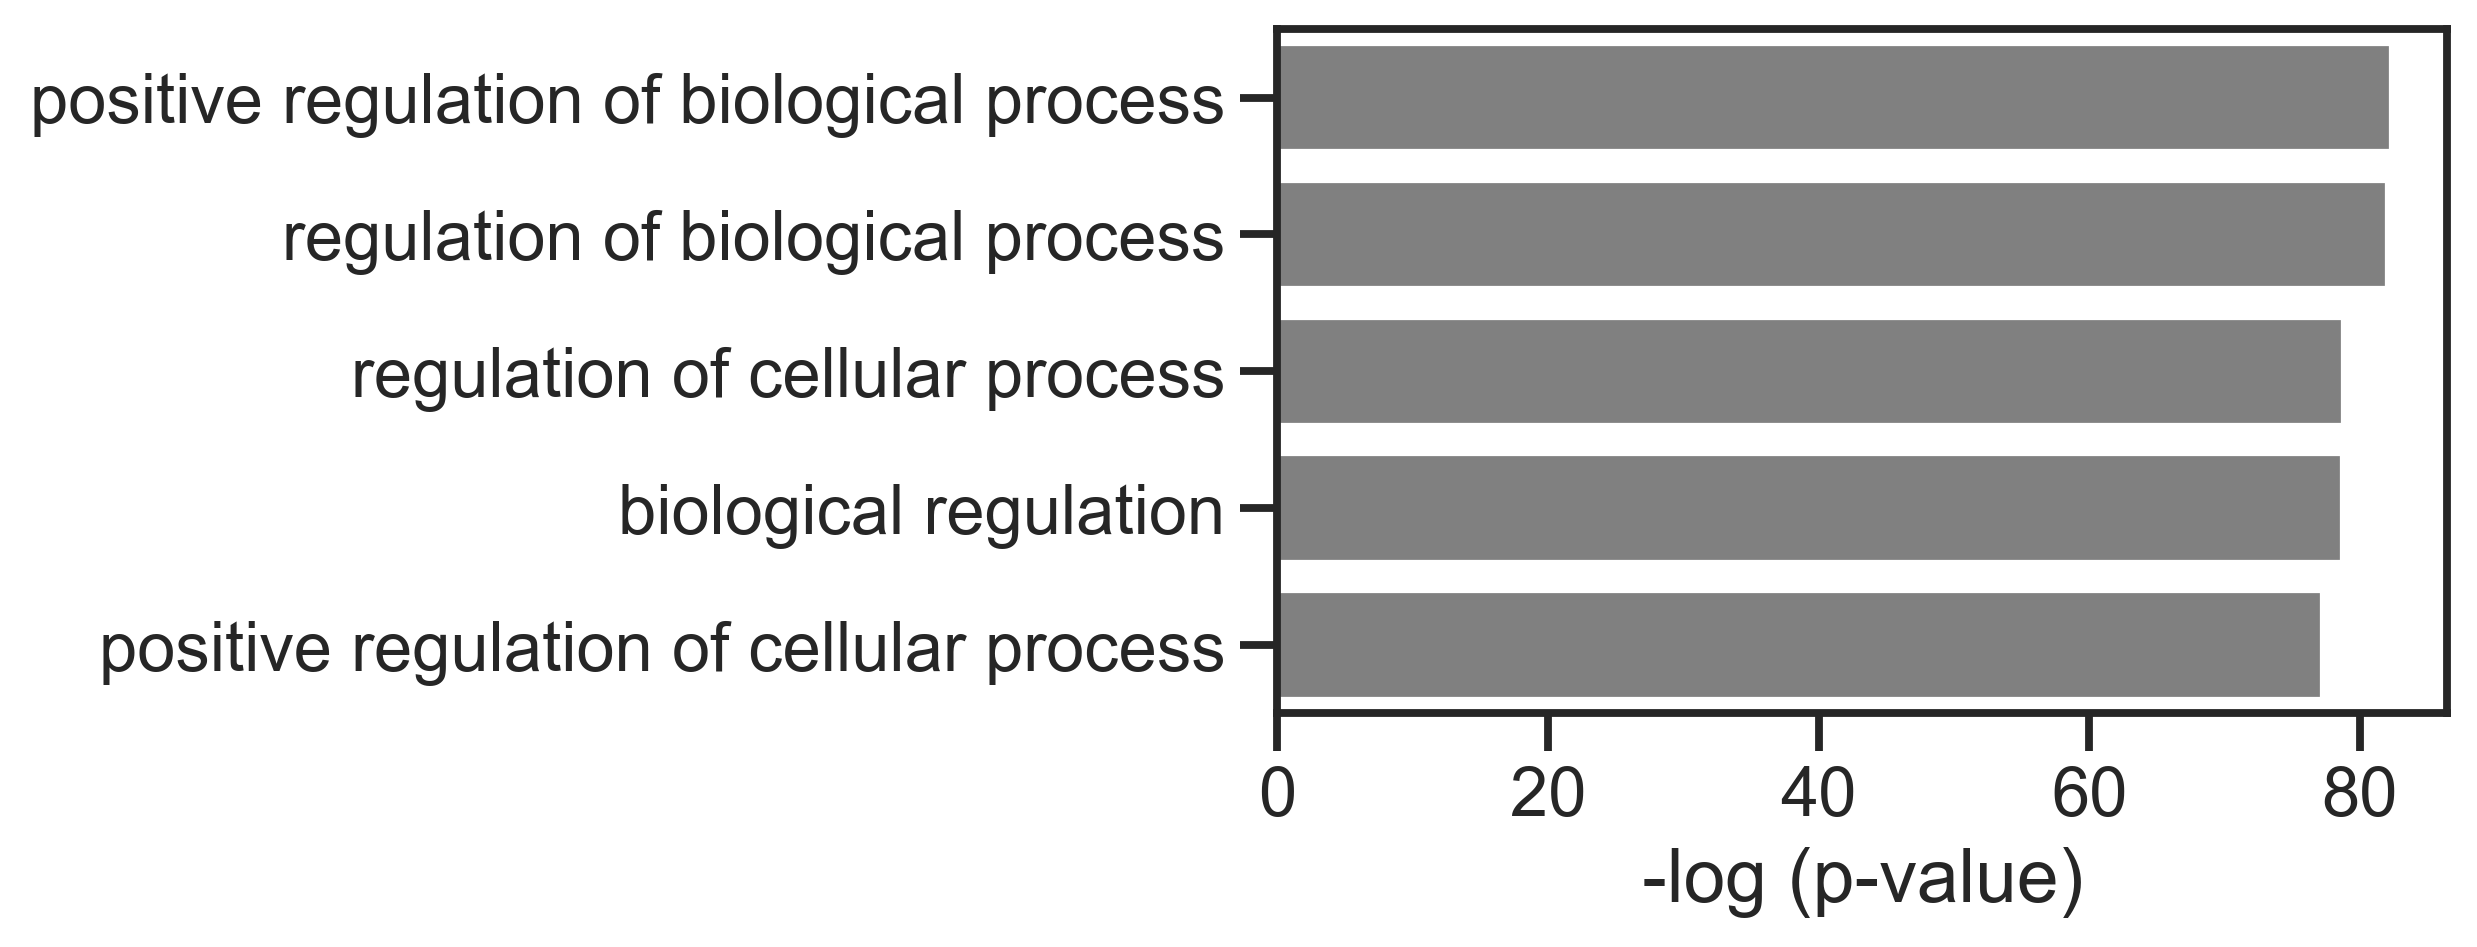

In [55]:
# GO for all genes with multiple TSS in ESCs
genes = list(numTSS_ESCm['gene'].unique())
makeGO(genes, figsize = (5,3), num=5)

Text(0.5, 1.0, 'Multiple TSS in ESC, reverts to 1 in END')

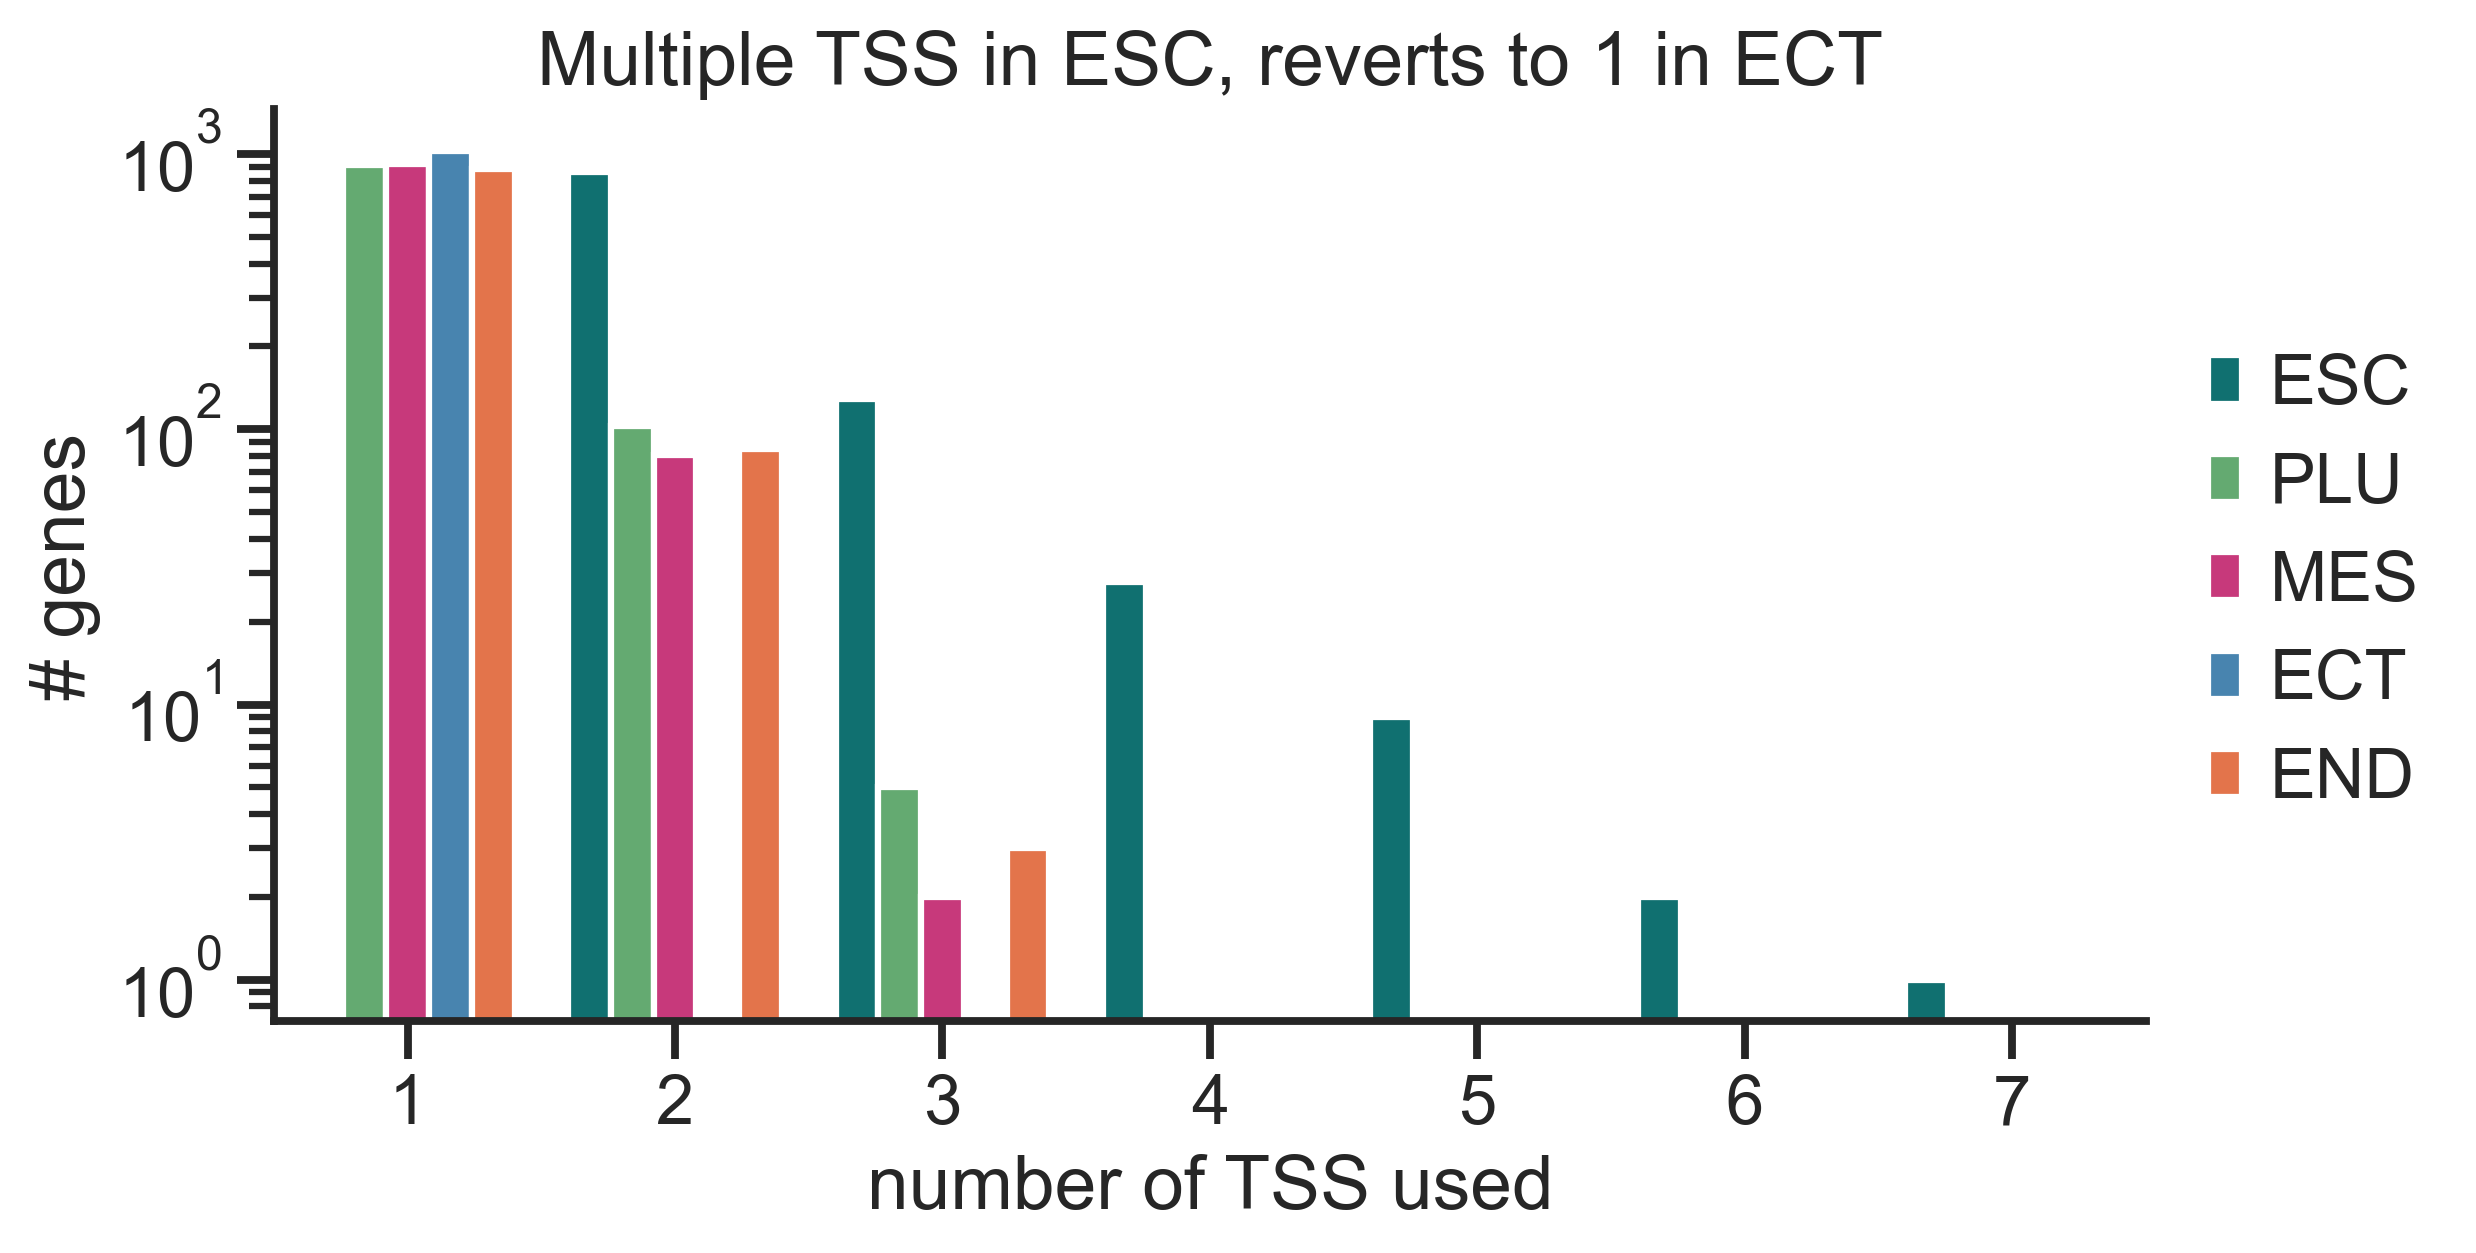

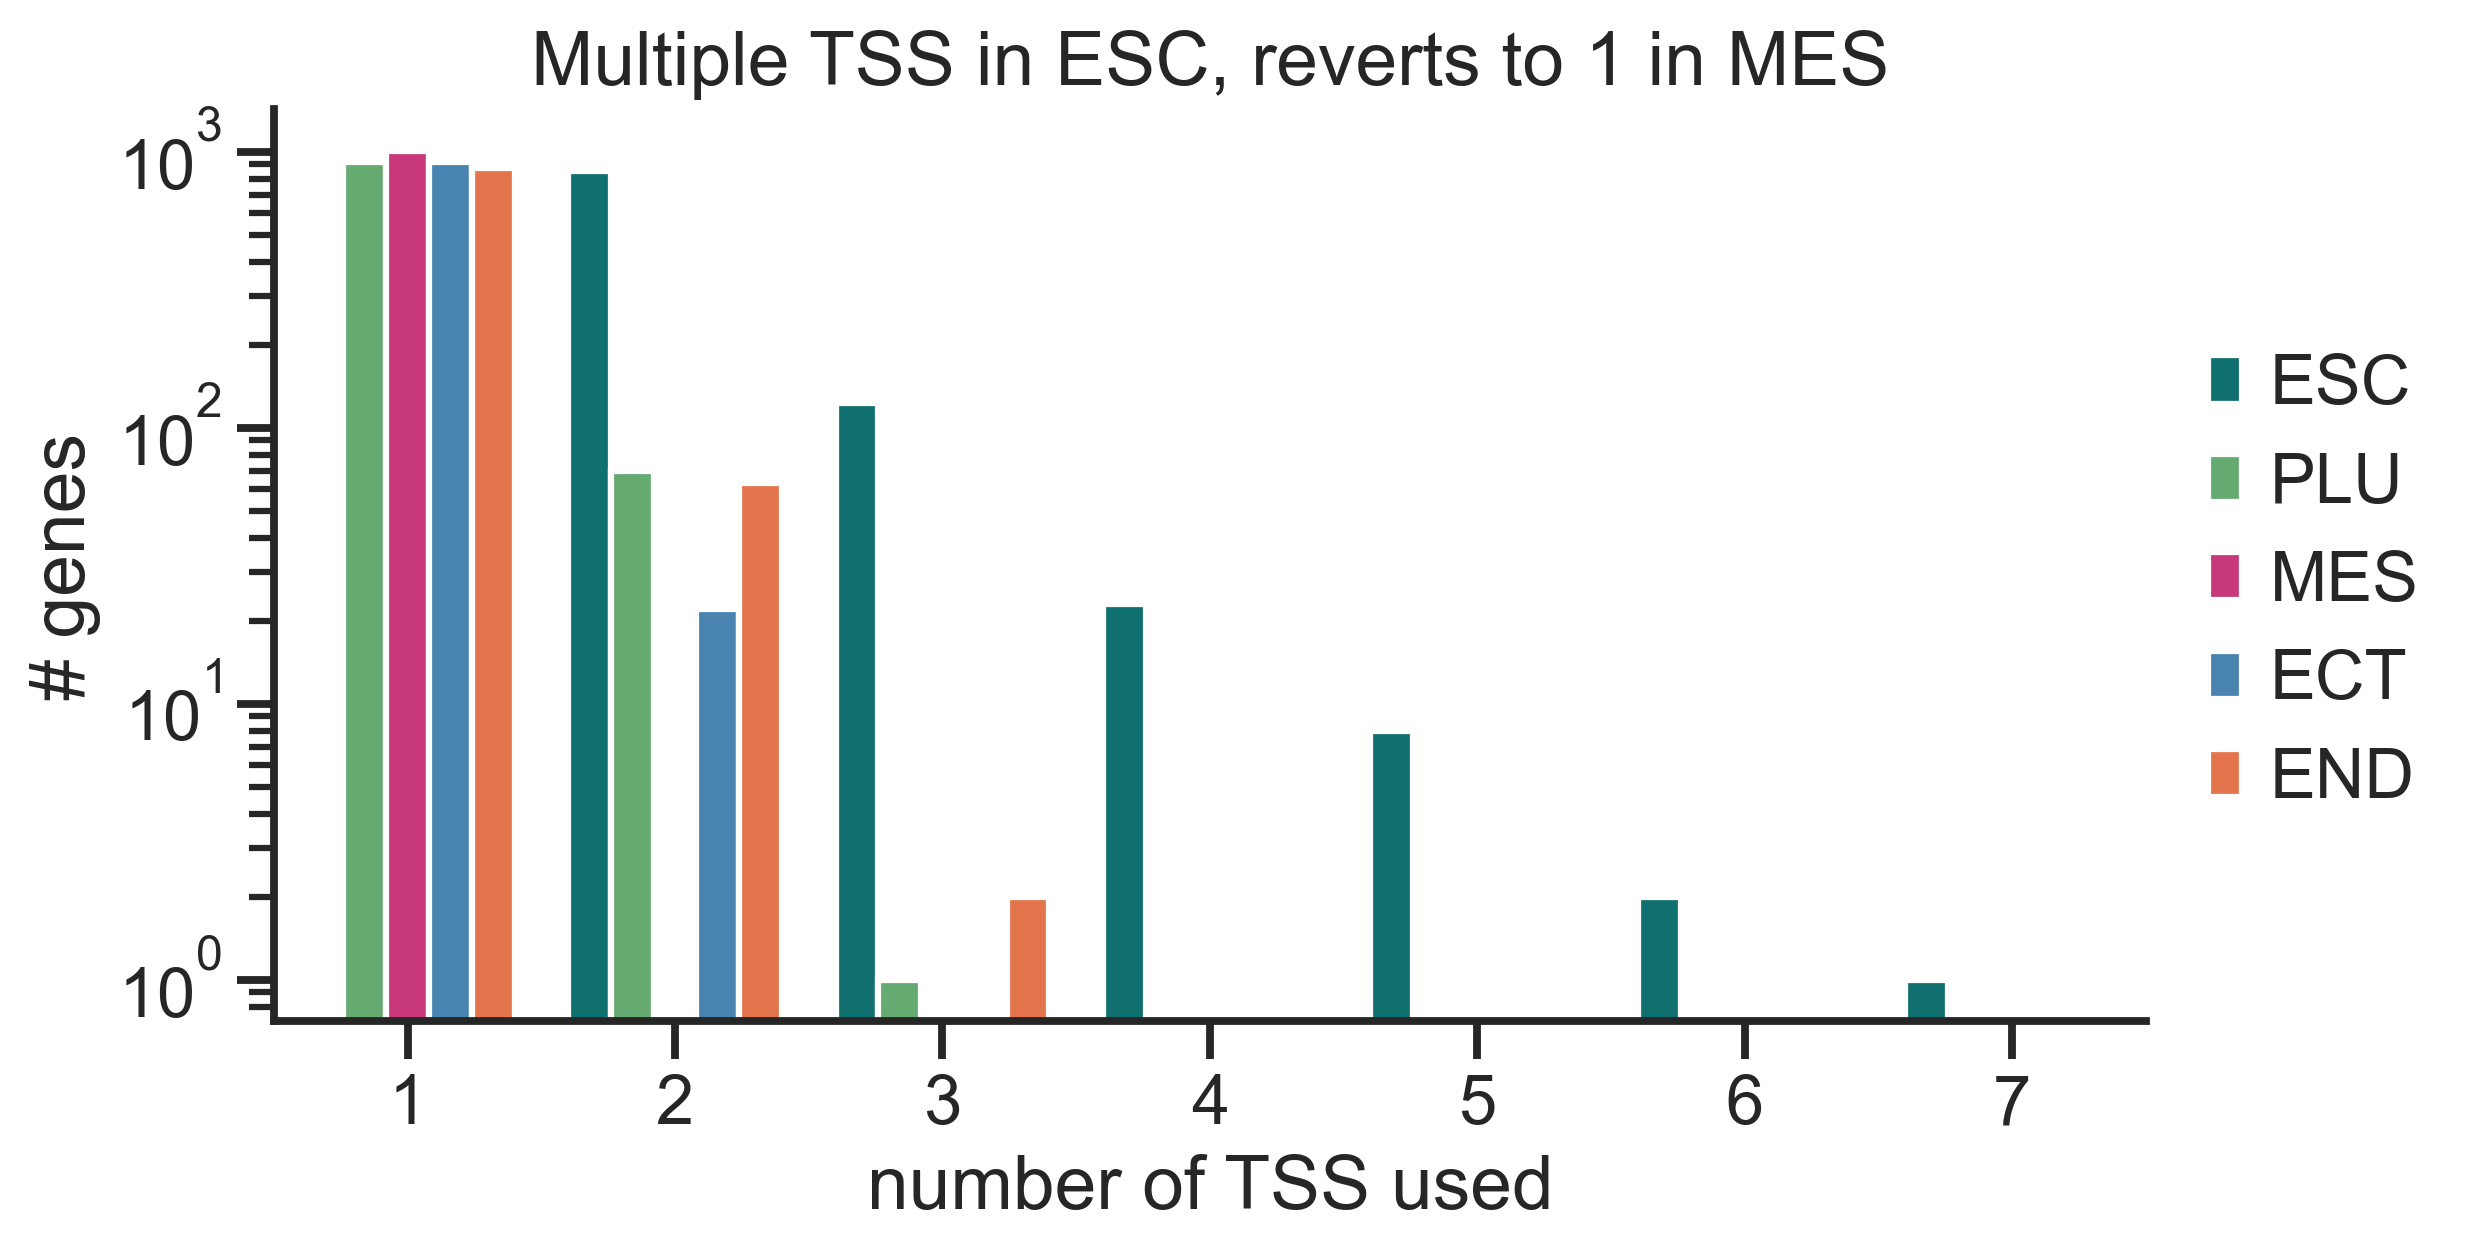

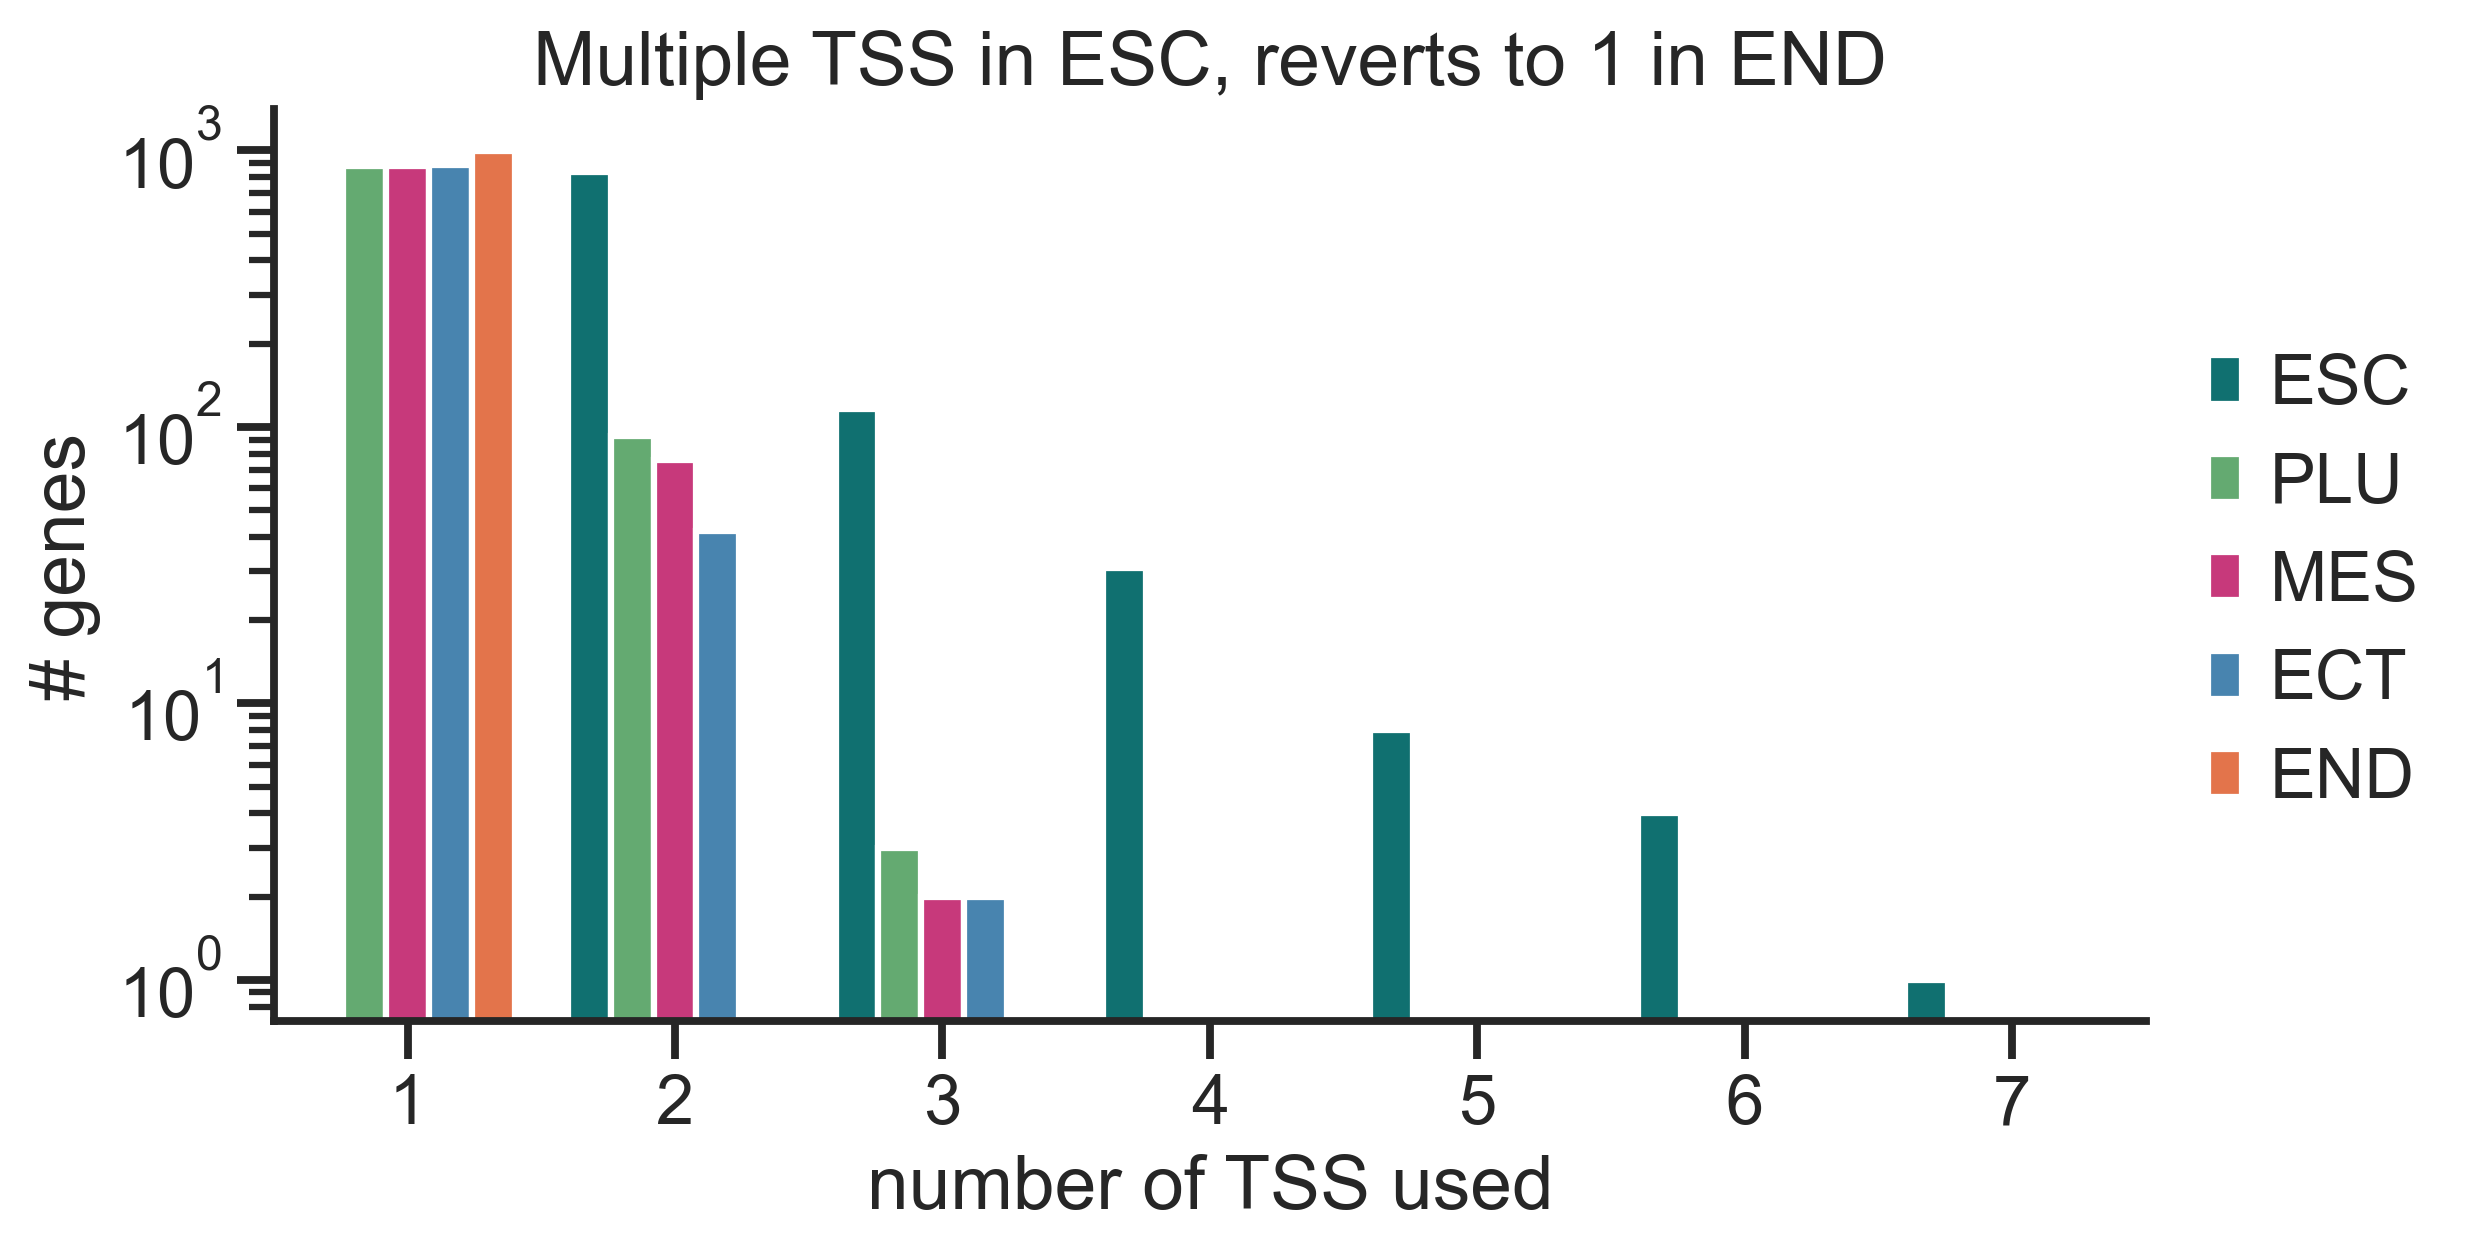

In [56]:
# multiple TSS in ESCs, reverts to 1 in ECT
genes = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == 'ECT') & (numTSS_ESCm['count'] == 1)]['gene'])
numTSS_ESCm_ECTm = numTSS_ESCm[(numTSS_ESCm['gene'].isin(genes))]

sumcounts4 = pd.DataFrame(numTSS_ESCm_ECTm[['count','Lin']].value_counts()).rename(columns={0:'sum'}).reset_index()

fig,ax=plt.subplots(figsize = (8,4))
sns.barplot(x = sumcounts4['count'], y=sumcounts4['sum'],hue=sumcounts4['Lin'], ax=ax, palette = ['teal','#58b669','#df2179','#3787c0', '#fc6832'],hue_order = ['ESC','PLU','MES','ECT','END'])
sns.despine()
plt.yscale('log',)
plt.legend(bbox_to_anchor=(1,0.8),frameon=False)
plt.title('Multiple TSS in ESC, reverts to 1 in ECT')
plt.xlabel('number of TSS used')
plt.ylabel('# genes')
#ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))


# multiple TSS in ESCs, reverts to 1 in MES
genes = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == 'MES') & (numTSS_ESCm['count'] == 1)]['gene'])
numTSS_ESCm_MESm = numTSS_ESCm[(numTSS_ESCm['gene'].isin(genes))]

sumcounts4 = pd.DataFrame(numTSS_ESCm_MESm[['count','Lin']].value_counts()).rename(columns={0:'sum'}).reset_index()

fig,ax=plt.subplots(figsize = (8,4))
sns.barplot(x = sumcounts4['count'], y=sumcounts4['sum'],hue=sumcounts4['Lin'], ax=ax, palette = ['teal','#58b669','#df2179','#3787c0', '#fc6832'],hue_order = ['ESC','PLU','MES','ECT','END'])
sns.despine()
plt.yscale('log',)
plt.legend(bbox_to_anchor=(1,0.8),frameon=False)
plt.xlabel('number of TSS used')
plt.ylabel('# genes')
plt.title('Multiple TSS in ESC, reverts to 1 in MES')
#ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

# multiple TSS in ESC, reverts to 1 in END
genes = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == 'END') & (numTSS_ESCm['count'] == 1)]['gene'])
numTSS_ESCm_ENDm =numTSS_ESCm[(numTSS_ESCm['gene'].isin(genes))]

sumcounts4 = pd.DataFrame(numTSS_ESCm_ENDm[['count','Lin']].value_counts()).rename(columns={0:'sum'}).reset_index()

fig,ax=plt.subplots(figsize = (8,4))
sns.barplot(x = sumcounts4['count'], y=sumcounts4['sum'],hue=sumcounts4['Lin'], ax=ax, palette = ['teal','#58b669','#df2179','#3787c0', '#fc6832'],hue_order = ['ESC','PLU','MES','ECT','END'])
sns.despine()
plt.yscale('log',)
plt.legend(bbox_to_anchor=(1,0.8),frameon=False)
plt.xlabel('number of TSS used')
plt.ylabel('# genes')
plt.title('Multiple TSS in ESC, reverts to 1 in END')
#ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))



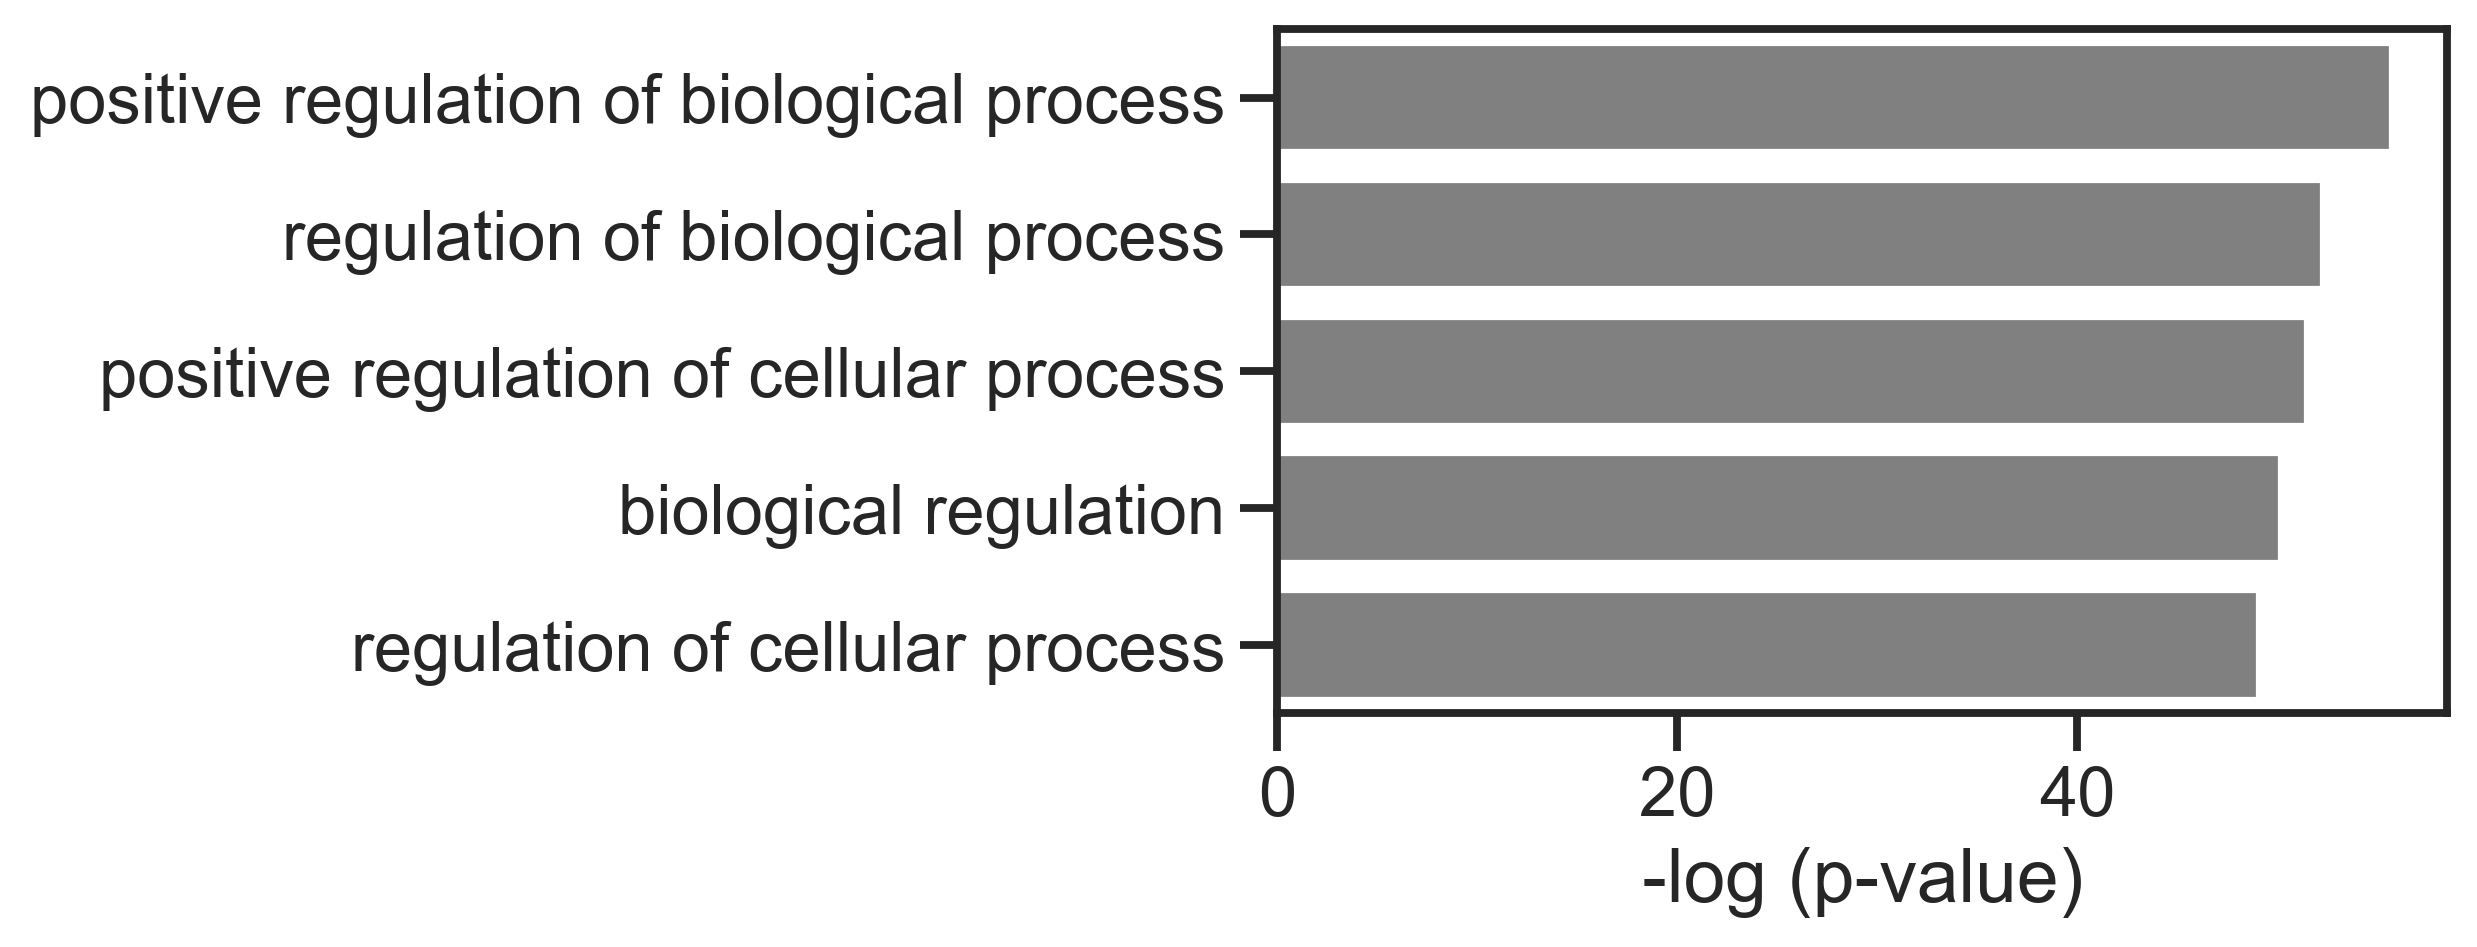

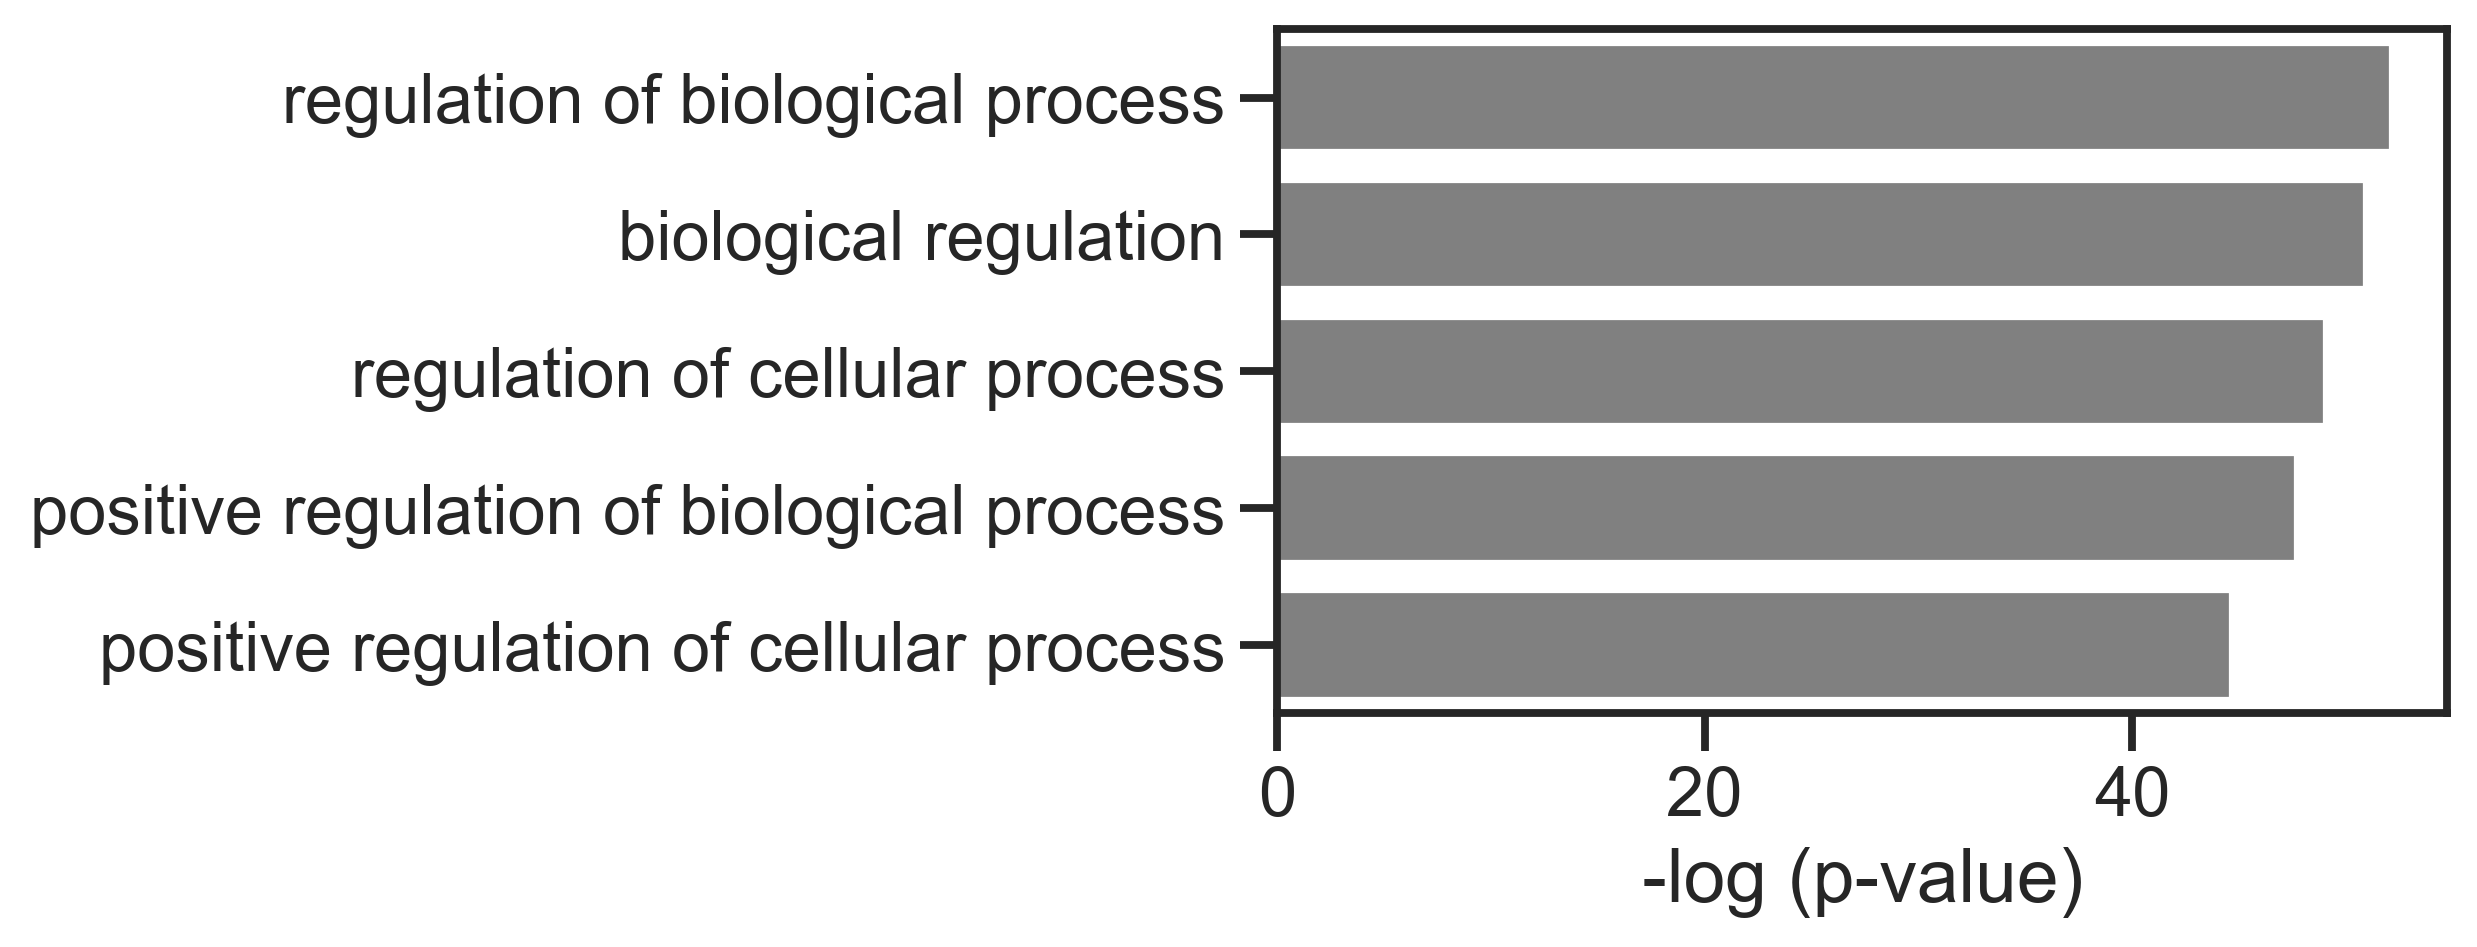

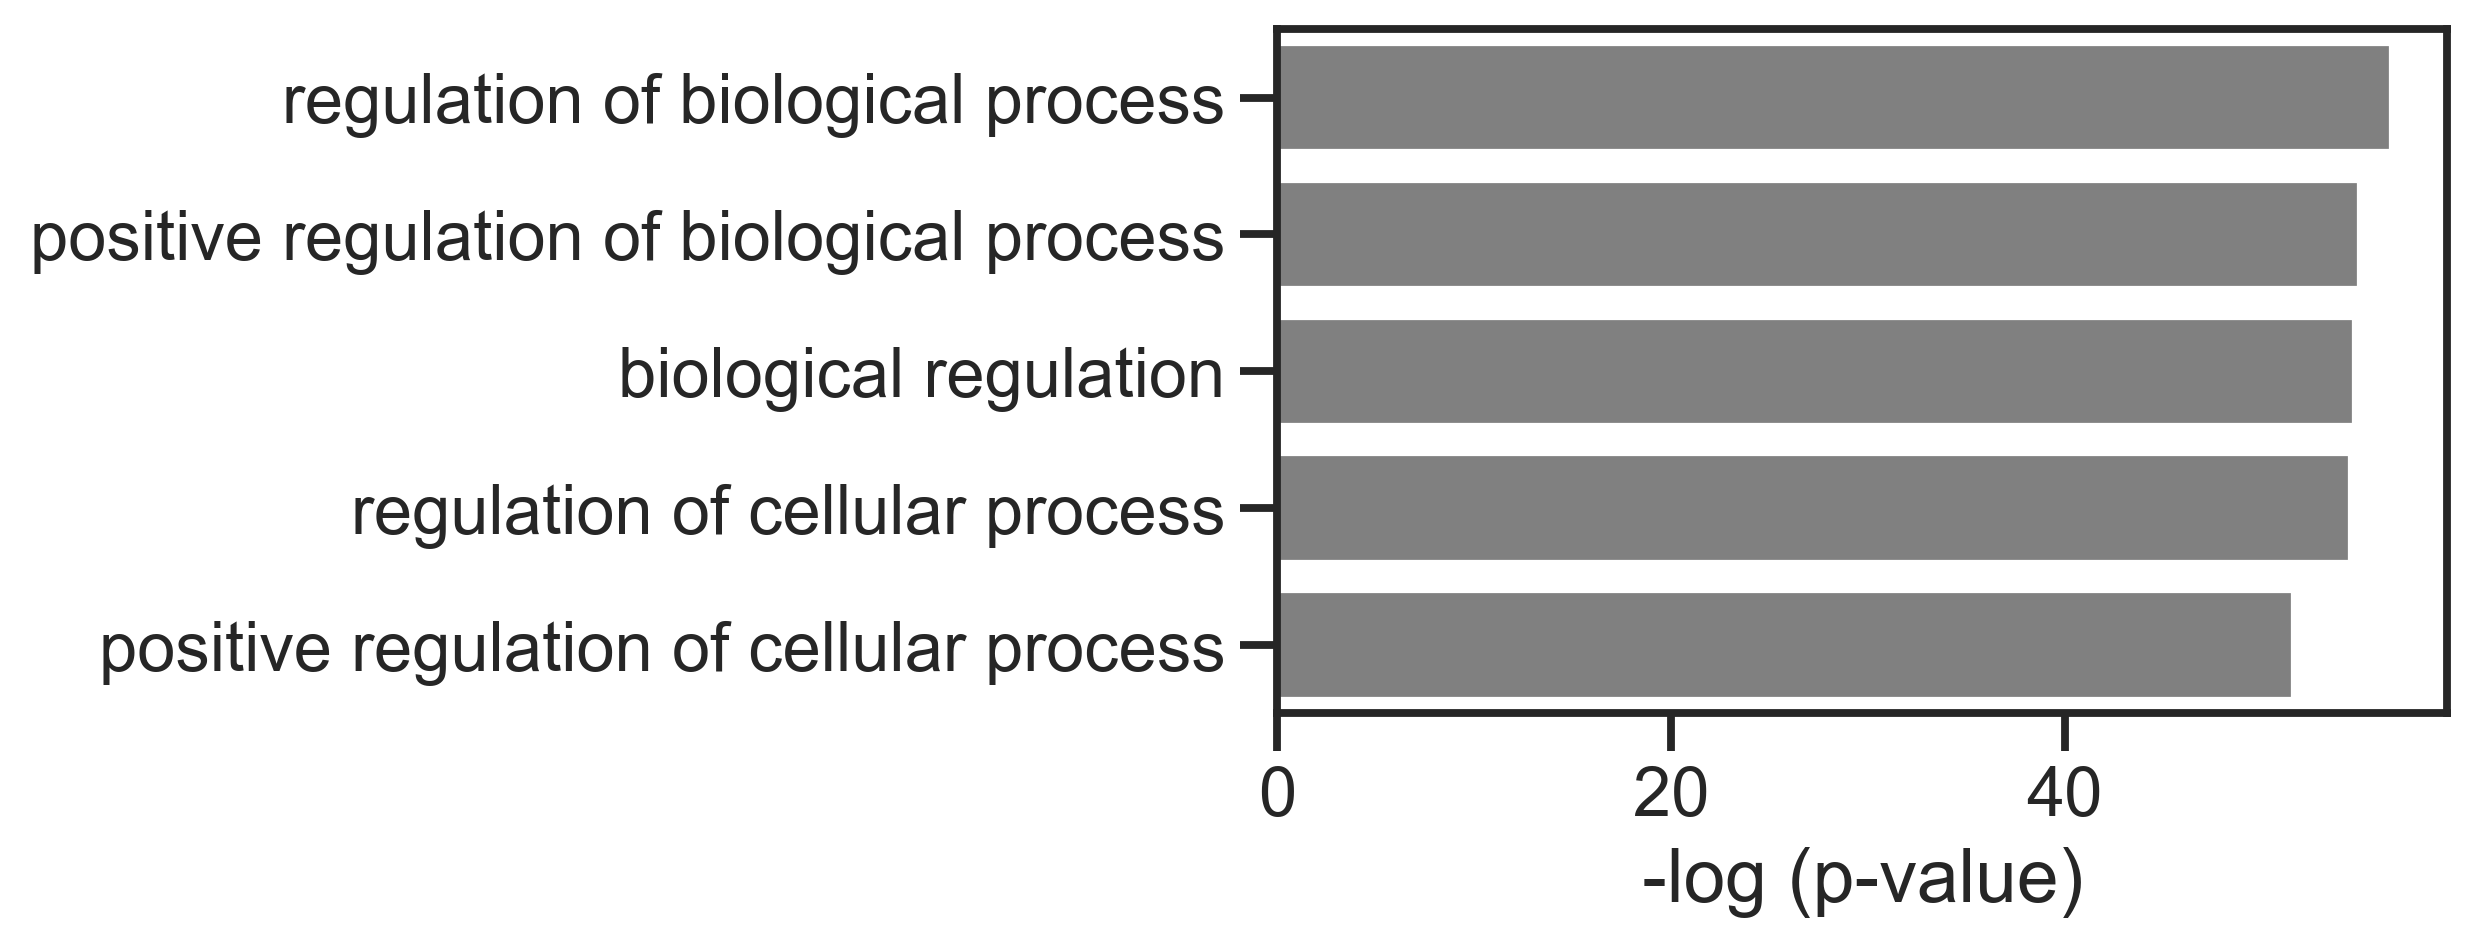

In [57]:
# GO for all genes with multiple TSS in ESCs, reverts to 1 in END
genes = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == 'END') & (numTSS_ESCm['count'] == 1)]['gene'])
makeGO(genes, figsize = (5,3), num=5)

# GO for all genes with multiple TSS in ESCs, reverts to 1 in MES
genes = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == 'MES') & (numTSS_ESCm['count'] == 1)]['gene'])
makeGO(genes, figsize = (5,3), num=5)

# GO for all genes with multiple TSS in ESCs, reverts to 1 in ECT
genes = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == 'ECT') & (numTSS_ESCm['count'] == 1)]['gene'])
makeGO(genes, figsize = (5,3), num=5)

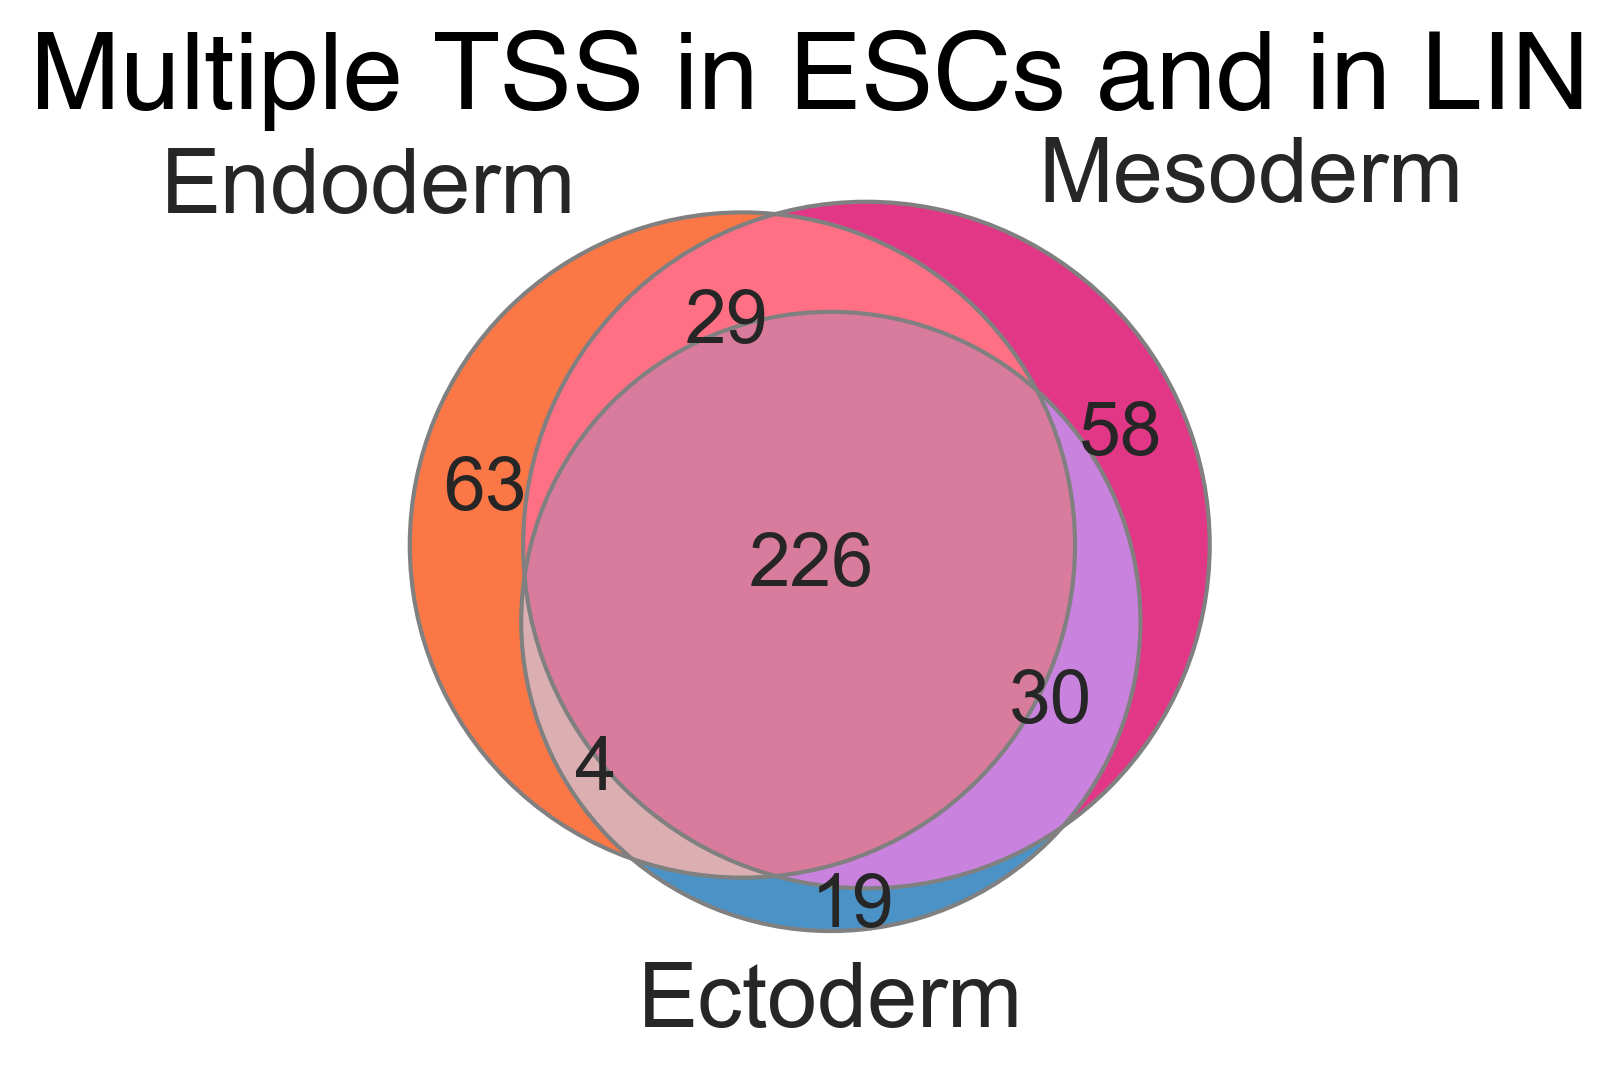

In [58]:
## multiple TSS in ESC and in lineage
a = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == 'END') & (numTSS_ESCm['count'] > 1)]['gene'])
b = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == 'MES') & (numTSS_ESCm['count'] > 1)]['gene'])
c = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == 'ECT') & (numTSS_ESCm['count'] > 1)]['gene'])


venn3([set(a),set(b),set(c)], set_labels = ('Endoderm','Mesoderm', 'Ectoderm'),
      set_colors=[ '#fc6832', '#df2179','#3787c0'], alpha = 0.9,)
venn3_circles([set(a),set(b),set(c)], linestyle = 'solid',linewidth = 1, color = 'grey')
plt.title('Multiple TSS in ESCs and in LIN', fontdict=font1)
plt.show()




In [59]:
numTSS_ESCm[(numTSS_ESCm['gene'].isin(c))]

,Lin,gene,count
1,ESC,Dst,7
2,ESC,Abr,7
5,ESC,Ssbp3,6
6,ESC,Myo10,6
7,ESC,Kdm2b,5
...,...,...,...
67633,END,Sucla2,1
67713,END,Spag9,1
67737,END,Specc1,1
67773,END,Ssbp3,1


In [60]:
all_genes = a + b + c

In [61]:
numTSS_ESCm_LINm = numTSS_ESCm[numTSS_ESCm['gene'].isin(all_genes)]
numTSS_ESCm_LINm.head(2)

,Lin,gene,count
1,ESC,Dst,7
2,ESC,Abr,7


Text(0.5, 1.0, 'Multiple TSS in ESC and END')

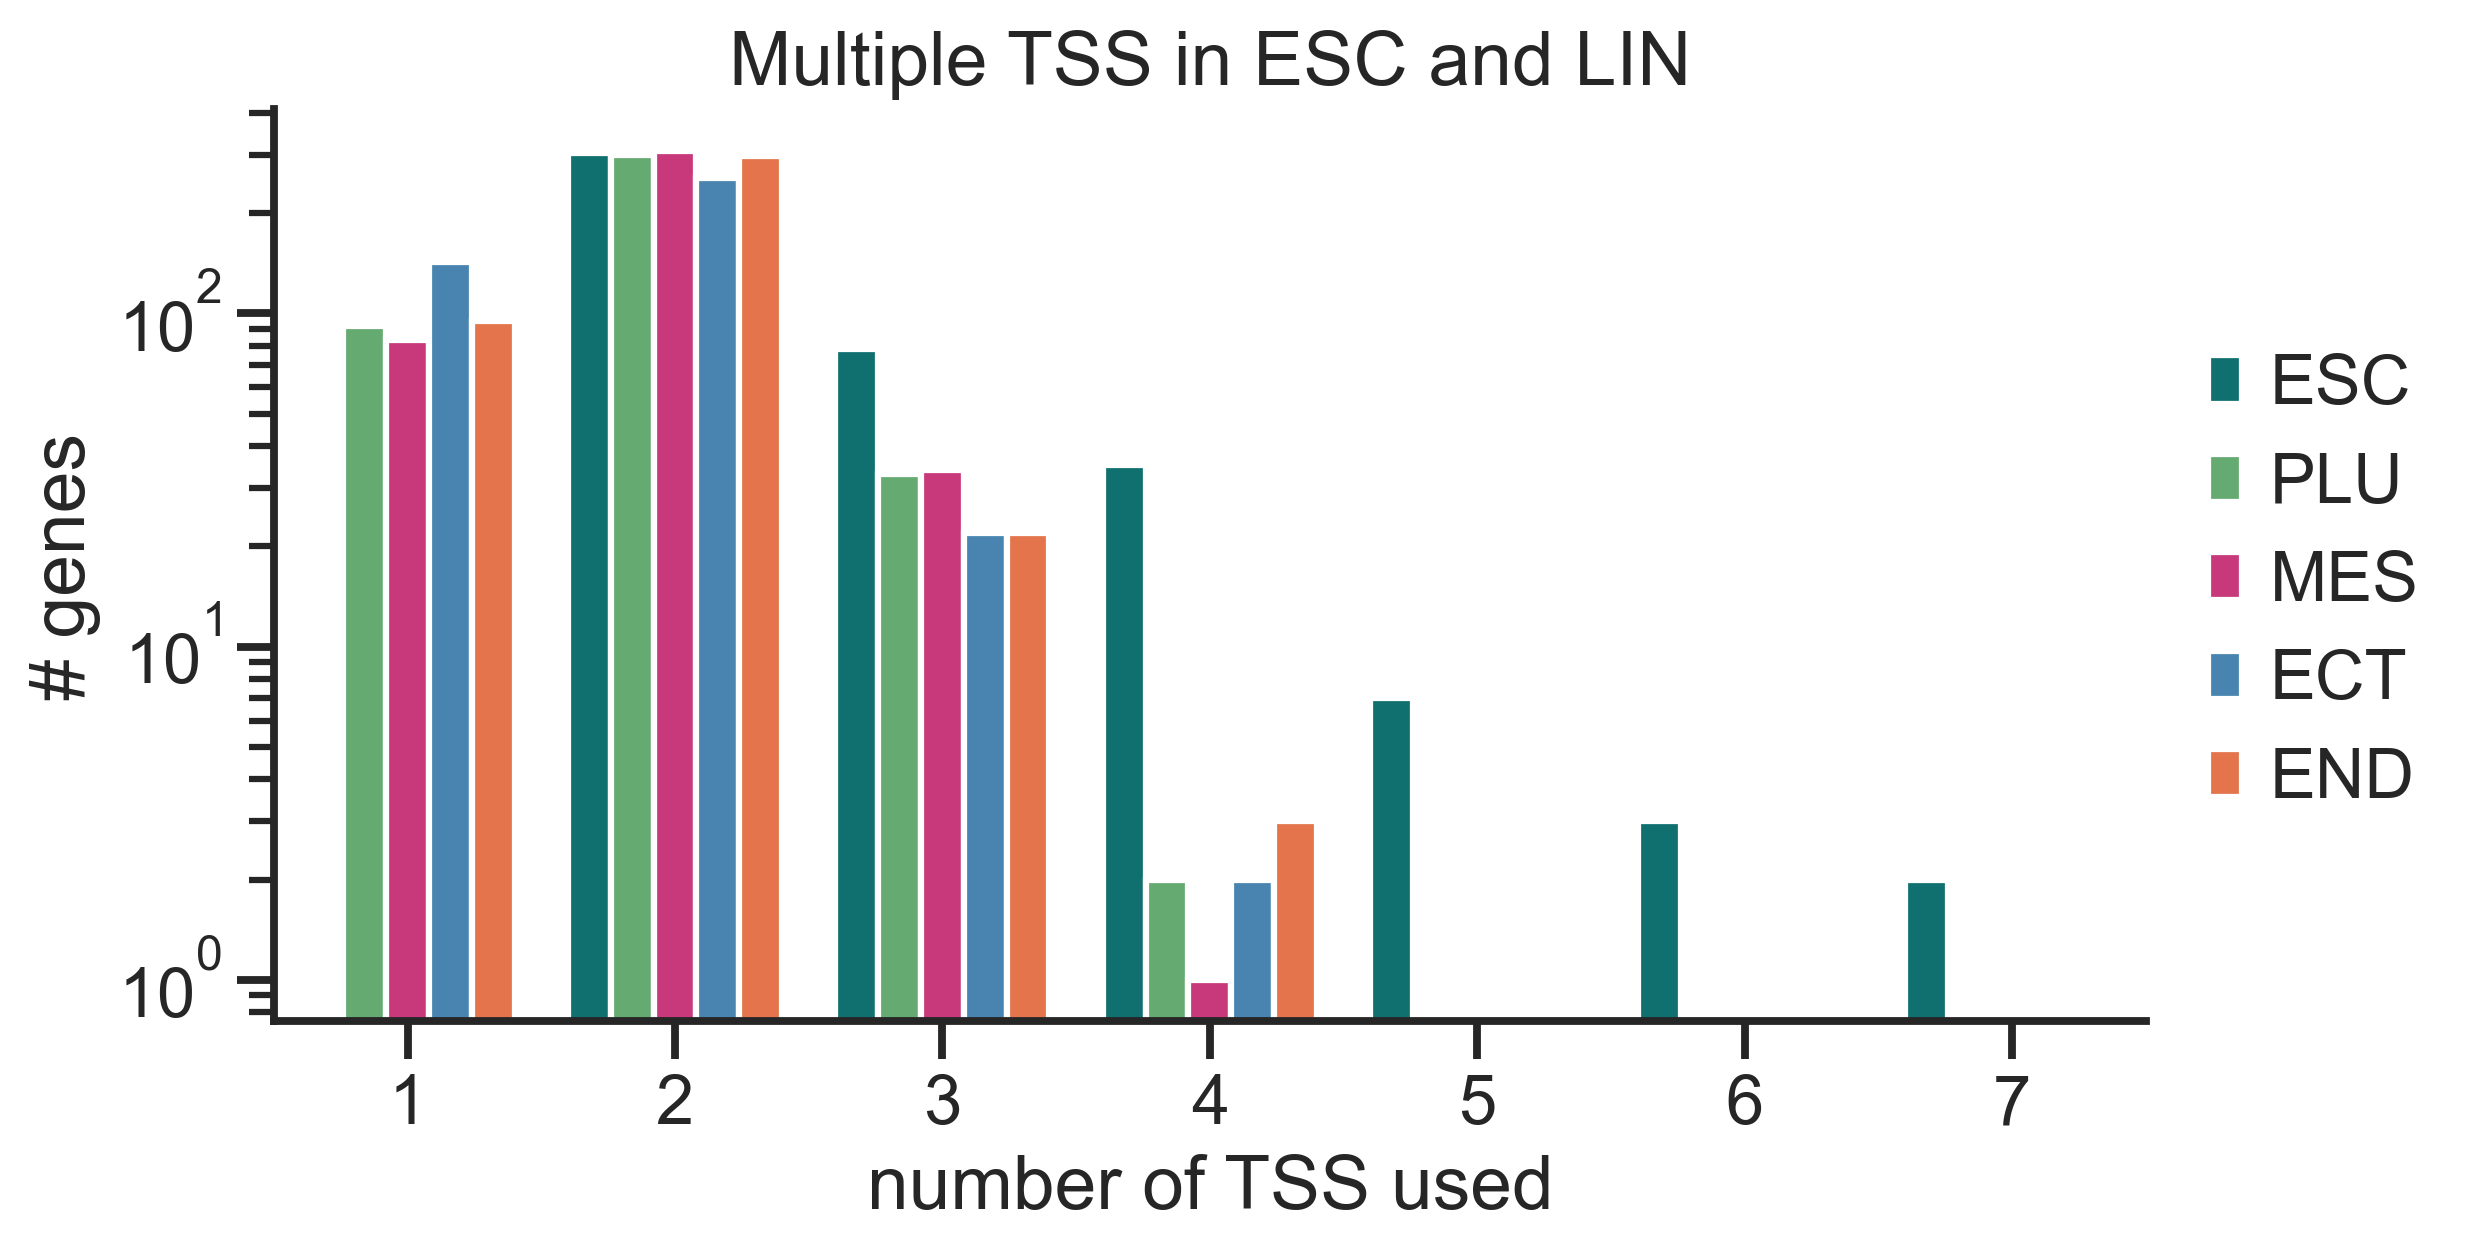

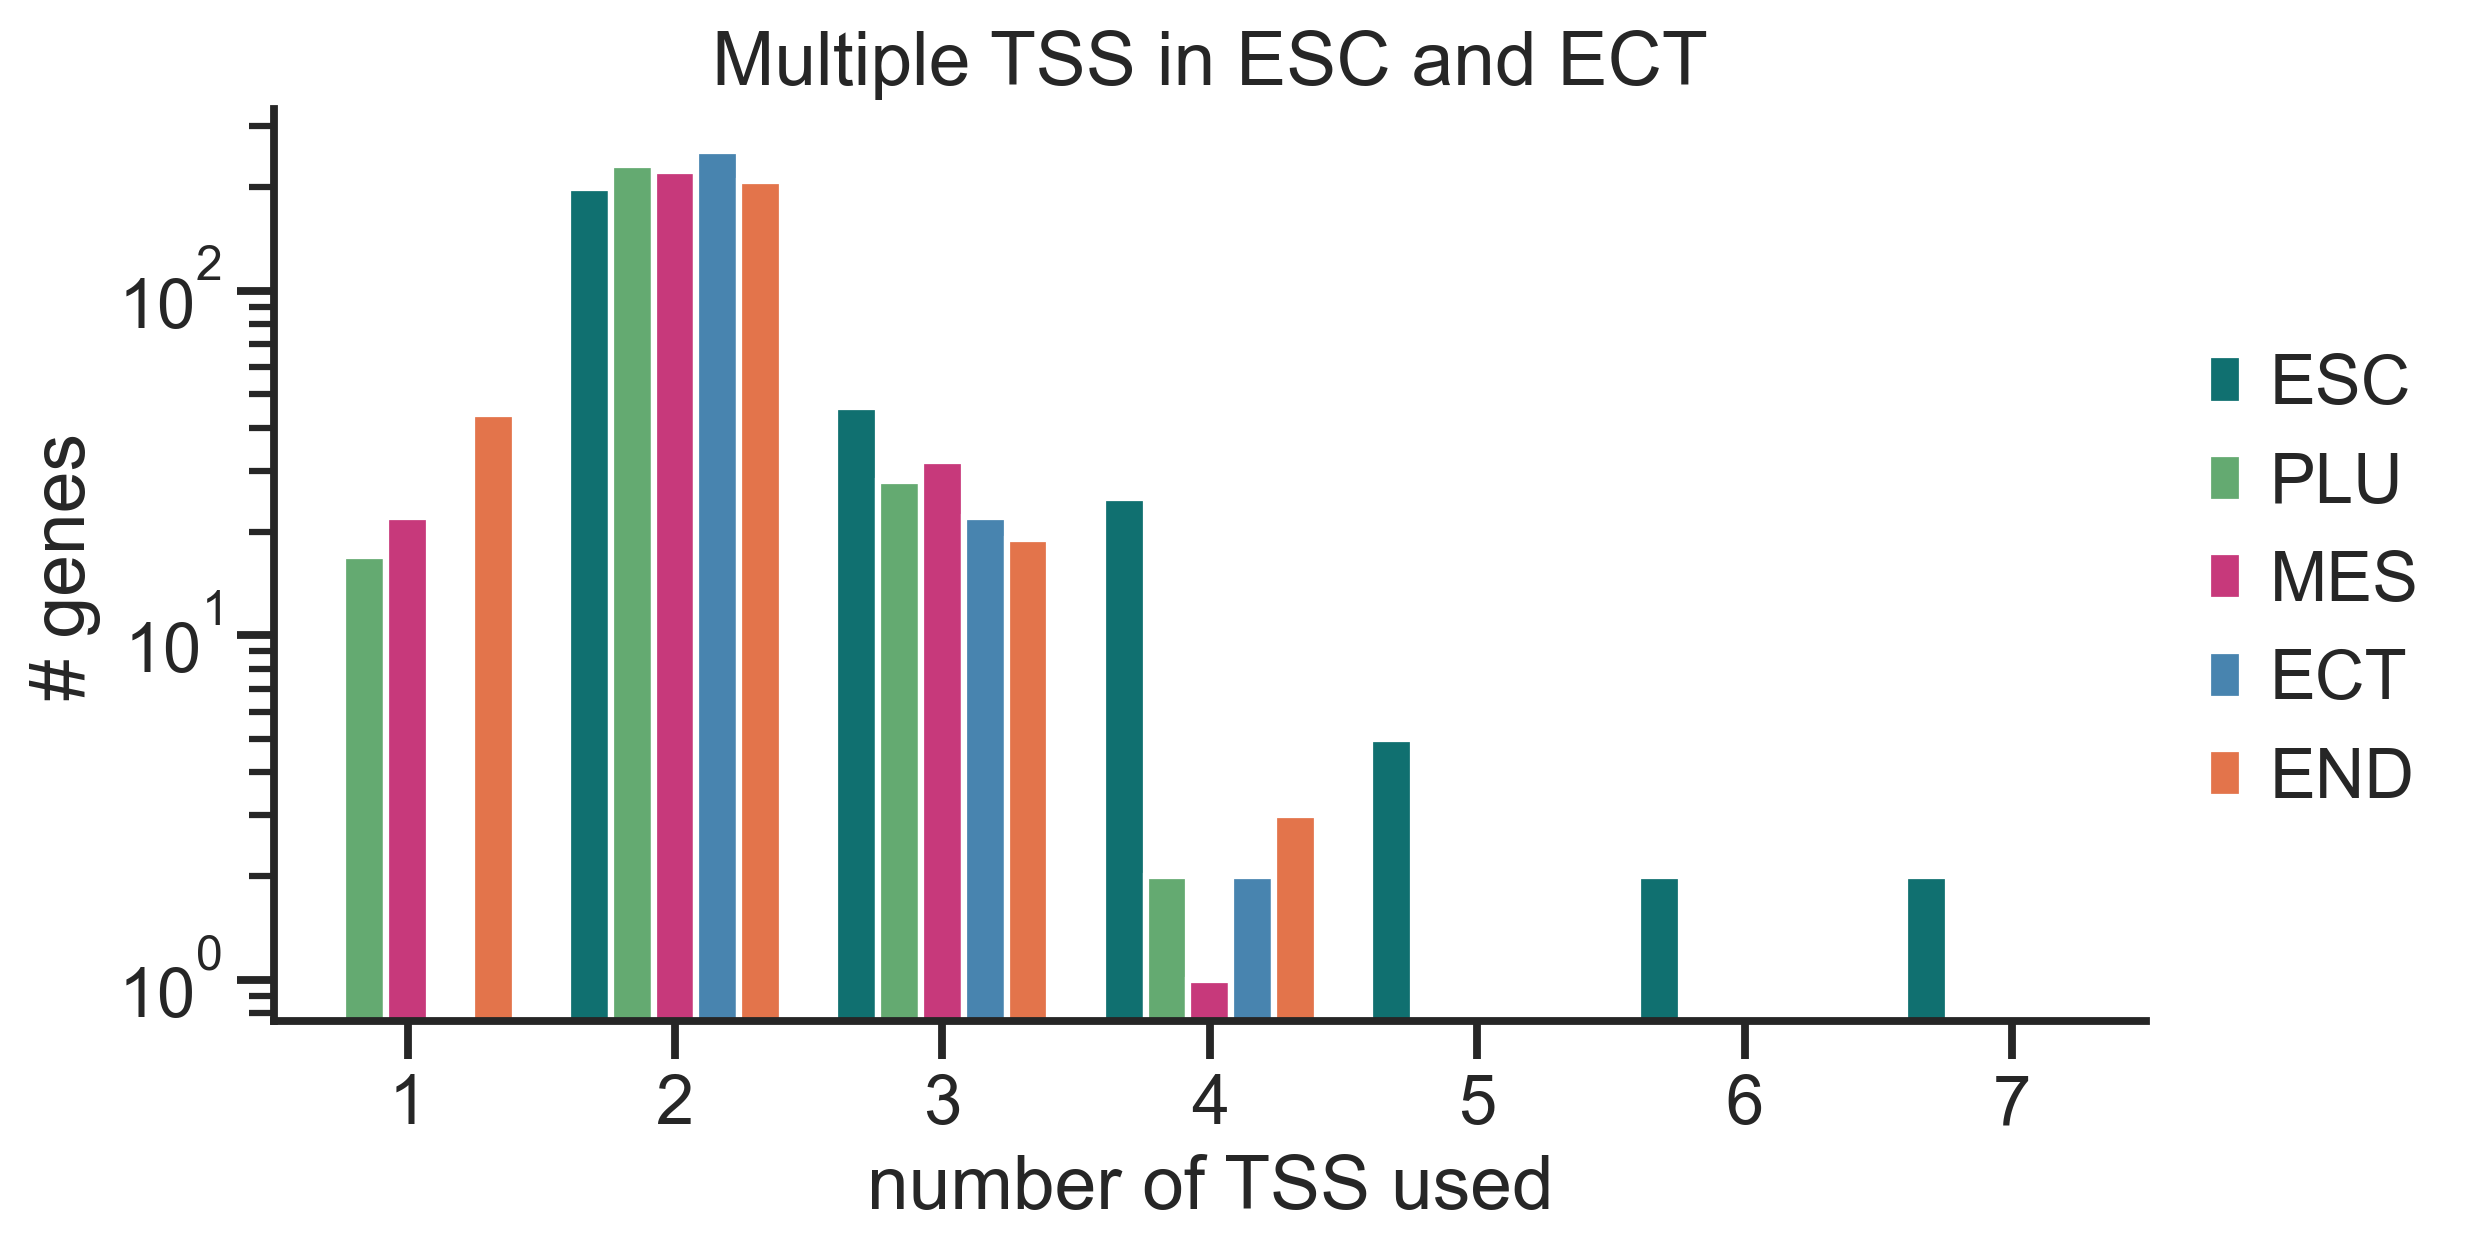

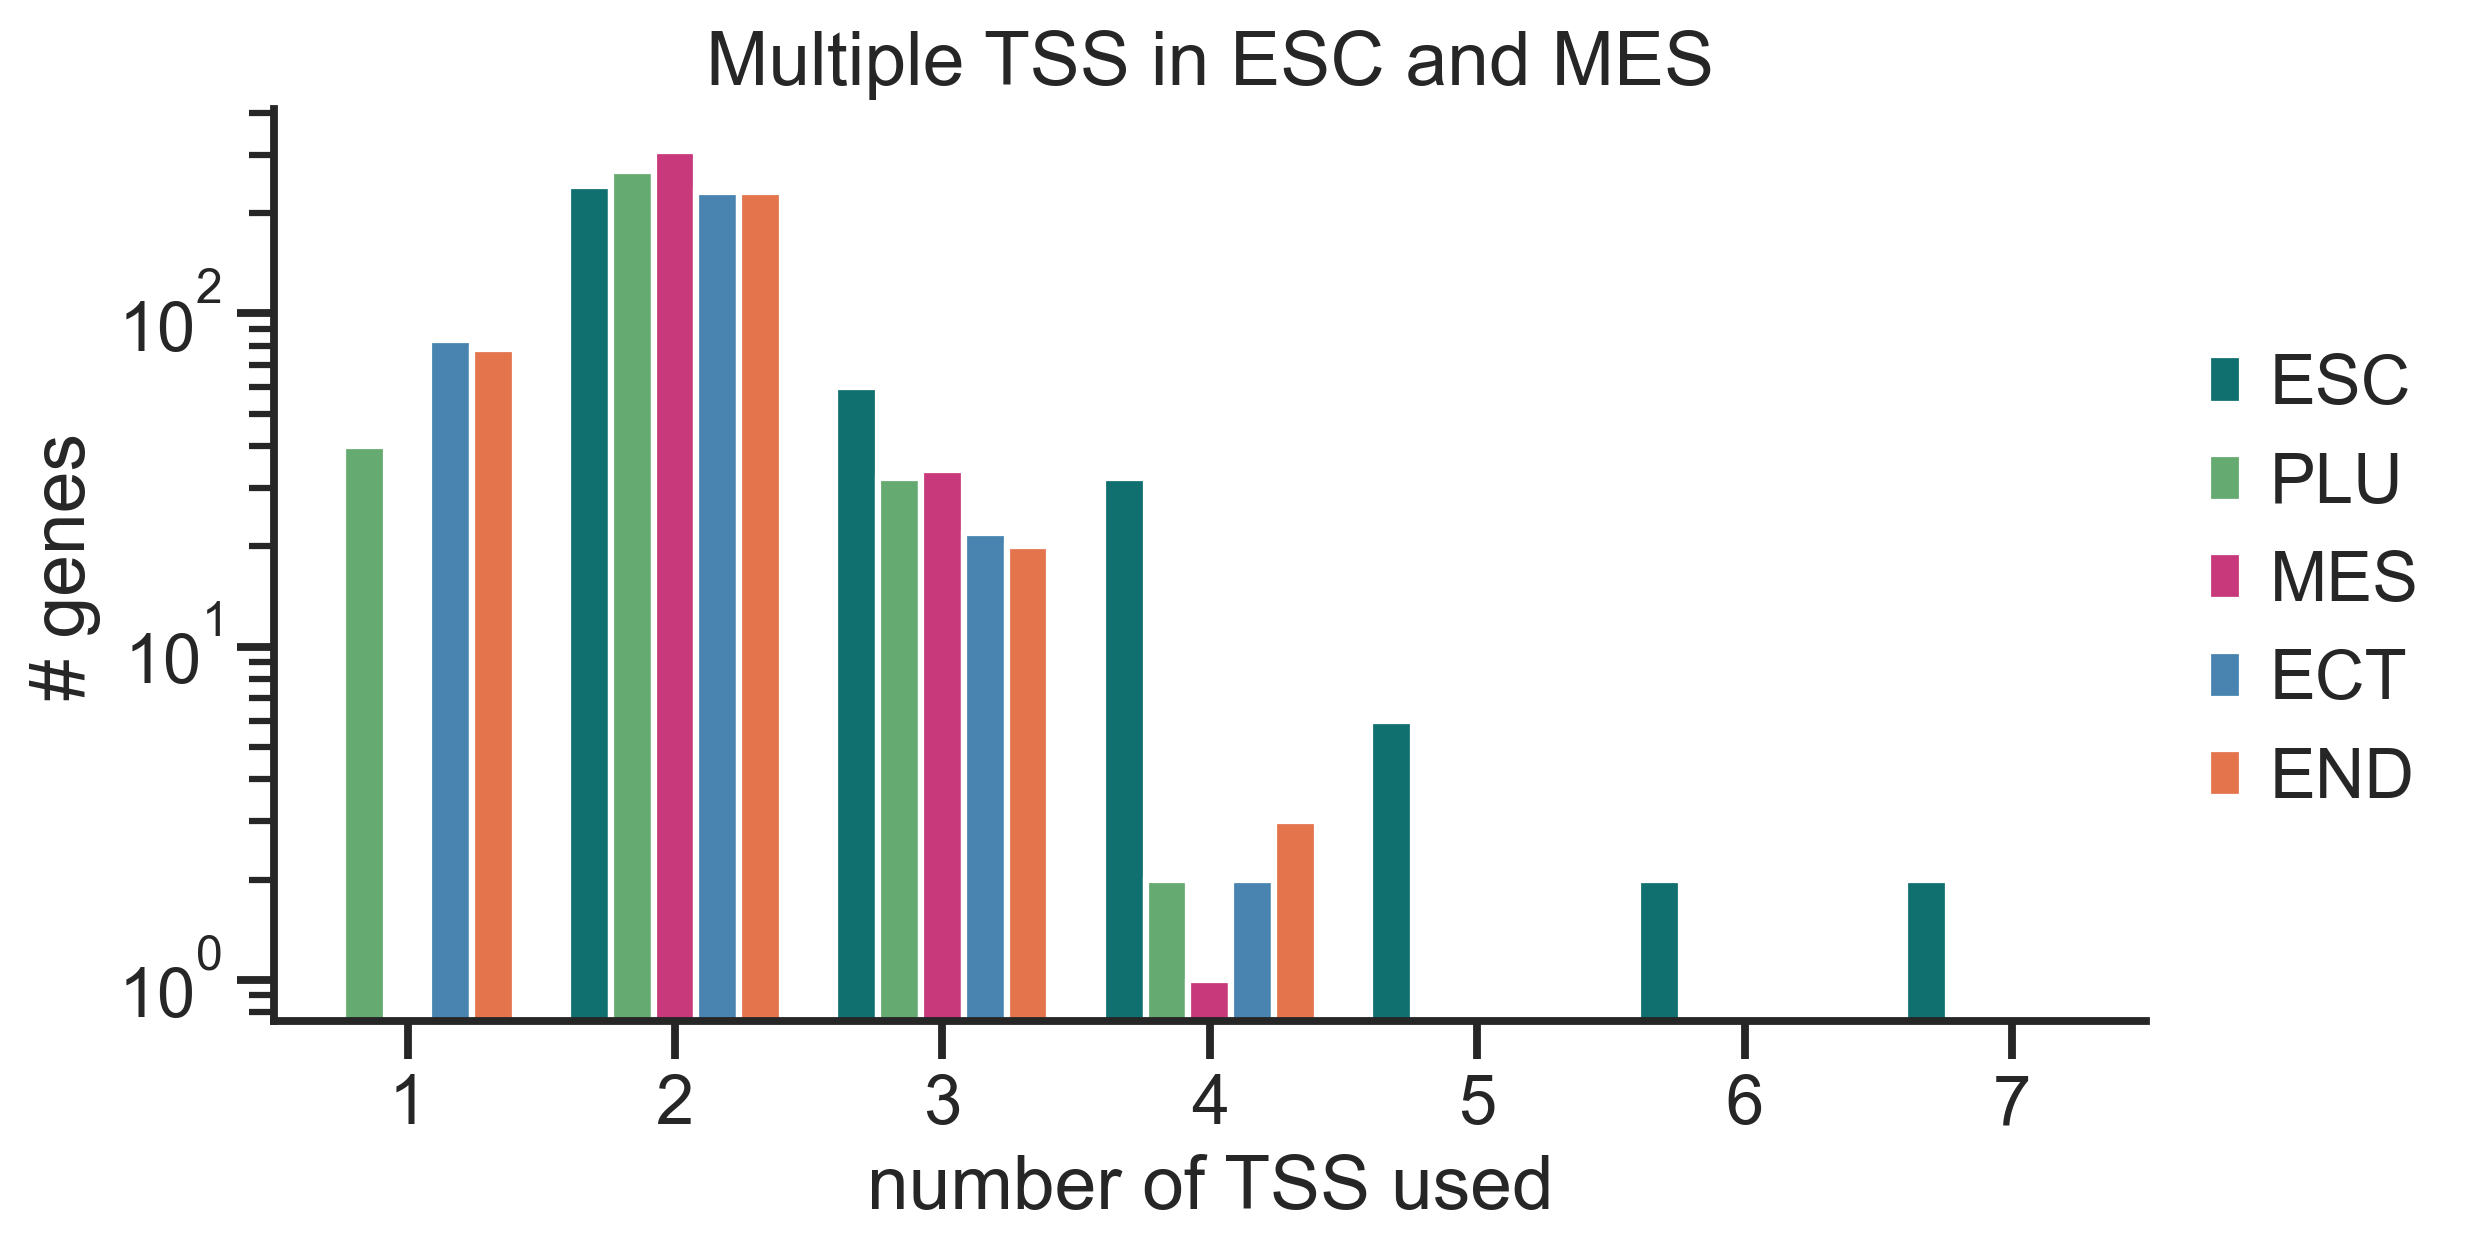

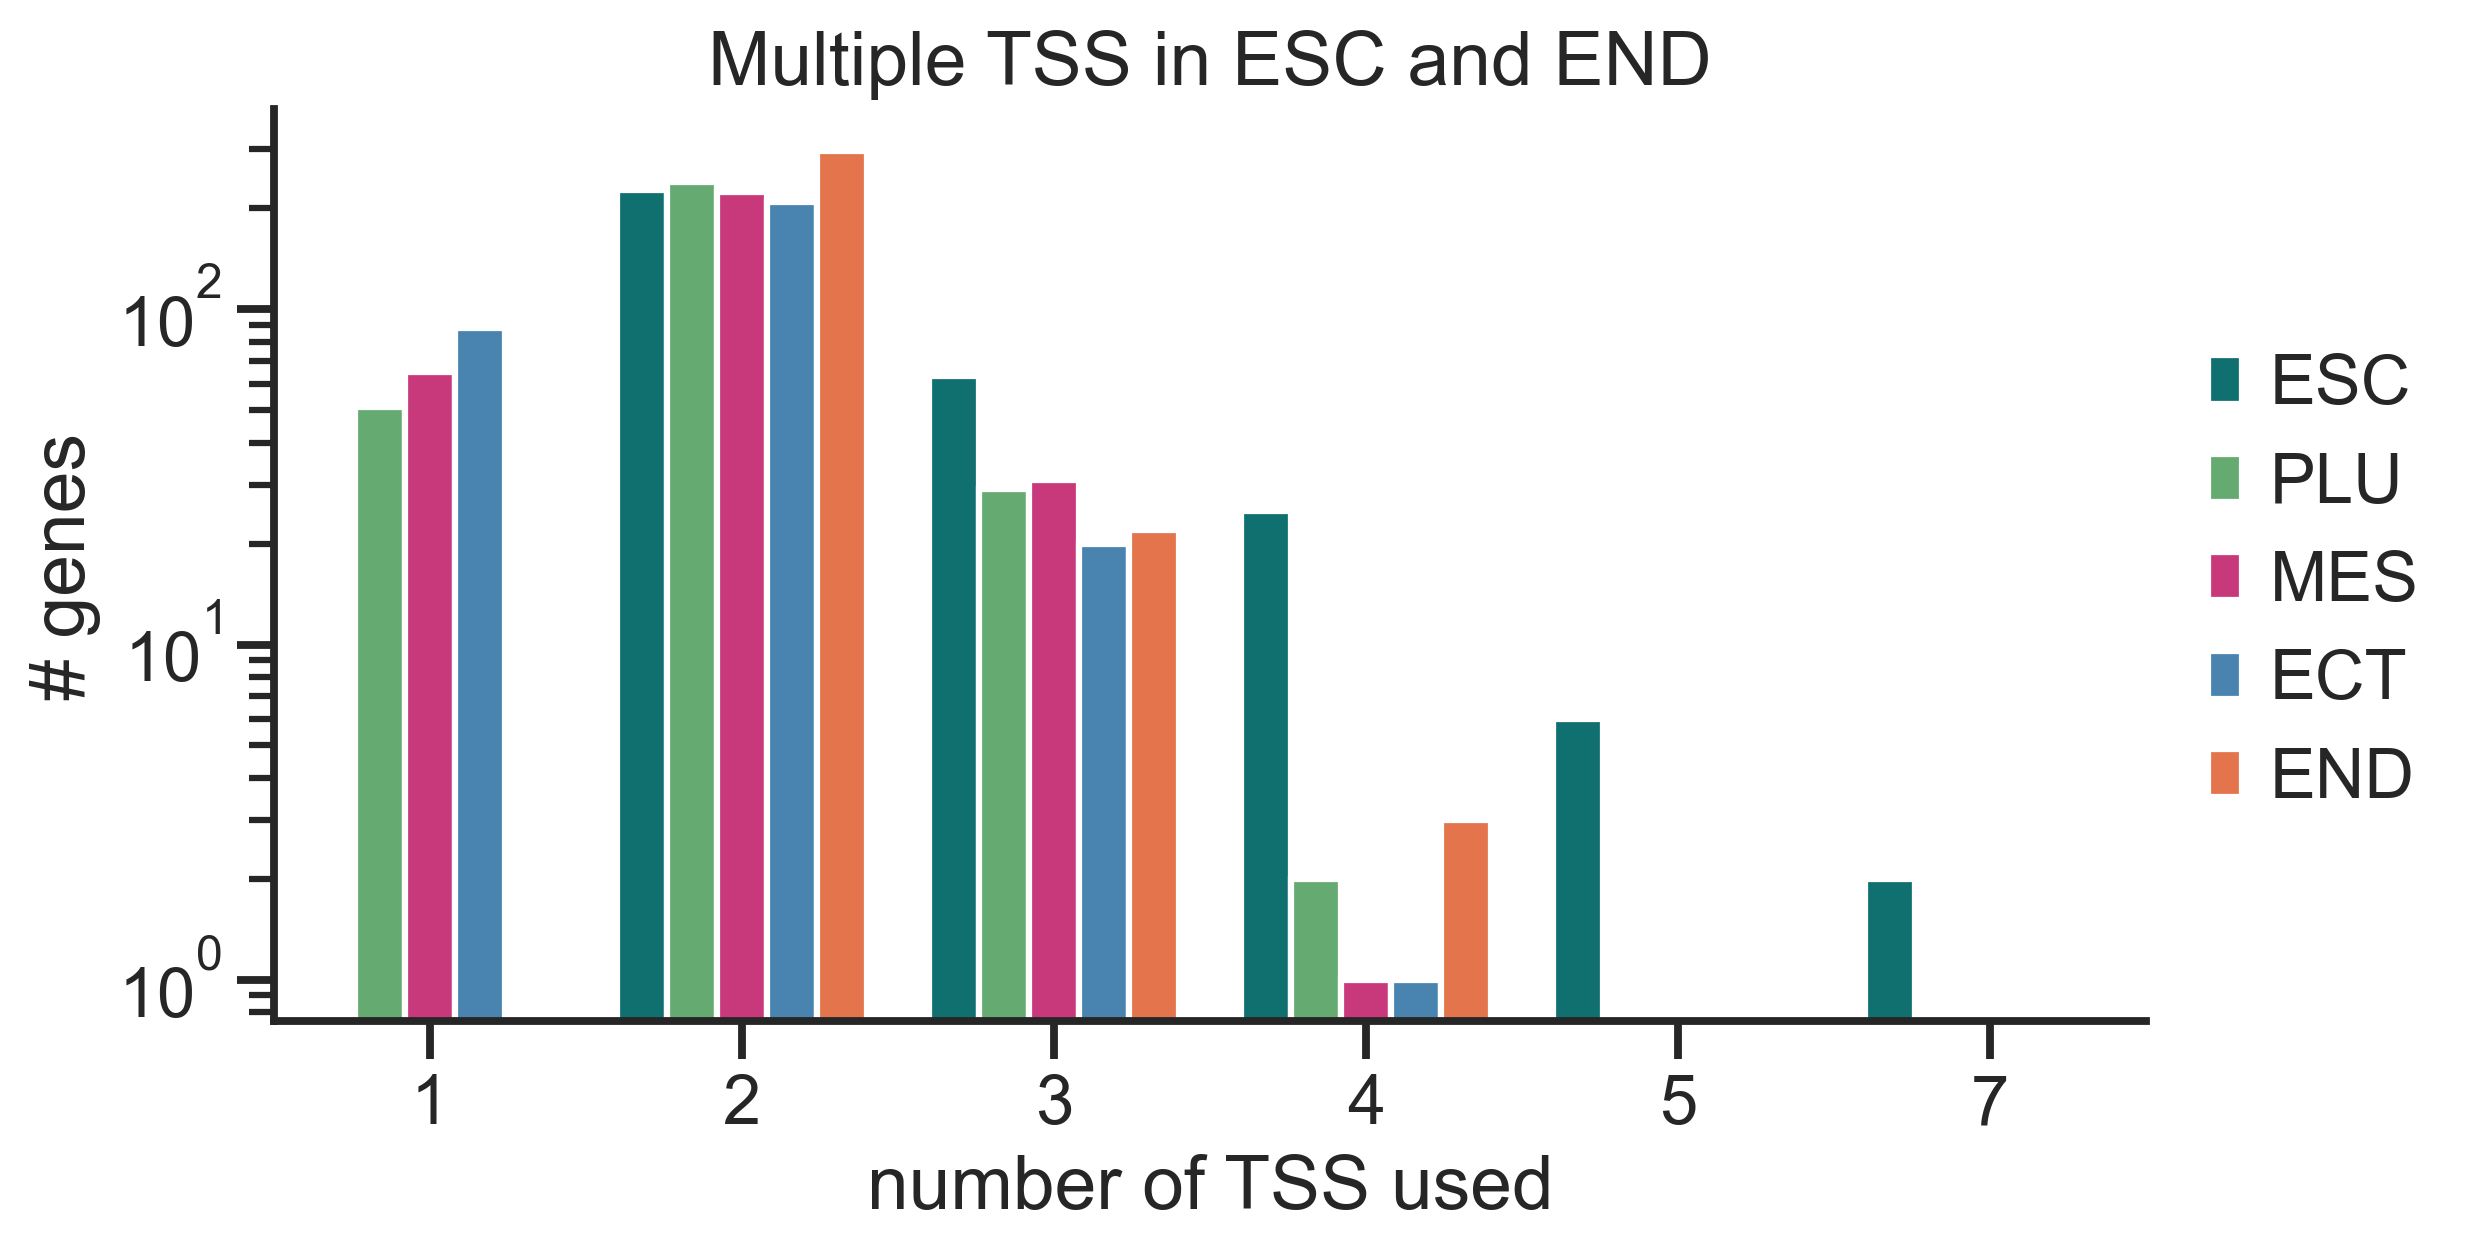

In [62]:
# multiple TSS in ESCs and in one of the 3 lineages
sumcounts4 = pd.DataFrame(numTSS_ESCm_LINm[['count','Lin']].value_counts()).rename(columns={0:'sum'}).reset_index()

fig,ax=plt.subplots(figsize = (8,4))
sns.barplot(x = sumcounts4['count'], y=sumcounts4['sum'],hue=sumcounts4['Lin'], ax=ax, palette = ['teal','#58b669','#df2179','#3787c0', '#fc6832'],hue_order = ['ESC','PLU','MES','ECT','END'])
sns.despine()
plt.yscale('log',)
plt.legend(bbox_to_anchor=(1,0.8),frameon=False)
plt.xlabel('number of TSS used')
plt.ylabel('# genes')
plt.title('Multiple TSS in ESC and LIN')
#ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

# multiple TSS in ESCs and in ECT
numTSS_ESCm_ECTm = numTSS_ESCm[(numTSS_ESCm['gene'].isin(c))]

sumcounts4 = pd.DataFrame(numTSS_ESCm_ECTm[['count','Lin']].value_counts()).rename(columns={0:'sum'}).reset_index()

fig,ax=plt.subplots(figsize = (8,4))
sns.barplot(x = sumcounts4['count'], y=sumcounts4['sum'],hue=sumcounts4['Lin'], ax=ax, palette = ['teal','#58b669','#df2179','#3787c0', '#fc6832'],hue_order = ['ESC','PLU','MES','ECT','END'])
sns.despine()
plt.yscale('log',)
plt.legend(bbox_to_anchor=(1,0.8),frameon=False)
plt.title('Multiple TSS in ESC and ECT')
plt.xlabel('number of TSS used')
plt.ylabel('# genes')
#ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))


# multiple TSS in ESCs and in MES
numTSS_ESCm_MESm = numTSS_ESCm[(numTSS_ESCm['gene'].isin(b))]

sumcounts4 = pd.DataFrame(numTSS_ESCm_MESm[['count','Lin']].value_counts()).rename(columns={0:'sum'}).reset_index()

fig,ax=plt.subplots(figsize = (8,4))
sns.barplot(x = sumcounts4['count'], y=sumcounts4['sum'],hue=sumcounts4['Lin'], ax=ax, palette = ['teal','#58b669','#df2179','#3787c0', '#fc6832'],hue_order = ['ESC','PLU','MES','ECT','END'])
sns.despine()
plt.yscale('log',)
plt.legend(bbox_to_anchor=(1,0.8),frameon=False)
plt.xlabel('number of TSS used')
plt.ylabel('# genes')
plt.title('Multiple TSS in ESC and MES')
#ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

# multiple TSS in ESCs and in END
numTSS_ESCm_ENDm =numTSS_ESCm[(numTSS_ESCm['gene'].isin(a))]

sumcounts4 = pd.DataFrame(numTSS_ESCm_ENDm[['count','Lin']].value_counts()).rename(columns={0:'sum'}).reset_index()

fig,ax=plt.subplots(figsize = (8,4))
sns.barplot(x = sumcounts4['count'], y=sumcounts4['sum'],hue=sumcounts4['Lin'], ax=ax, palette = ['teal','#58b669','#df2179','#3787c0', '#fc6832'],hue_order = ['ESC','PLU','MES','ECT','END'])
sns.despine()
plt.yscale('log',)
plt.legend(bbox_to_anchor=(1,0.8),frameon=False)
plt.xlabel('number of TSS used')
plt.ylabel('# genes')
plt.title('Multiple TSS in ESC and END')
#ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))



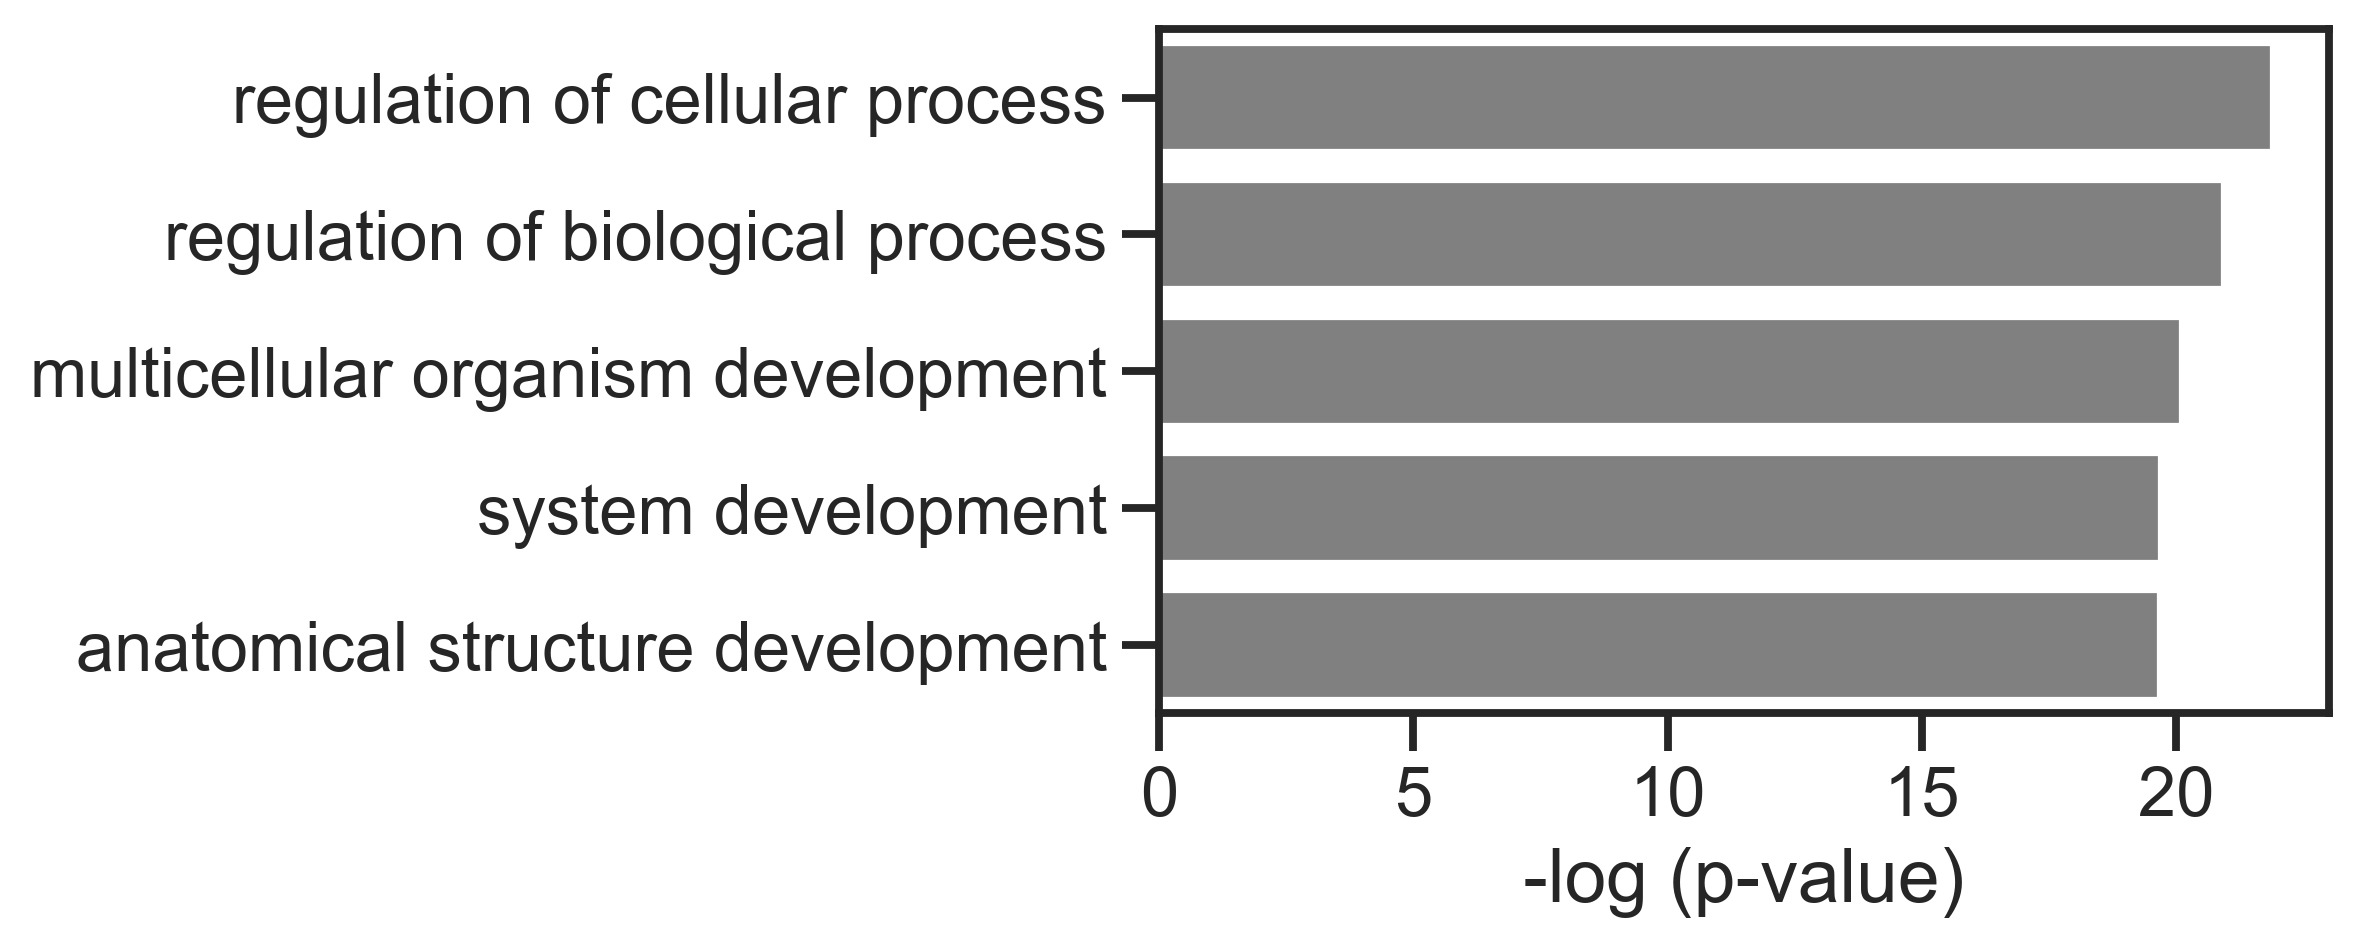

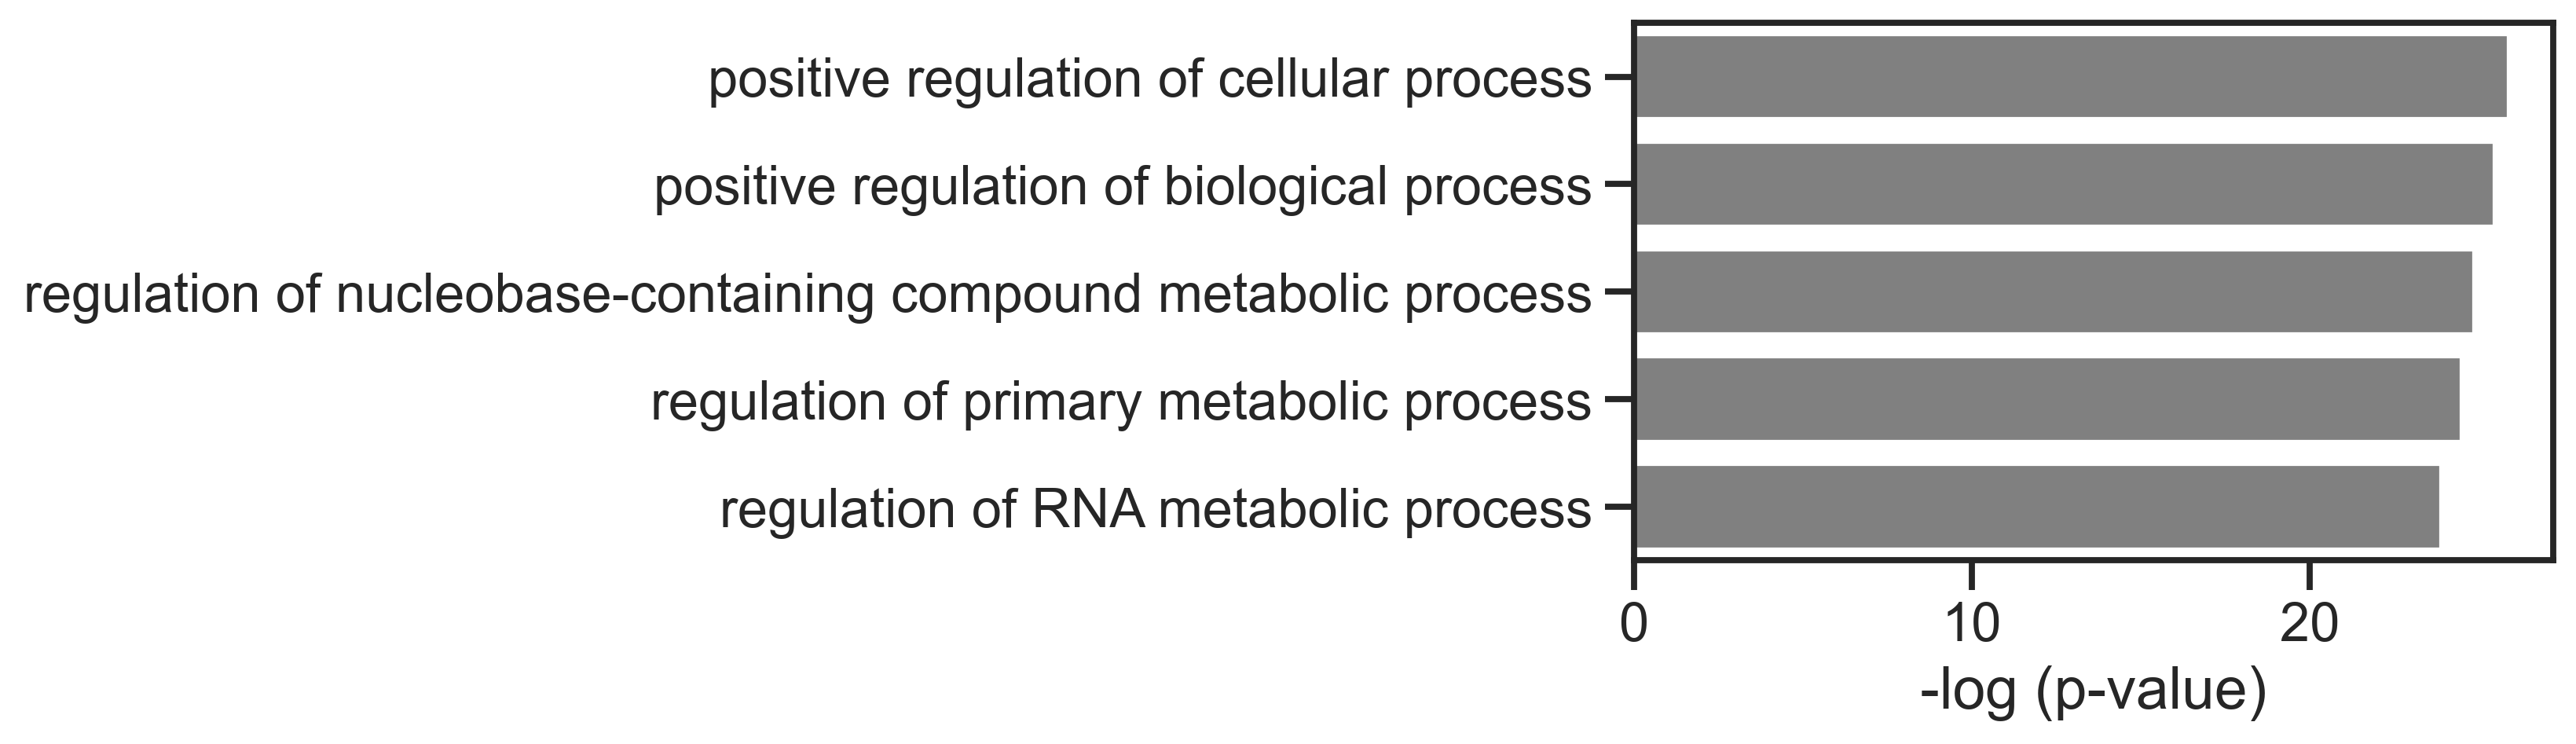

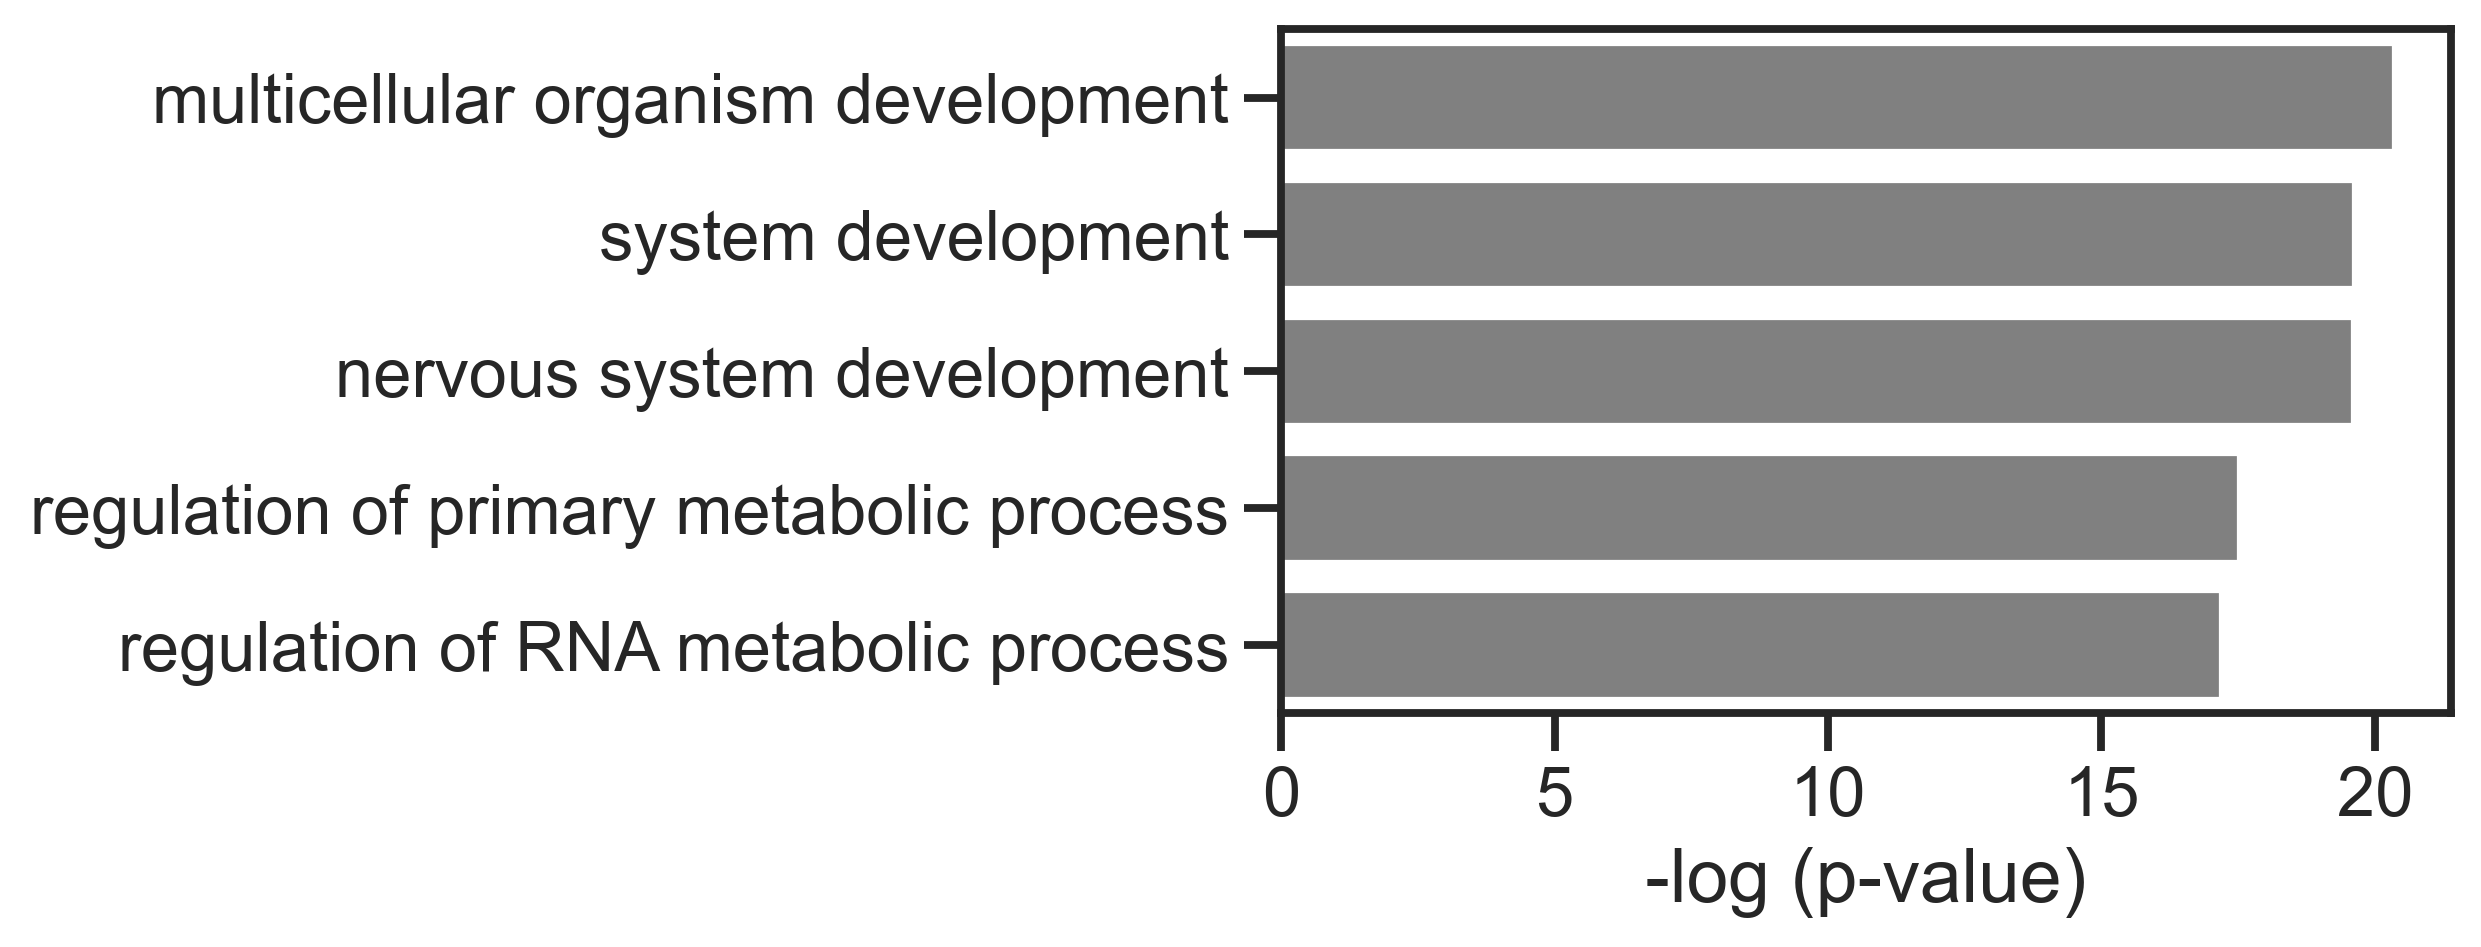

In [63]:
# GO for all genes with multiple TSS in ESCs and in END
genes = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == 'END') & (numTSS_ESCm['count'] > 1)]['gene'])
makeGO(genes, figsize = (5,3), num=5)

# GO for all genes with multiple TSS in ESCs and in MES
genes = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == 'MES') & (numTSS_ESCm['count'] > 1)]['gene'])
makeGO(genes, figsize = (5,3), num=5)

# GO for all genes with multiple TSS in ESCs and in ECT
genes = list(numTSS_ESCm[(numTSS_ESCm['Lin'] == 'ECT') & (numTSS_ESCm['count'] > 1)]['gene'])
makeGO(genes, figsize = (5,3), num=5)

# GO analysis

In [64]:
import scanpy as sc

In [65]:
test_genes = ['Dlgap1', 'Ank3', 'Tacc2', 'Epb41l3', 'Aopep', 'Tsc22d1', 'Robo1',
       'Adgrb1', 'Nav2', 'Rbpj', 'Aff1', 'Mapt', 'Tenm4', 'Nr4a1',
       'Rab37', 'Wscd2', 'Pde4d', 'Dmd', 'Tnrc6b', 'Zfp516', 'Shroom3',
       'Adgrg1', 'Myo10', 'Zmiz1', 'Sgk1', 'Dlgap4', 'Kat6b', 'Dnah8',
       'Adgra2', 'Syngap1', 'Nmnat2', 'Aim2', 'Frmd4a', 'Arhgap6',
       'Ildr1', 'Jade1', 'Arhgap22', 'Palld', 'Baz2b', 'Hk1', 'Agtpbp1',
       'Arid5b', 'Stox2', 'Phldb2', 'Slc39a10', 'Bicral', 'Trim2', 'Nfib',
       'Pole4', 'Tns1', 'Rap1gap2', 'Slc25a12', 'Csnk1e', 'Gab1',
       'Amotl1', 'Dlc1', 'Fam178b', 'Mcc', 'Gramd1b', 'Mecom', 'Wdtc1',
       'Mttp', 'Rnf220', 'Adipor2', 'Rbfox3', 'Cacna1c', 'Fbxl2', 'Kifc3',
       'Foxp1', 'Zfp217', 'Lima1', 'Rabgap1l']



allgenes = list(venn_diagram['gene'].unique())

In [66]:
def makeGO(genes, background = allgenes, num = 10, figsize = (4,2)):
    go = sc.queries.enrich({'cluster':genes,'all':background}, org="mmusculus")

    plotcl = go
    cluster = 'cluster'

    plot1 = plotcl[plotcl['query'] == cluster][plotcl[plotcl['query'] == cluster]['source'] == 'GO:BP'].sort_values(by='p_value')[['name','p_value']][0:num]
    plot1['-log (p-value)'] = np.log10(plot1['p_value'])*-1
    sns.set_style('ticks')
    sns.set_context('talk')
    fig,ax = plt.subplots(figsize = figsize)
    ax = sns.barplot(y=plot1['name'],x=plot1['-log (p-value)'], color = 'grey')
    ax.set_ylabel('')
    plt.show()

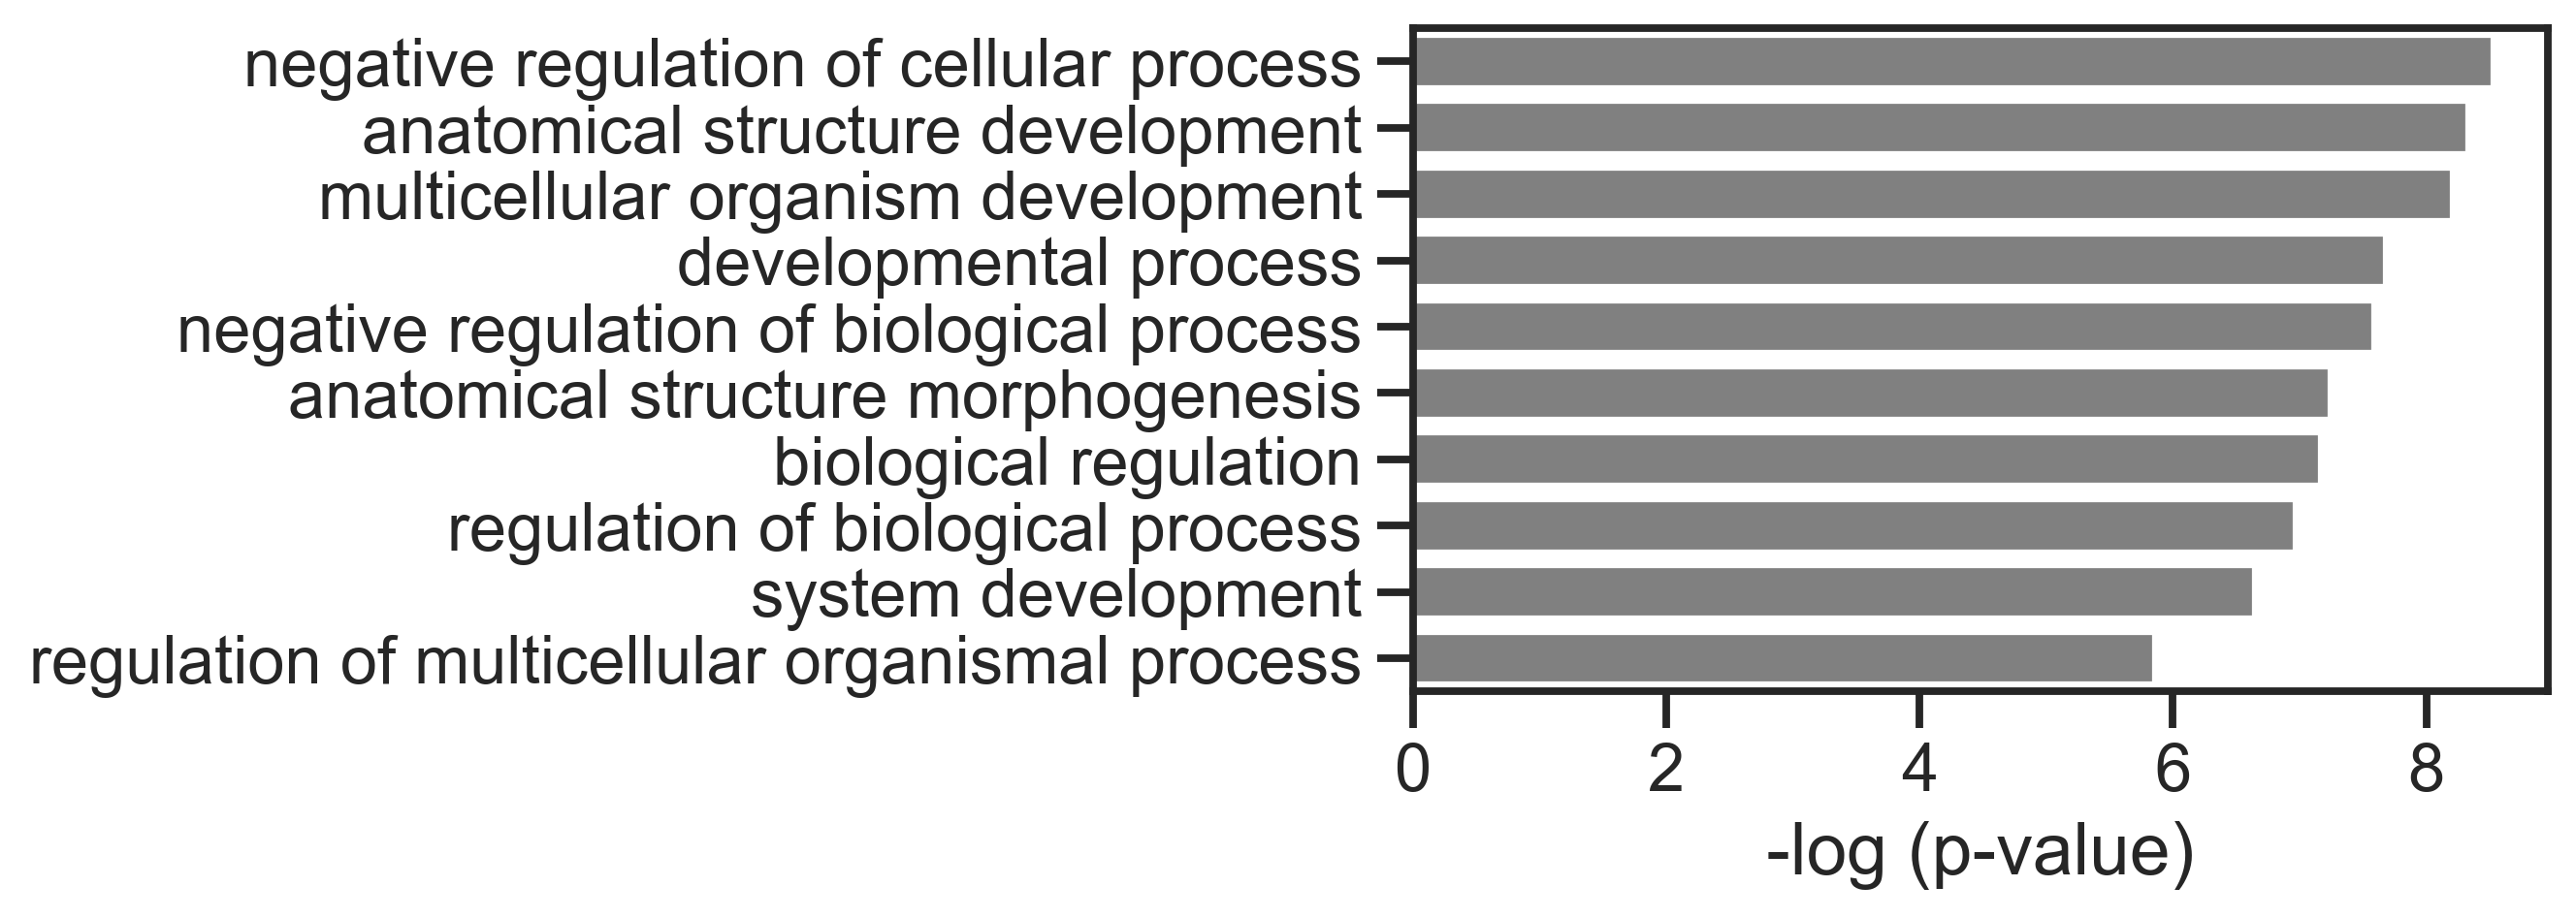

In [67]:
makeGO(test_genes, figsize = (5,3))

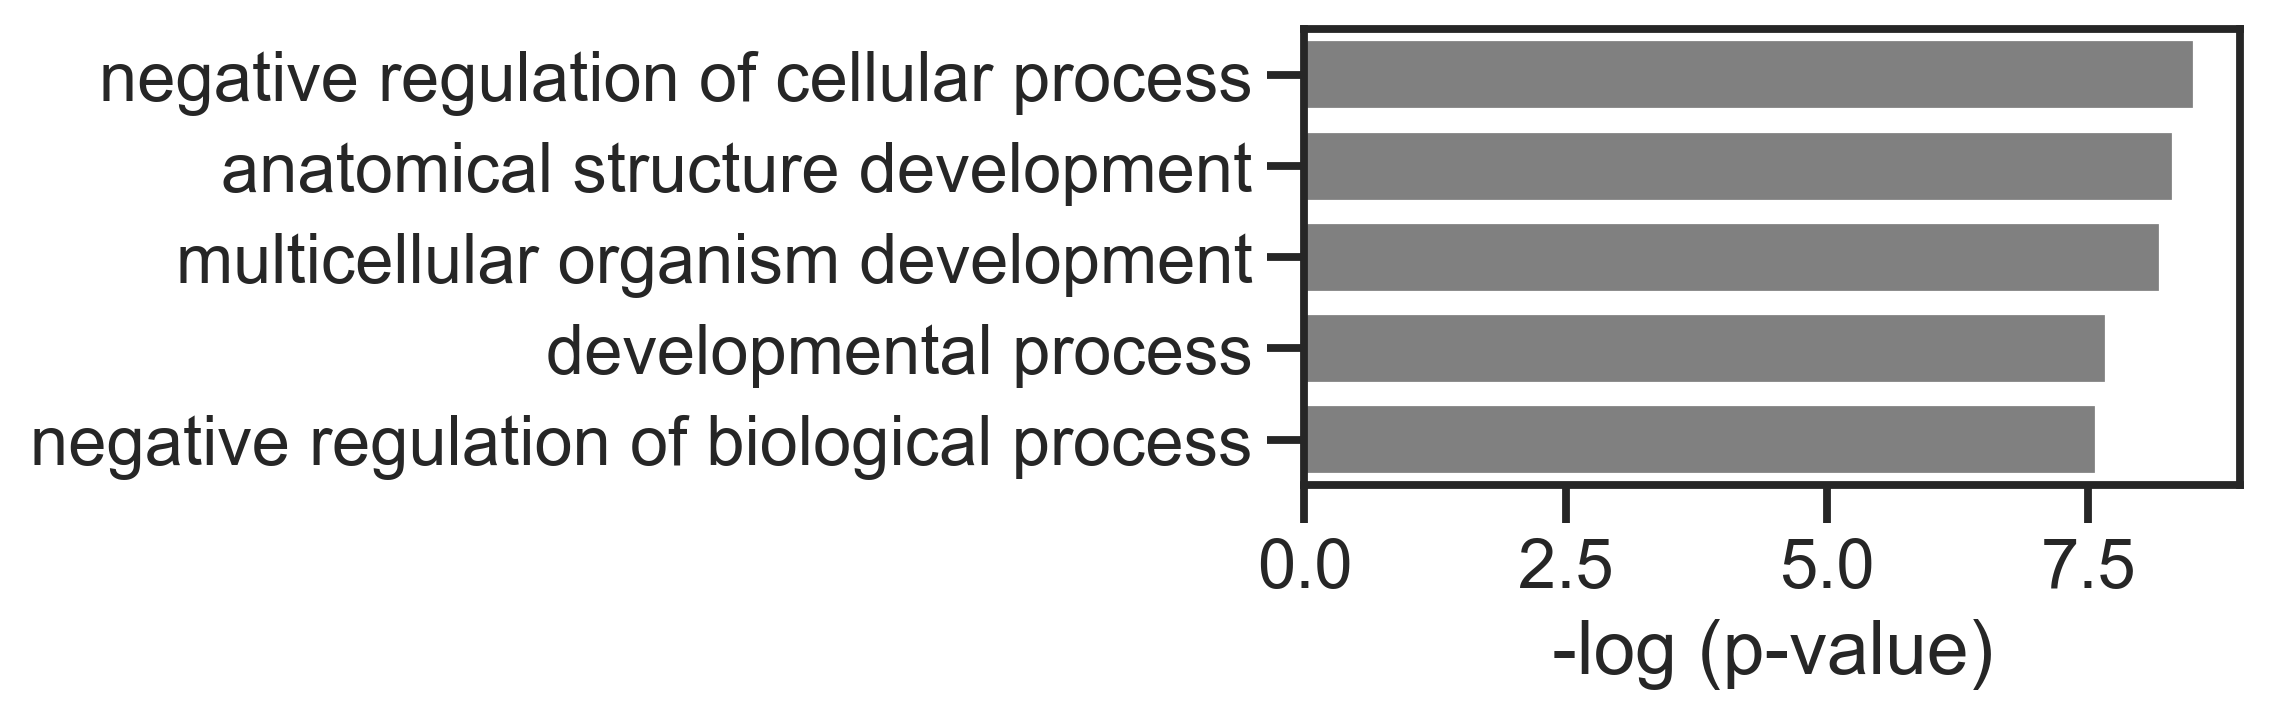

In [68]:
makeGO(test_genes, num = 5)

# General dynamics

In [69]:
sumcounts = pd.DataFrame(numTSS[['count','Lin']].value_counts()).rename(columns={0:'sum'}).reset_index()
import matplotlib.ticker as ticker

Text(0, 0.5, '# genes')

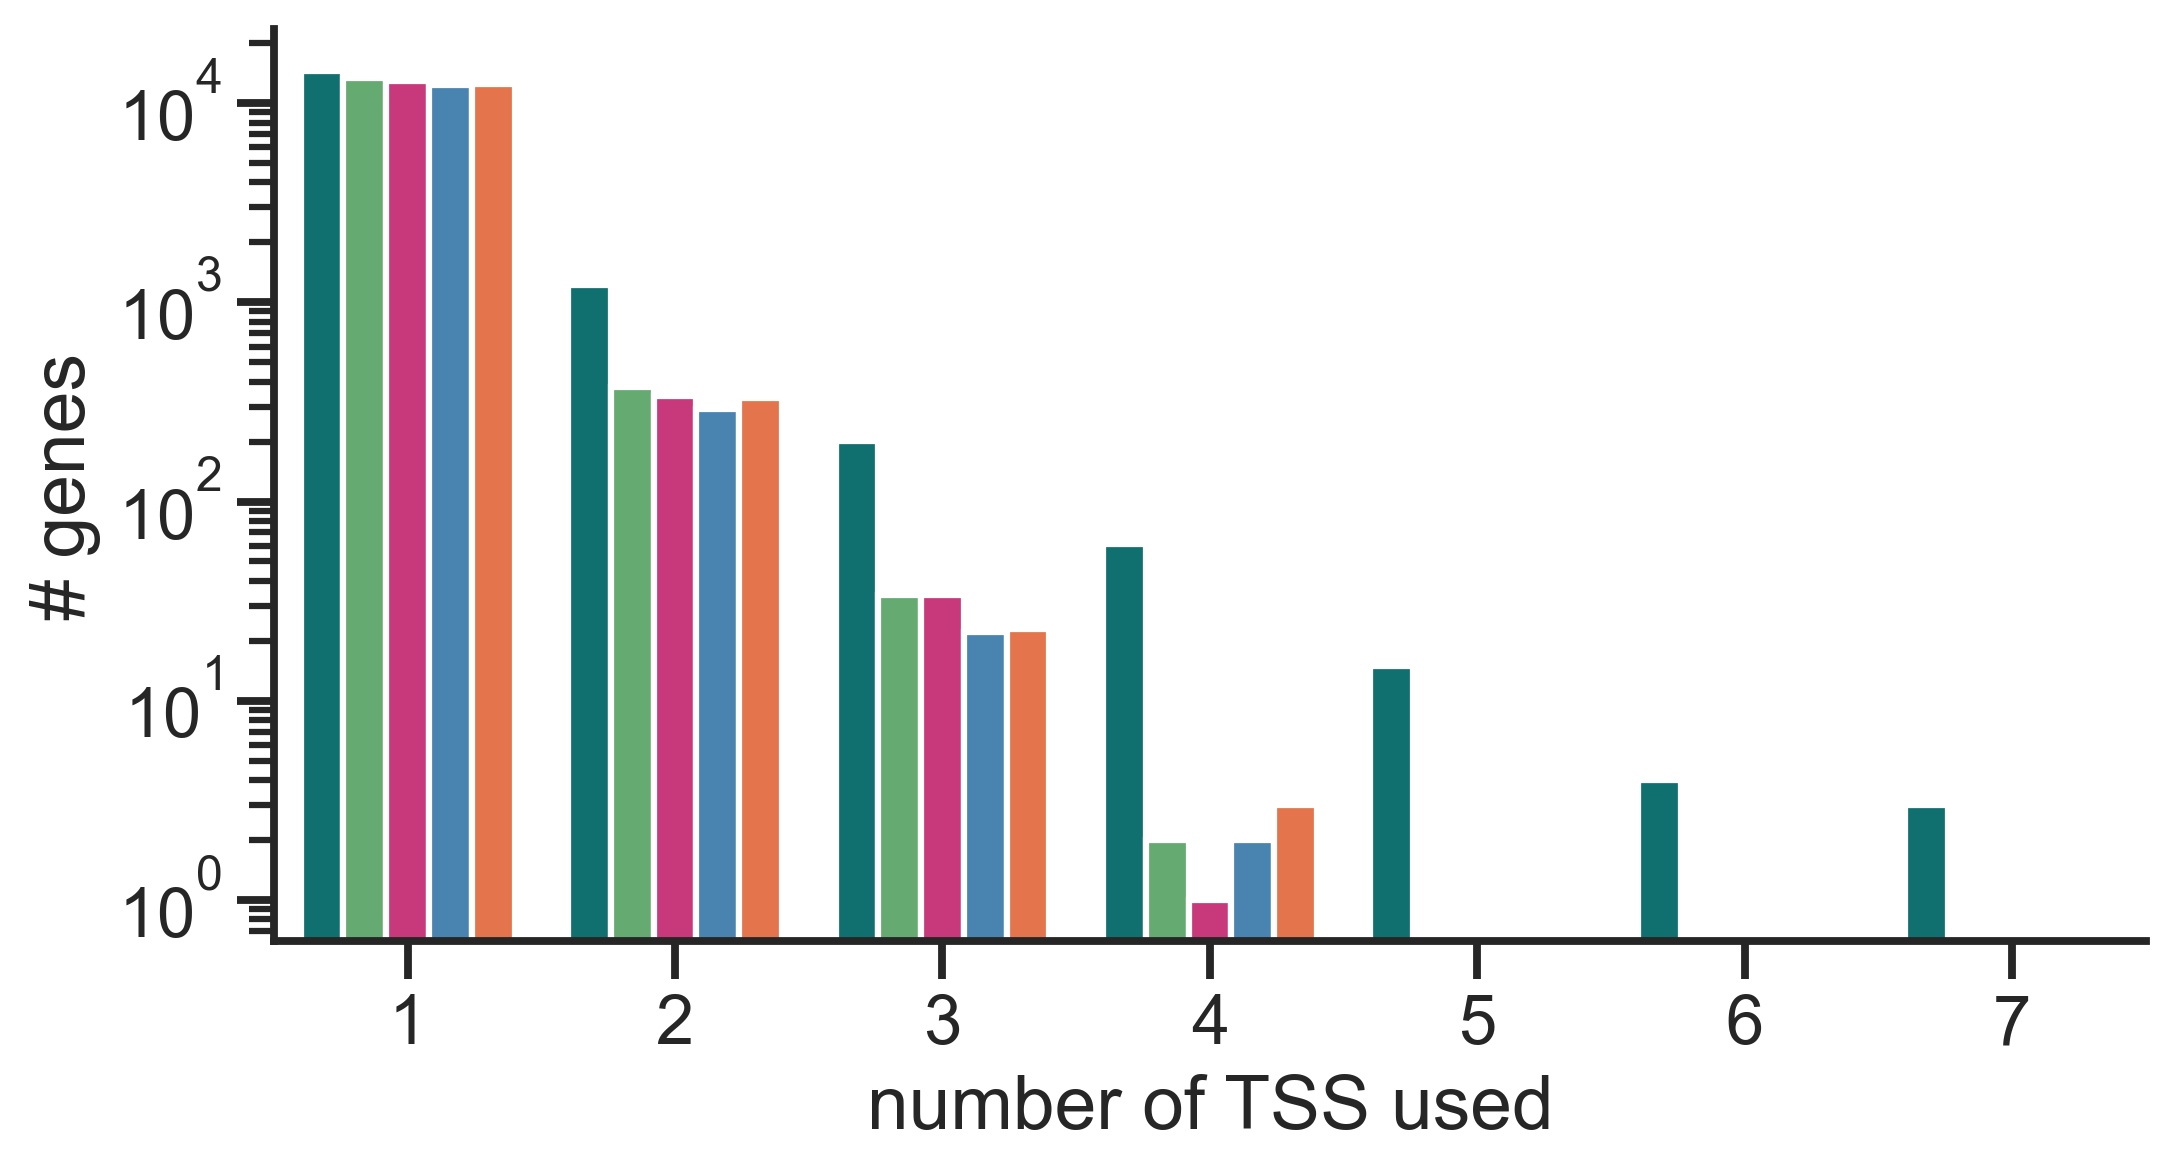

In [70]:
import matplotlib.ticker as ticker

fig,ax=plt.subplots(figsize = (8,4))
sns.barplot(x = sumcounts['count'], y=sumcounts['sum'],hue=sumcounts['Lin'], ax=ax, palette = ['teal','#58b669','#df2179','#3787c0', '#fc6832'],hue_order = ['ESC','PLU','MES','ECT','END'])
sns.despine()
plt.yscale('log',)
plt.legend([],frameon=False)
plt.xlabel('number of TSS used')
plt.ylabel('# genes')
#ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))

